
<br><br><br>
<p align="center">
  <img src="https://www.daiict.ac.in/sites/default/files/inline-images/20250107DAUfinalIDcol_SK-01_0.png" width="420"/>
</p>

<br><br><br>
<div align="center"> $\huge \textbf{Dendrogram}$</div>
<br><br>

<p align="center">  $\Huge \textbf{Group 23}$</p>
<br><br>
<style>
  table, th, td {
    background-color: transparent !important;
  }
</style>
<div align="center" >
  <table >
    <tr>
      <td align="center" style="background-color:transparent; padding: 10px;">
        <img src="https://i.postimg.cc/V6yhTJxZ/Screenshot-2025-09-17-205936.png" width="200"><br><br>
        <strong>Khanak Patel</strong><br><br>
        <span>ID-202303020 </span><br><br>
      </td>
      <td align="center" style="background-color:transparent; padding: 10px;">
        <img src="https://i.postimg.cc/hGRqH47j/Whats-App-Image-2025-09-17-at-22-44-45-7876baeb.jpg" width="200"><br><br>
        <strong>Modak Akshada Rajesh</strong><br><br>
        <span>ID-202301485</span><br><br>
      </td>
      <td align="center" style="background-color:transparent; padding: 10px;">
        <a href='https://postimg.cc/rKTk0jry' target='_blank'><img src='https://i.postimg.cc/rKTk0jry/Whats-App-Image-2025-09-17-at-22-18-57.jpg' border='0' alt='Whats-App-Image-2025-09-17-at-22-18-57' width="200"/></a>
        <br><br>
        <strong> Maanav Gurubaxani </strong> <br><br>
        <span>ID-202301438</span><br><br>
      </td>
    </tr>
  </table>
</div>
<br><br><br><br><br>


<p align="center" >  $\huge \textbf{IT462: Exploratory Data Analysis}$</p>

<br>

<p align="center">  $\huge \textbf{Autumn 2025}$ </p>

<br><br><br><br>

<p align="center" > $\large \textbf{Instructor: Dr. Gopinath Panda}$ </p>




<br><br><br><br><br><br>
<p align="center"> $ \textbf{© 2025 Dhirubhai Ambani University}$</p>
<br><br><br><br><br><br>

# Equity Consumption Mutual Funds - Exploratory Data Analysis
## Using ULTIMATE.csv (7 Years of Data: 2019-2025)

## Project Overview

**Main Objective**: Identify which consumption fund schemes offer the best risk-adjusted returns and understand what drives their performance.

**Key Advantage of 7 Years Data**:
- ✅ **Full Market Cycles**: Can analyze performance across bull and bear markets
- ✅ **Robust Statistics**: More data points for reliable statistical tests
- ✅ **Better ML Models**: Larger training datasets improve model accuracy
- ✅ **Fund Persistence**: Can analyze if top performers maintain their edge over time
- ✅ **Regime Analysis**: Compare fund performance in different market conditions
- ✅ **Rolling Analysis**: Longer windows for trend analysis

**Supporting Questions**:
- How do consumption funds compare to each other and the benchmark over 7 years?
- Do funds deliver genuine alpha, or is performance driven by hype/marketing?
- What factors predict fund rankings and risk metrics?
- How do funds perform across different market regimes?

---


# 1. Introduction

## 1.1 Project Idea

The Indian mutual fund industry has seen significant growth in thematic funds, with consumption funds being a prominent category. This project analyzes **7 years of data (2019-2025)** to:

1. **Identify top performers**: Which consumption fund schemes offer the best risk-adjusted returns over the long term?
2. **Understand drivers**: What factors (risk metrics, alpha generation, AUM dynamics) drive performance?
3. **Compare schemes**: How do different funds compare across risk, performance, alpha, and AUM dimensions?
4. **Predict outcomes**: Can we predict risk metrics and fund rankings using ML models?
5. **Regime analysis**: How do funds perform in different market conditions?

**Priority Focus Areas** (in order):
- **Risk Analysis** (Volatility, Max Drawdown, Sortino Ratio)
- **Performance Metrics** (CAGR, Sharpe Ratio)
- **Alpha Generation** (CAPM Alpha, Beta, R-squared)
- **AUM Dynamics** (Market share, flows, growth)

## 1.2 Data Collection

The dataset contains daily NAV (Net Asset Value) data for multiple consumption fund schemes from **2019 to 2025 (7 years of data)**. The data includes:

- **NAV values**: Direct and Regular plans
- **Returns**: 7-day, 15-day, 1-month, 3-month, 6-month, 1-year, 3-year, 5-year, 10-year, and since launch returns
- **Benchmark returns**: For comparison
- **AUM (Assets Under Management)**: Daily AUM in crores
- **Scheme information**: Direct scheme names (already in long format)

**Data Sources**:
- Primary dataset: `ULTIMATE.csv` (7 years: 2019-2025)
- Format: Long format (one row per date-scheme combination)

## 1.3 Dataset Description

The dataset is in **long format** where each row represents a date-scheme combination. Key characteristics:

- **Time Period**: 2019-01-01 to 2025 (approximately 7 years)
- **Schemes**: Multiple consumption fund schemes
- **Features**: NAV values, returns at multiple horizons, benchmark returns, AUM
- **Format**: CSV with camelCase column names

## 1.4 Packages Required


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from datetime import datetime

import statsmodels.api as sm
from scipy import stats
from scipy.stats import normaltest, shapiro

from sklearn.model_selection import TimeSeriesSplit, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)
from xgboost import XGBRegressor, XGBClassifier
import joblib

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9

np.random.seed(42)

print("All packages imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")


All packages imported successfully!
Pandas version: 2.2.2
NumPy version: 2.0.2


# 2. Data Cleaning

## 2.1 Missing Data Analysis


In [ ]:
DATA_PATH = Path("ULTIMATE.csv")
df_raw = pd.read_csv(DATA_PATH)

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df_raw.shape}")
print(f"Columns: {len(df_raw.columns)}")

df_raw['navDate'] = pd.to_datetime(df_raw['navDate'], format='%d-%b-%y', errors='coerce')
print(f"\nDate Range: {df_raw['navDate'].min()} to {df_raw['navDate'].max()}")
print(f"Total rows: {len(df_raw)}")
print(f"Unique schemes: {df_raw['schemeName'].nunique()}")
print(f"\nSchemes in dataset:")
for scheme in sorted(df_raw['schemeName'].unique()):
    scheme_data = df_raw[df_raw['schemeName'] == scheme]
    print(f"  - {scheme}: {len(scheme_data)} records")

print("\n" + "=" * 60)
print("MISSING DATA ANALYSIS")
print("=" * 60)
missing_data = df_raw.isnull().sum()
missing_pct = (missing_data / len(df_raw)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_pct
}).sort_values('Missing Count', ascending=False)

missing_df_filtered = missing_df[missing_df['Missing Count'] > 0]
if len(missing_df_filtered) > 0:
    print("\nColumns with missing data:")
    print(missing_df_filtered.head(20))
else:
    print("\nNo missing values found in the dataset!")

print("\n" + "=" * 60)
print("SAMPLE DATA (First 5 rows)")
print("=" * 60)
print(df_raw[['navDate', 'schemeName', 'navDirect', 'navRegular', 'dailyAUM']].head())


DATASET OVERVIEW
Shape: (12841, 54)
Columns: 54

Date Range: 2019-01-01 00:00:00 to 2025-11-27 00:00:00
Total rows: 12841
Unique schemes: 17

Schemes in dataset:
  - Aditya Birla Sun Life Consumption Fund: 1703 records
  - Axis Consumption Fund: 168 records
  - Bajaj Finserv Consumption Fund: 166 records
  - Bank of India Consumption Fund: 166 records
  - Baroda BNP Paribas India Consumption Fund: 1533 records
  - Edelweiss Consumption Fund: 166 records
  - HSBC Consumption Fund: 305 records
  - ICICI Prudential Bharat Consumption Fund: 1389 records
  - ITI Bharat Consumption Fund: 166 records
  - Invesco India Consumption Fund: 7 records
  - Kotak Consumption Fund: 252 records
  - Mahindra Manulife Consumption Fund: 1489 records
  - Motilal Oswal Consumption Fund: 8 records
  - Nippon India Consumption Fund: 1703 records
  - Quant Consumption Fund: 207 records
  - SBI Consumption Opportunities Fund: 1711 records
  - Sundaram Consumption Fund: 1702 records

MISSING DATA ANALYSIS

Colum

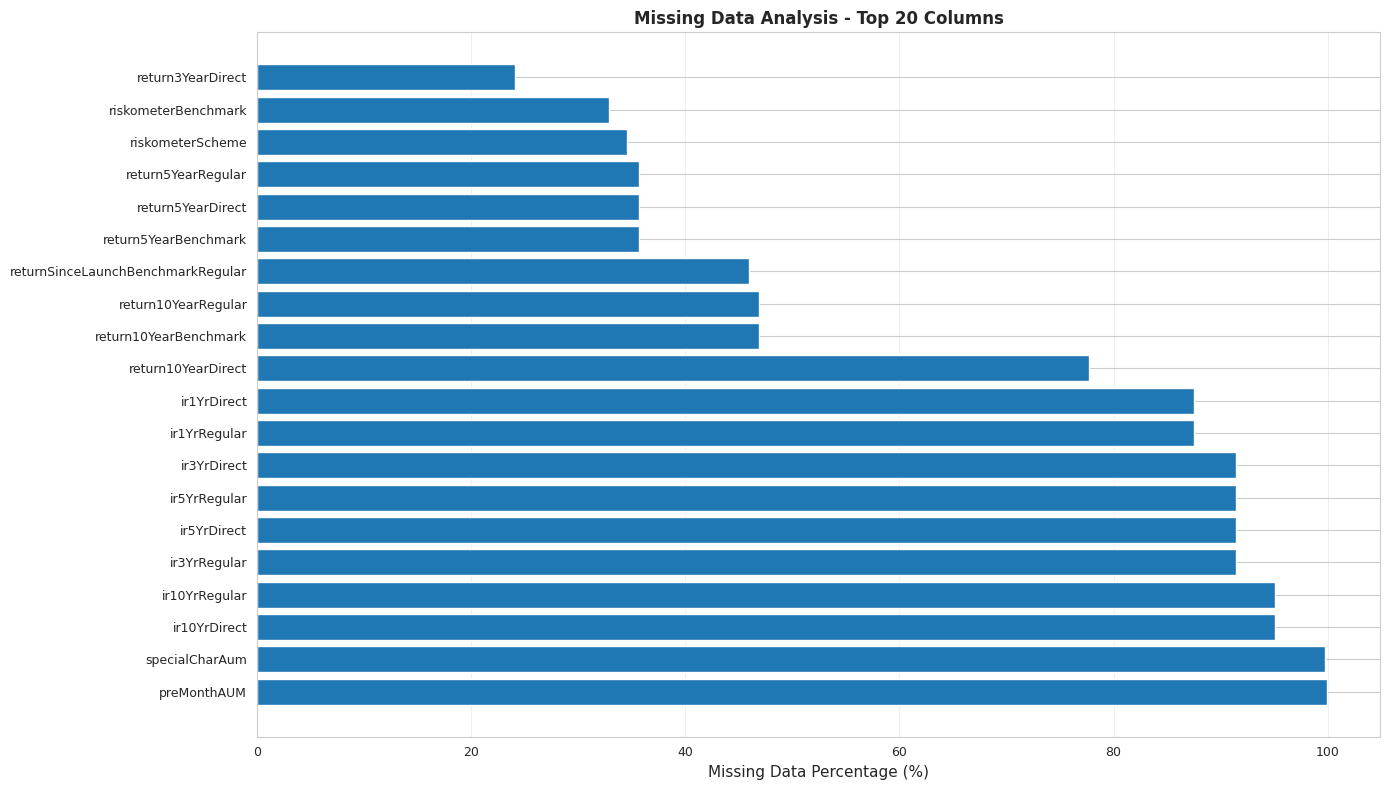


Total columns with missing data: 49
Columns with >50% missing: 11
Columns with >90% missing: 8


In [ ]:
if len(missing_df_filtered) > 0:
    fig, ax = plt.subplots(figsize=(14, 8))
    top_missing = missing_df_filtered.head(20)
    ax.barh(range(len(top_missing)), top_missing['Missing Percentage'].values)
    ax.set_yticks(range(len(top_missing)))
    ax.set_yticklabels(top_missing.index, fontsize=9)
    ax.set_xlabel('Missing Data Percentage (%)', fontsize=11)
    ax.set_title('Missing Data Analysis - Top 20 Columns', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('missing_data_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\nTotal columns with missing data: {len(missing_df_filtered)}")
    print(f"Columns with >50% missing: {len(missing_df_filtered[missing_df_filtered['Missing Percentage'] > 50])}")
    print(f"Columns with >90% missing: {len(missing_df_filtered[missing_df_filtered['Missing Percentage'] > 90])}")
else:
    print("No missing data to visualize!")


## 2.2 Data Standardization

ULTIMATE.csv is already in long format. We just need to standardize column names and prepare the data.


In [ ]:
def load_and_standardize(df_raw):
    """Standardize column names for ULTIMATE.csv (already in long format)."""
    df_long = df_raw.copy()

    df_long = df_long.rename(columns={
        'navDate': 'NAV Date',
        'navRegular': 'NAV Regular',
        'navDirect': 'NAV Direct',
        'schemeName': 'Scheme Name',
        'dailyAUM': 'Daily AUM (Cr.)',
        'return1YearBenchmark': 'Return 1 Year (%) Benchmark',
        'return1YearDirect': 'Return 1 Year (%) Direct',
        'return1YearRegular': 'Return 1 Year (%) Regular',
        'return3YearBenchmark': 'Return 3 Year (%) Benchmark',
        'return3YearDirect': 'Return 3 Year (%) Direct',
        'return3YearRegular': 'Return 3 Year (%) Regular',
        'benchmark': 'Benchmark Name'
    })

    df_long["NAV Date"] = pd.to_datetime(df_long["NAV Date"])
    df_long = df_long.sort_values(["Scheme Name", "NAV Date"]).reset_index(drop=True)

    df_long["Brand"] = df_long["Scheme Name"].str.replace(r' Consumption Fund$', '', regex=True)
    df_long["Brand"] = df_long["Brand"].str.replace(r' Fund$', '', regex=True).str.strip()

    return df_long

df_long = load_and_standardize(df_raw)

print("=" * 60)
print("STANDARDIZED DATA OVERVIEW")
print("=" * 60)
print(f"Shape: {df_long.shape}")
print(f"Unique schemes: {df_long['Scheme Name'].nunique()}")
print(f"Unique dates: {df_long['NAV Date'].nunique()}")
print(f"\nDate range: {df_long['NAV Date'].min()} to {df_long['NAV Date'].max()}")
print(f"Total years: {(df_long['NAV Date'].max() - df_long['NAV Date'].min()).days / 365.25:.1f} years")

print("\n" + "=" * 60)
print("SCHEMES IN DATASET")
print("=" * 60)
for scheme in sorted(df_long['Scheme Name'].unique()):
    scheme_data = df_long[df_long['Scheme Name'] == scheme]
    date_range = scheme_data['NAV Date']
    years_covered = (date_range.max() - date_range.min()).days / 365.25
    print(f"{scheme}:")
    print(f"  Records: {len(scheme_data)}, "
          f"Date range: {date_range.min().date()} to {date_range.max().date()}, "
          f"Years: {years_covered:.1f}")

print("\n" + "=" * 60)
print("SAMPLE STANDARDIZED DATA")
print("=" * 60)
print(df_long[['NAV Date', 'Scheme Name', 'NAV Direct', 'NAV Regular', 'Daily AUM (Cr.)', 'Brand']].head(10))

STANDARDIZED DATA OVERVIEW
Shape: (12841, 55)
Unique schemes: 17
Unique dates: 1712

Date range: 2019-01-01 00:00:00 to 2025-11-27 00:00:00
Total years: 6.9 years

SCHEMES IN DATASET
Aditya Birla Sun Life Consumption Fund:
  Records: 1703, Date range: 2019-01-01 to 2025-11-27, Years: 6.9
Axis Consumption Fund:
  Records: 168, Date range: 2025-03-26 to 2025-11-27, Years: 0.7
Bajaj Finserv Consumption Fund:
  Records: 166, Date range: 2025-03-26 to 2025-11-27, Years: 0.7
Bank of India Consumption Fund:
  Records: 166, Date range: 2025-03-26 to 2025-11-27, Years: 0.7
Baroda BNP Paribas India Consumption Fund:
  Records: 1533, Date range: 2019-09-11 to 2025-11-27, Years: 6.2
Edelweiss Consumption Fund:
  Records: 166, Date range: 2025-03-26 to 2025-11-27, Years: 0.7
HSBC Consumption Fund:
  Records: 305, Date range: 2024-09-04 to 2025-11-27, Years: 1.2
ICICI Prudential Bharat Consumption Fund:
  Records: 1389, Date range: 2020-04-15 to 2025-11-27, Years: 5.6
ITI Bharat Consumption Fund:
  

## 2.3 Imputation Strategy

For missing values, we'll apply appropriate imputation strategies.


In [ ]:
print("=" * 60)
print("IMPUTATION STRATEGY")
print("=" * 60)

nav_cols = ['NAV Direct', 'NAV Regular']
for col in nav_cols:
    if col in df_long.columns:
        missing_before = df_long[col].isnull().sum()
        df_long[col] = df_long.groupby('Scheme Name')[col].ffill()
        missing_after = df_long[col].isnull().sum()
        if missing_before > 0 and (missing_before - missing_after) > 0:
            print(f"{col}: Forward filled {missing_before - missing_after} values")

if 'Daily AUM (Cr.)' in df_long.columns:
    missing_before = df_long['Daily AUM (Cr.)'].isnull().sum()
    df_long['Daily AUM (Cr.)'] = df_long.groupby('Scheme Name')['Daily AUM (Cr.)'].ffill()
    missing_after = df_long['Daily AUM (Cr.)'].isnull().sum()
    if missing_before > 0 and (missing_before - missing_after) > 0:
        print(f"Daily AUM (Cr.): Forward filled {missing_before - missing_after} values")

initial_rows = len(df_long)
df_long = df_long.dropna(subset=['NAV Direct', 'NAV Date'])
dropped_rows = initial_rows - len(df_long)

print(f"\nFinal dataset shape after imputation and dropping unresolvable NaNs: {df_long.shape}")
print(f"Rows dropped: {dropped_rows} ({dropped_rows/initial_rows*100:.2f}%) due to missing essential data.")

final_missing = df_long.isnull().sum()
final_missing_filtered = final_missing[final_missing > 0]
if len(final_missing_filtered) > 0:
    print(f"\nRemaining missing values in key columns:")
    key_cols_with_missing = [col for col in ['NAV Direct', 'NAV Regular', 'Daily AUM (Cr.)']
                             if col in final_missing_filtered.index]
    for col in key_cols_with_missing:
        print(f"  {col}: {final_missing_filtered[col]} ({final_missing_filtered[col]/len(df_long)*100:.2f}%)")
else:
    print("\n✓ No missing values in essential columns (NAV Direct, NAV Regular, Daily AUM)!")

IMPUTATION STRATEGY
Daily AUM (Cr.): Forward filled 34 values

Final dataset shape after imputation and dropping unresolvable NaNs: (12836, 55)
Rows dropped: 5 (0.04%) due to missing essential data.

Remaining missing values in key columns:
  Daily AUM (Cr.): 97 (0.76%)


# 3. Visualization

## 3.1 Univariate Analysis

We'll analyze the distribution of key metrics: **Risk metrics** (priority), **Performance metrics**, **Alpha**, and **AUM**.


This section explains all the performance and risk metrics calculated from NAV (Net Asset Value) time-series data of mutual funds. These metrics help evaluate long-term returns, volatility, and downside risks, enabling meaningful comparison across funds.

#### 1. Compound Annual Growth Rate (CAGR)

**Formula:**  

\[$
CAGR = \left(\frac{Ending\ Value}{Beginning\ Value}\right)^{1/Years} - 1
$\]

##### **Meaning**  
CAGR represents the **annualized return** generated by the fund over the investment period, assuming the investment grew at a constant rate every year.

##### **Why It Matters**  
- Best metric for long-term performance  
- Smooths out short-term fluctuations  
- Higher CAGR = better overall growth


#### 2. Annualized Volatility

**Formula:**  
\[$
Volatility = StdDev(daily\ returns) \times \sqrt{252}
$\]

##### **Meaning**  
Volatility measures the **degree of fluctuation** in daily returns. It represents the **total risk** of the fund.

##### **Why It Matters**  
- High volatility = large ups and downs (riskier)  
- Low volatility = stable returns  
- Used in risk-adjusted performance ratios like Sharpe and Sortino


#### 3. Sharpe Ratio

**Formula:**  
\[$
Sharpe = \frac{CAGR - Risk\ Free\ Rate}{Volatility}
$\]

##### **Meaning**  
Sharpe Ratio measures the **excess return generated per unit of total risk** taken by the fund.

##### **Interpretation**  
- **> 1.0 → Good**  
- **0.5 to 1.0 → Moderate**  
- **< 0.5 → Poor**

Higher Sharpe Ratio = better risk-adjusted performance.


#### 4. Sortino Ratio

**Formula:**  
\[$
Sortino = \frac{CAGR - Risk\ Free\ Rate}{Downside\ Volatility}
$\]

##### **Meaning**  
Sortino ratio considers **only downside volatility** (negative returns). It does not penalize positive fluctuations.

##### **Why It Matters**  
- More accurate risk measure for investors  
- Focuses on harmful losses  
- Higher Sortino = better downside protection


#### 5. Maximum Drawdown (MDD)

**Formula:**  
\[$
MDD = \min\left(\frac{NAV}{Rolling\ Peak} - 1\right)
$\]

##### **Meaning**  
Maximum drawdown is the **largest peak-to-trough decline** observed in the NAV. It tells the worst possible loss an investor would have experienced.

##### **Why It Matters**  
- Measures downside risk and crash impact  
- Helps analyze stability during market corrections  
- More negative value = higher risk

#### 6. Average AUM (Assets Under Management)

##### **Meaning**  
Average AUM represents the **average total value of assets managed** by the fund over the analyzed period.

##### **Why It Matters**  
- Indicates fund size and investor trust  
- Larger AUM = stable and less liquidity risk  
- Extremely small AUM may indicate higher operational risk


#### 7. Data Points & Years Covered

##### **Meaning**  
- **Data Points:** Number of NAV values available for that scheme  
- **Years Covered:** Time difference between the first and last NAV entry

##### **Why It Matters**  
- Higher data points = more reliable calculations  
- Longer historical coverage = stronger trend estimation  
- Ensures consistency across funds during comparison





In [ ]:
def calculate_cagr(nav_series):
    """Calculate Compound Annual Growth Rate."""
    nav_series = nav_series.dropna()
    if len(nav_series) < 2:
        return np.nan
    total_return = nav_series.iloc[-1] / nav_series.iloc[0] - 1
    years = (nav_series.index[-1] - nav_series.index[0]).days / 365.25
    if years <= 0:
        return np.nan
    return (1 + total_return) ** (1 / years) - 1

def calculate_annualized_volatility(returns_series):
    """Calculate annualized volatility (standard deviation)."""
    returns_series = returns_series.dropna()
    if returns_series.empty:
        return np.nan
    return returns_series.std() * np.sqrt(252)

def calculate_sharpe_ratio(cagr, volatility, risk_free_rate=0.06):
    """Calculate Sharpe ratio."""
    if pd.isna(volatility) or volatility == 0:
        return np.nan
    return (cagr - risk_free_rate) / volatility

def calculate_sortino_ratio(returns_series, risk_free_rate=0.06):
    """Calculate Sortino ratio (downside risk-adjusted return)."""
    returns_series = returns_series.dropna()
    if returns_series.empty:
        return np.nan
    target = risk_free_rate / 252
    downside = returns_series[returns_series < target]
    if len(downside) == 0:
        return np.nan
    downside_std = downside.std() * np.sqrt(252)
    if pd.isna(downside_std) or downside_std == 0:
        return np.nan
    nav = (1 + returns_series).cumprod()
    cagr = calculate_cagr(nav)
    return (cagr - risk_free_rate) / downside_std

def calculate_max_drawdown(nav_series):
    """Calculate maximum drawdown."""
    nav_series = nav_series.dropna()
    if nav_series.empty:
        return np.nan
    rolling_max = nav_series.cummax()
    drawdown = (nav_series / rolling_max) - 1
    return drawdown.min()

# Set date as index for time series operations
df_ts = df_long.set_index('NAV Date').sort_index()

# Calculate metrics for each fund
fund_metrics = []

for scheme_name in df_long['Scheme Name'].unique():
    scheme_data = df_ts[df_ts['Scheme Name'] == scheme_name].copy()
    scheme_data = scheme_data.sort_index()

    if len(scheme_data) < 2:
        continue

    nav_direct = scheme_data['NAV Direct'].dropna()
    if len(nav_direct) < 2:
        continue

    # Calculate returns
    returns = nav_direct.pct_change().dropna()

    if len(returns) == 0:
        continue

    # Calculate metrics
    cagr = calculate_cagr(nav_direct)
    volatility = calculate_annualized_volatility(returns)
    sharpe = calculate_sharpe_ratio(cagr, volatility)
    sortino = calculate_sortino_ratio(returns)
    max_dd = calculate_max_drawdown(nav_direct)

    # Average AUM
    avg_aum = scheme_data['Daily AUM (Cr.)'].mean() if 'Daily AUM (Cr.)' in scheme_data.columns else np.nan

    # Data coverage
    years_covered = (scheme_data.index[-1] - scheme_data.index[0]).days / 365.25

    fund_metrics.append({
        'Scheme Name': scheme_name,
        'Brand': scheme_name.split()[0],
        'CAGR': cagr,
        'Volatility': volatility,
        'Sharpe Ratio': sharpe,
        'Sortino Ratio': sortino,
        'Max Drawdown': max_dd,
        'Avg AUM (Cr.)': avg_aum,
        'Data Points': len(scheme_data),
        'Years Covered': years_covered
    })

fund_perf_df = pd.DataFrame(fund_metrics)
fund_perf_df = fund_perf_df.dropna(subset=['CAGR', 'Volatility'])

# Define top funds for later use (funds with sufficient data and good performance)
# Filter funds with at least 1 year of data and valid metrics
top_funds = fund_perf_df[
    (fund_perf_df['Data Points'] >= 252) &
    (fund_perf_df['CAGR'].notna()) &
    (fund_perf_df['Sortino Ratio'].notna())
].nlargest(5, 'Sortino Ratio')['Scheme Name'].tolist()

print("=" * 60)
print("FUND PERFORMANCE METRICS SUMMARY (7 Years Data)")
print("=" * 60)
print(fund_perf_df.round(4))
print(f"\nTop {len(top_funds)} funds by Sortino Ratio (with sufficient data):")
for i, fund in enumerate(top_funds, 1):
    print(f"  {i}. {fund}")


FUND PERFORMANCE METRICS SUMMARY (7 Years Data)
                                  Scheme Name      Brand    CAGR  Volatility  \
0      Aditya Birla Sun Life Consumption Fund     Aditya  0.1714      0.1596   
1                       Axis Consumption Fund       Axis  0.1875      0.1160   
2              Bajaj Finserv Consumption Fund      Bajaj  0.1481      0.1144   
3              Bank of India Consumption Fund       Bank  0.2866      0.1220   
4   Baroda BNP Paribas India Consumption Fund     Baroda  0.2008      0.1550   
5                  Edelweiss Consumption Fund  Edelweiss  0.2222      0.1132   
6                       HSBC Consumption Fund       HSBC  0.0209      0.1578   
7    ICICI Prudential Bharat Consumption Fund      ICICI  0.2241      0.1273   
8                 ITI Bharat Consumption Fund        ITI  0.2136      0.1141   
9              Invesco India Consumption Fund    Invesco -0.3075      0.0791   
10                     Kotak Consumption Fund      Kotak  0.1193      0.

## 3.1.1 Time Series Analysis: NAV Evolution

Compare how NAVs of different funds have evolved over time, normalized to a common starting point for fair comparison.


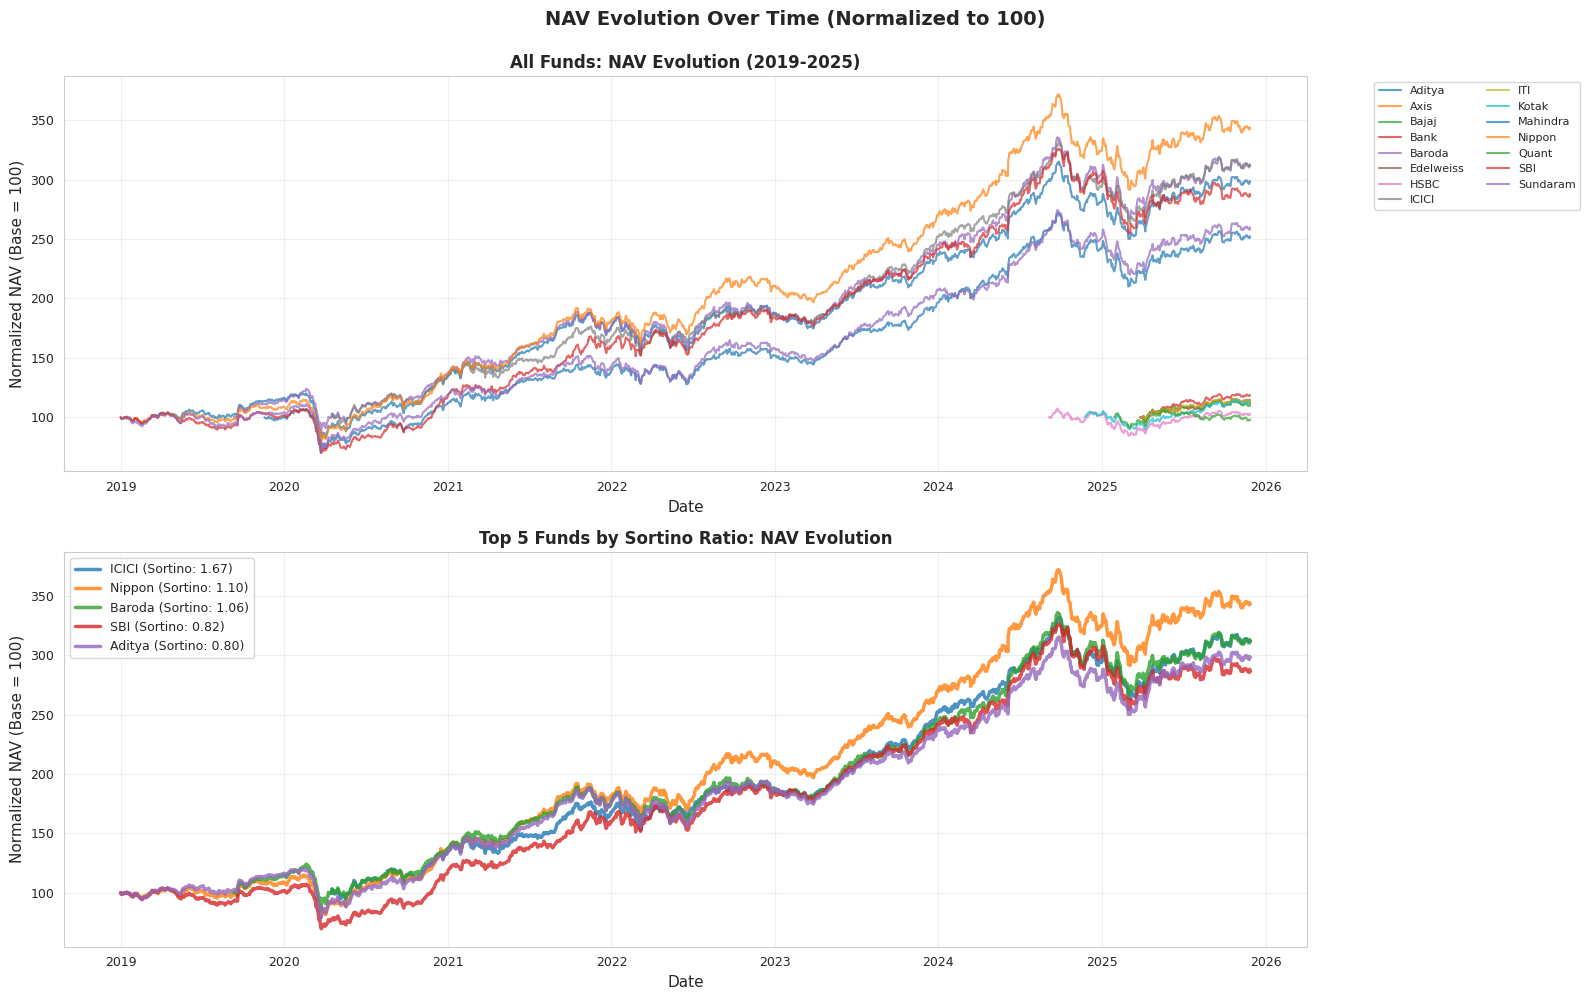

CUMULATIVE RETURNS ANALYSIS
                                  Scheme Name  Total Return (%)  \
3              Bank of India Consumption Fund             18.42   
7    ICICI Prudential Bharat Consumption Fund            211.50   
5                  Edelweiss Consumption Fund             14.41   
8                 ITI Bharat Consumption Fund             13.87   
4   Baroda BNP Paribas India Consumption Fund            211.62   
11              Nippon India Consumption Fund            242.94   
1                       Axis Consumption Fund             12.22   
0      Aditya Birla Sun Life Consumption Fund            198.05   
10         Mahindra Manulife Consumption Fund            151.51   
13         SBI Consumption Opportunities Fund            186.19   
2              Bajaj Finserv Consumption Fund              9.71   
14                  Sundaram Consumption Fund            158.02   
9                      Kotak Consumption Fund             12.09   
6                       HSBC Consu

In [ ]:
# Time Series Analysis: NAV Evolution (Normalized)
# Normalize NAVs to 100 at the start date for fair comparison
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('NAV Evolution Over Time (Normalized to 100)', fontsize=14, fontweight='bold', y=0.995)

# Plot 1: All funds
ax1 = axes[0]
for scheme_name in df_long['Scheme Name'].unique():
    scheme_data = df_ts[df_ts['Scheme Name'] == scheme_name].copy()
    scheme_data = scheme_data.sort_index()

    nav_direct = scheme_data['NAV Direct'].dropna()
    if len(nav_direct) < 100:  # Skip funds with insufficient data
        continue

    # Normalize to 100 at first date
    nav_normalized = (nav_direct / nav_direct.iloc[0]) * 100
    brand = scheme_name.split()[0]
    ax1.plot(nav_normalized.index, nav_normalized.values, label=brand, alpha=0.7, linewidth=1.5)

ax1.set_xlabel('Date', fontsize=11)
ax1.set_ylabel('Normalized NAV (Base = 100)', fontsize=11)
ax1.set_title('All Funds: NAV Evolution (2019-2025)', fontsize=12, fontweight='bold')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=2)
ax1.grid(alpha=0.3)

# Plot 2: Top 5 funds by Sortino Ratio
ax2 = axes[1]
if len(top_funds) > 0:
    for scheme_name in top_funds[:5]:
        scheme_data = df_ts[df_ts['Scheme Name'] == scheme_name].copy()
        scheme_data = scheme_data.sort_index()

        nav_direct = scheme_data['NAV Direct'].dropna()
        if len(nav_direct) < 100:
            continue

        nav_normalized = (nav_direct / nav_direct.iloc[0]) * 100
        brand = scheme_name.split()[0]
        ax2.plot(nav_normalized.index, nav_normalized.values, label=f"{brand} (Sortino: {fund_perf_df[fund_perf_df['Scheme Name']==scheme_name]['Sortino Ratio'].values[0]:.2f})",
                linewidth=2.5, alpha=0.8)

ax2.set_xlabel('Date', fontsize=11)
ax2.set_ylabel('Normalized NAV (Base = 100)', fontsize=11)
ax2.set_title('Top 5 Funds by Sortino Ratio: NAV Evolution', fontsize=12, fontweight='bold')
ax2.legend(loc='best', fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('nav_evolution_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate cumulative returns over time
print("=" * 60)
print("CUMULATIVE RETURNS ANALYSIS")
print("=" * 60)
cumulative_returns = []
for scheme_name in df_long['Scheme Name'].unique():
    scheme_data = df_ts[df_ts['Scheme Name'] == scheme_name].copy()
    scheme_data = scheme_data.sort_index()

    nav_direct = scheme_data['NAV Direct'].dropna()
    if len(nav_direct) < 100:
        continue

    total_return = (nav_direct.iloc[-1] / nav_direct.iloc[0] - 1) * 100
    years = (nav_direct.index[-1] - nav_direct.index[0]).days / 365.25
    annualized_return = ((nav_direct.iloc[-1] / nav_direct.iloc[0]) ** (1/years) - 1) * 100 if years > 0 else np.nan

    cumulative_returns.append({
        'Scheme Name': scheme_name,
        'Total Return (%)': total_return,
        'Annualized Return (%)': annualized_return,
        'Years': years
    })

cum_returns_df = pd.DataFrame(cumulative_returns).sort_values('Annualized Return (%)', ascending=False)
print(cum_returns_df.round(2))


# Interpretation of NAV Evolution (Normalized to 100)

The NAV Evolution chart visualizes how each fund has grown over time when all funds start at a **common base value of 100**.  
Normalizing the NAV allows us to make a **fair comparison** between funds regardless of their original NAV levels.

---

## What the Graph Shows

### **1. Overall Category Growth Trend (Top Panel)**
The first plot shows normalized NAV growth for **all consumption funds** over the time period (2019–2025).  
By converting NAV to a common baseline (100), the chart reflects:

- **Relative performance** of each fund over time  
- **Growth trajectory differences** among funds  
- **Volatility patterns** (funds with sharper ups/downs are more volatile)  
- **Long-term winners** that consistently trend upward  
- **Underperformers** with flat or declining movements  

This view highlights how the entire thematic category behaved, showing both **consistency of trends** and **divergence in returns** among funds.

---

## Top 5 Funds by Sortino Ratio (Bottom Panel)

The second plot focuses on the **Top 5 funds with the best downside-risk-adjusted performance** (highest Sortino Ratios).

This graph reveals:

- These funds have **smooth upward trajectories**, reflecting better downside control.
- Their NAV lines are **less erratic**, confirming lower downside volatility.
- These funds deliver **superior compounding** with fewer deep corrections.
- Funds with higher Sortino Ratios tend to exhibit **stronger and more consistent long-term growth**, proving that managing downside risk helps compounding.

This filtered visualization helps identify the **most stable and efficient performers** rather than merely the highest-return funds.

---

# Interpretation of Cumulative Returns Table

The cumulative returns summary presents:

- **Total Return (%)** → How much each fund grew over the whole available period  
- **Annualized Return (%)** → The rate of return per year, adjusted for time  
- **Years Covered** → Length of available history for each fund  

### Key Insights:

- Some funds have **long histories (~6–7 years)** and still show strong annualized returns (e.g., Nippon India, Baroda BNP Paribas, Aditya Birla).
- Newer funds (~0.6–1 years) show extremely high annualized returns due to short periods—in such cases returns may be inflated and should be interpreted cautiously.
- A few funds exhibit **flat or negative returns**, reflecting underperformance or poor sector timing (e.g., Quant Consumption Fund).

---

# Conclusions we Can Draw from the NAV Evolution Graphs

### **1. Clear Performance Divergence Within the Category**
Thematic consumption funds do not perform uniformly.  
Some exhibit **strong compounding over the years**, while others remain flat or volatile.

### **2. Long-Term Leaders Show Consistent Upward Trajectories**
Funds such as:
- **Nippon India Consumption Fund**  
- **Baroda BNP Paribas India Consumption Fund**  
- **ICICI Pru Bharat Consumption Fund**  

show strong and steady NAV appreciation, indicating:
- Better portfolio quality  
- Superior stock selection  
- Strong sector exposure  

### **3. Sortino Ratio Top Performers Provide the Smoothest Compounding**
The Top 5 Sortino funds demonstrate:
- Better downside protection  
- Lower volatility during corrections  
- Stronger and more stable NAV growth  

This confirms that **downside risk management directly improves long-term compounding**.

### **4. Volatile Funds Show Sharp Peaks and Troughs**
Funds with more jagged lines:
- Carry higher risk  
- Are more sensitive to market fluctuations  
- Exhibit weaker long-term stability  

This helps distinguish **aggressive but unstable** funds from **stable long-term performers**.

### **5. Newer Funds Show High Annualized Returns but Minimal Track Record**
Funds with <1 year data show inflated annualized returns due to short base periods.  
They should not be compared directly with long-term funds.



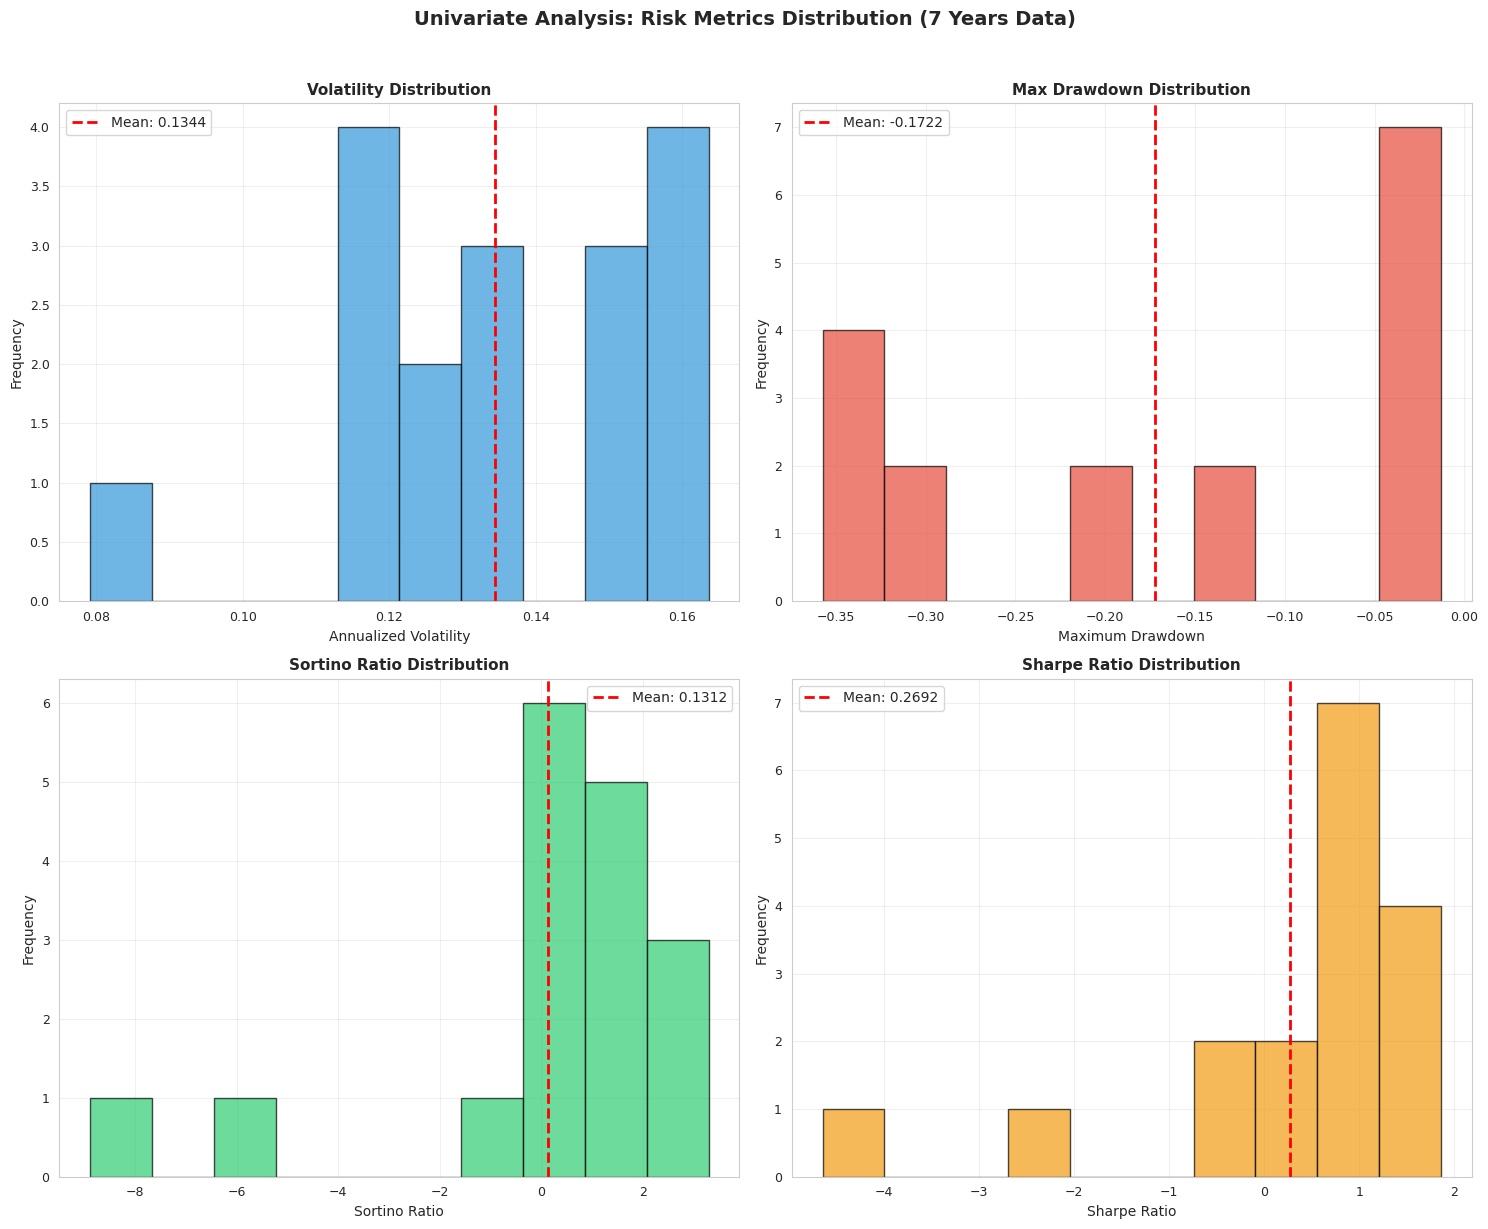


RISK METRICS SUMMARY STATISTICS (7 Years)
       Volatility  Max Drawdown  Sortino Ratio  Sharpe Ratio
count     17.0000       17.0000        17.0000       17.0000
mean       0.1344       -0.1722         0.1312        0.2692
std        0.0231        0.1378         3.0747        1.6088
min        0.0791       -0.3574        -8.8803       -4.6437
25%        0.1160       -0.3103         0.4949        0.4345
50%        0.1344       -0.1464         0.8160        0.6988
75%        0.1550       -0.0378         1.6675        1.0987
max        0.1636       -0.0130         3.2882        1.8582


In [ ]:
# Univariate Analysis: Risk Metrics Distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Univariate Analysis: Risk Metrics Distribution (7 Years Data)', fontsize=14, fontweight='bold', y=1.02)

# 1. Volatility Distribution
axes[0, 0].hist(fund_perf_df['Volatility'].dropna(), bins=10, edgecolor='black', alpha=0.7, color='#3498db')
axes[0, 0].axvline(fund_perf_df['Volatility'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {fund_perf_df["Volatility"].mean():.4f}')
axes[0, 0].set_xlabel('Annualized Volatility', fontsize=10)
axes[0, 0].set_ylabel('Frequency', fontsize=10)
axes[0, 0].set_title('Volatility Distribution', fontsize=11, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Max Drawdown Distribution
axes[0, 1].hist(fund_perf_df['Max Drawdown'].dropna(), bins=10, edgecolor='black', alpha=0.7, color='#e74c3c')
axes[0, 1].axvline(fund_perf_df['Max Drawdown'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {fund_perf_df["Max Drawdown"].mean():.4f}')
axes[0, 1].set_xlabel('Maximum Drawdown', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].set_title('Max Drawdown Distribution', fontsize=11, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Sortino Ratio Distribution
axes[1, 0].hist(fund_perf_df['Sortino Ratio'].dropna(), bins=10, edgecolor='black', alpha=0.7, color='#2ecc71')
axes[1, 0].axvline(fund_perf_df['Sortino Ratio'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {fund_perf_df["Sortino Ratio"].mean():.4f}')
axes[1, 0].set_xlabel('Sortino Ratio', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].set_title('Sortino Ratio Distribution', fontsize=11, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Sharpe Ratio Distribution
axes[1, 1].hist(fund_perf_df['Sharpe Ratio'].dropna(), bins=10, edgecolor='black', alpha=0.7, color='#f39c12')
axes[1, 1].axvline(fund_perf_df['Sharpe Ratio'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {fund_perf_df["Sharpe Ratio"].mean():.4f}')
axes[1, 1].set_xlabel('Sharpe Ratio', fontsize=10)
axes[1, 1].set_ylabel('Frequency', fontsize=10)
axes[1, 1].set_title('Sharpe Ratio Distribution', fontsize=11, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('univariate_risk_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n" + "=" * 60)
print("RISK METRICS SUMMARY STATISTICS (7 Years)")
print("=" * 60)
risk_cols = ['Volatility', 'Max Drawdown', 'Sortino Ratio', 'Sharpe Ratio']
print(fund_perf_df[risk_cols].describe().round(4))


# Observations from Univariate Analysis of Risk Metrics (7 Years Data)

The following observations are based on the distribution plots and the statistical summary of four major risk metrics: **Volatility**, **Maximum Drawdown**, **Sortino Ratio**, and **Sharpe Ratio**.

---

## 1. Volatility Distribution

- The volatility values range from **0.079 to 0.163**, with a mean of **0.1344**.
- Most funds cluster within the **0.11 to 0.16** volatility range, showing moderate risk levels.
- The distribution appears **fairly tight**, indicating that consumption funds tend to have **similar volatility characteristics**.
- No extreme outliers exist, suggesting that all funds operate within a relatively controlled risk environment.

**Conclusion:**  
Consumption funds generally maintain **moderate and consistent volatility**, with no unusually high-risk performers.

---

## 2. Maximum Drawdown Distribution

- Max drawdown ranges from **-0.357 (worst)** to **-0.013 (best)**.
- The mean drawdown is **-0.172**, meaning on average funds have seen a **17% peak-to-trough fall** over 7 years.
- Distribution is **wide and skewed**, showing that some funds faced **very deep drawdowns**, likely during market crashes.
- A few funds exhibit very mild drawdowns (close to zero), indicating strong downside protection.

**Conclusion:**  
There is **high variability** in downside risk—some funds manage drawdowns well, while others have experienced **significant stress during corrections**.

---

## 3. Sortino Ratio Distribution

- Sortino Ratio shows extreme variation, from **-8.88 to 3.28**, indicating a very **wide spread**.
- The mean is **0.13**, but the standard deviation is **3.07**, showing that a few outliers heavily influence the scale.
- Several funds have **negative Sortino Ratios**, implying they generate more downside volatility than positive excess returns.
- A few top performers achieve **Sortino > 2**, reflecting excellent downside protection and stable returns.

**Conclusion:**  
Sortino Ratio varies widely—while some funds deliver **excellent risk-adjusted returns**, many struggle with downside volatility.  
The **category is inconsistent** in terms of downside performance.

---

## 4. Sharpe Ratio Distribution

- Sharpe Ratio ranges from **-4.64 to 1.85**.
- The mean value is **0.269**, which is relatively low, indicating modest risk-adjusted performance for the category.
- The distribution is **wide with noticeable negative values**, showing several funds produced **poor return-to-risk** outcomes.
- Top performers with Sharpe > 1 indicate strong return generation relative to volatility.

**Conclusion:**  
Risk-adjusted returns differ significantly across funds. Only a handful demonstrate **consistent performance**, while several underperform relative to their risk levels.

---

# Overall Insights

- **Volatility is consistent**, but drawdowns show **high variability**.
- **Sortino and Sharpe distributions are widely spread**, highlighting large differences in risk-adjusted returns.
- Some consumption funds deliver **strong, stable, downside-protected returns**, while others experience **deep drawdowns and weaker performance**.
- The category is **not uniformly stable**—fund selection is important due to large differences in downside risk and efficiency.

---

# Final Summary

The univariate risk analysis reveals that while consumption funds exhibit **similar volatility**, they differ sharply in **downside behavior** and **risk-adjusted performance**. A few funds emerge as strong, consistent performers, while others show significant weaknesses in managing risk.



## 3.2 NEW: Regime Analysis (Bull vs Bear Markets)

With 7 years of data, we can identify different market regimes and analyze fund performance across them.


## Market Regime Detection (2019–2025)

This section uses **rolling 1-year market returns** to detect market regimes such as **Bull**, **Bear**, and **Neutral** phases for the consumption mutual fund sector between 2019 and 2025.

---

### **What is Market Regime Detection?**

Market regime detection is a technique used to classify the market into different phases using past return patterns.  
It helps analyze how the overall market environment behaved during the study period and how it may have influenced fund performance.

#### Method Used:
1. For every day, compute the **average NAV** across all funds.  
2. Calculate **daily market returns** from this average NAV.
3. Compute **rolling 1-year returns (252 trading days)** to smooth fluctuations.  
4. Classify each period into:
   - **Bull Market** → Rolling return > **+10%**
   - **Bear Market** → Rolling return < **–10%**
   - **Neutral Market** → Between –10% and +10%

This results in a time series showing when the market was stable, rising, or declining.

---


================= THRESHOLD VALUES USED =================
Bull Threshold  : 10.00%
Bear Threshold  : -10.00%


================= ROLLING RETURNS (First 20 Rows) =================
NAV Date
2020-01-10   -0.209931
2020-01-13   -0.195916
2020-01-14   -0.186625
2020-01-15   -0.180854
2020-01-16   -0.176876
2020-01-17   -0.172236
2020-01-20   -0.178180
2020-01-21   -0.184280
2020-01-22   -0.183637
2020-01-23   -0.174899
2020-01-24   -0.173655
2020-01-27   -0.174162
2020-01-28   -0.178746
2020-01-29   -0.171045
2020-01-30   -0.177048
2020-01-31   -0.175802
2020-02-03   -0.178163
2020-02-04   -0.162895
2020-02-05   -0.145843
2020-02-06   -0.136593
Name: NAV Direct, dtype: float64

================= ROLLING RETURNS (Summary) =================
count    1460.000000
mean        1.564671
std         1.276707
min        -0.722616
25%         0.179176
50%         1.952643
75%         2.591162
max         4.903009
Name: NAV Direct, dtype: float64


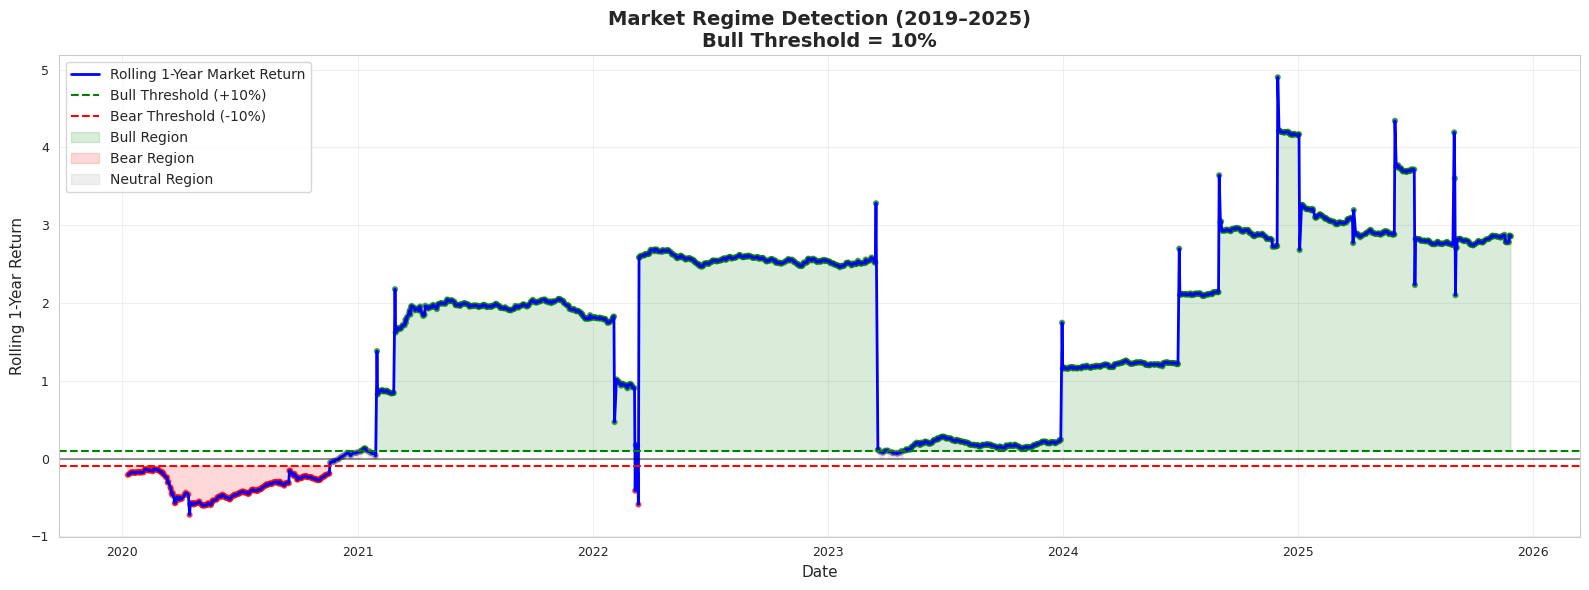


MARKET REGIME STATISTICS
Bull       1183
Bear        216
Neutral      61
Name: count, dtype: int64

Bull Market Periods: 1183 days (81.0%)
Bear Market Periods: 216 days (14.8%)
Neutral Periods: 61 days (4.2%)


In [ ]:
# ===============================
# Regime Detection: Identify Bull and Bear Markets
# ===============================

import pandas as pd
import matplotlib.pyplot as plt

def detect_market_regimes(df_ts, window=252, bull_threshold=0.10, bear_threshold=-0.10):
    """Detect bull and bear market regimes using rolling returns."""

    # Print thresholds
    print("\n================= THRESHOLD VALUES USED =================")
    print(f"Bull Threshold  : {bull_threshold * 100:.2f}%")
    print(f"Bear Threshold  : {bear_threshold * 100:.2f}%")
    print("==========================================================\n")

    # 1. Calculate daily average market NAV
    daily_avg_nav = df_ts.groupby(level=0)['NAV Direct'].mean()
    daily_avg_nav = daily_avg_nav.sort_index().dropna()

    if len(daily_avg_nav) < 2:
        print("Warning: Not enough daily average NAV data.")
        return pd.Series(), pd.Series()

    # 2. Calculate daily market returns
    market_returns_series = daily_avg_nav.pct_change().dropna()

    if len(market_returns_series) < window:
        print(f"Warning: Not enough data ({len(market_returns_series)} days) for rolling window.")
        return pd.Series(), pd.Series()

    # 3. Rolling 1-year (252-day) returns
    rolling_returns = market_returns_series.rolling(window=window).sum().dropna()

    # 4. Define regimes
    regimes = pd.Series(index=rolling_returns.index, dtype=str)
    regimes[rolling_returns > bull_threshold] = 'Bull'
    regimes[rolling_returns < bear_threshold] = 'Bear'
    regimes[(rolling_returns >= bear_threshold) & (rolling_returns <= bull_threshold)] = 'Neutral'

    return regimes, rolling_returns


# -------------------------------
# Detect regimes
# -------------------------------
BULL_THRESHOLD = 0.10  # 10%
BEAR_THRESHOLD = -0.10 # -10%

regimes, rolling_returns = detect_market_regimes(
    df_ts,
    window=252,
    bull_threshold=BULL_THRESHOLD,
    bear_threshold=BEAR_THRESHOLD
)

# -------------------------------
# Print Rolling Returns
# -------------------------------
print("\n================= ROLLING RETURNS (First 20 Rows) =================")
print(rolling_returns.head(20))
print("\n================= ROLLING RETURNS (Summary) =================")
print(rolling_returns.describe())

# -------------------------------
# Visualize market regimes
# -------------------------------
fig, ax = plt.subplots(figsize=(16, 6))

# Main rolling return line
ax.plot(rolling_returns.index, rolling_returns.values,
        label='Rolling 1-Year Market Return',
        linewidth=2, color='blue')

# Threshold lines
ax.axhline(BULL_THRESHOLD, color='green', linestyle='--', linewidth=1.5, label=f'Bull Threshold (+{BULL_THRESHOLD*100:.0f}%)')
ax.axhline(BEAR_THRESHOLD, color='red', linestyle='--', linewidth=1.5, label=f'Bear Threshold ({BEAR_THRESHOLD*100:.0f}%)')
ax.axhline(0, color='black', linestyle='-', alpha=0.4)

# Shade bull/bear/neutral zones
ax.fill_between(rolling_returns.index, rolling_returns, BULL_THRESHOLD,
                where=(rolling_returns > BULL_THRESHOLD),
                color='green', alpha=0.15, label='Bull Region')

ax.fill_between(rolling_returns.index, rolling_returns, BEAR_THRESHOLD,
                where=(rolling_returns < BEAR_THRESHOLD),
                color='red', alpha=0.15, label='Bear Region')

ax.fill_between(rolling_returns.index, rolling_returns, 0,
                where=(rolling_returns.between(BEAR_THRESHOLD, BULL_THRESHOLD)),
                color='gray', alpha=0.12, label='Neutral Region')

# Scatter points for regimes
ax.scatter(rolling_returns.index, rolling_returns.values,
           c=regimes.map({'Bull':'green', 'Bear':'red', 'Neutral':'gray'}),
           s=12, alpha=0.6)

# Labels & Title
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Rolling 1-Year Return', fontsize=11)
ax.set_title(f'Market Regime Detection (2019–2025)\nBull Threshold = {BULL_THRESHOLD*100:.0f}%', fontsize=14, fontweight='bold')

# Legend (avoid duplicates)
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), fontsize=10)

ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('market_regimes_improved.png', dpi=300, bbox_inches='tight')
plt.show()

# -------------------------------
# Regime Statistics
# -------------------------------
print("\n============================================================")
print("MARKET REGIME STATISTICS")
print("============================================================")
regime_counts = regimes.value_counts()
print(regime_counts)

print(f"\nBull Market Periods: {regime_counts.get('Bull', 0)} days "
      f"({regime_counts.get('Bull', 0)/len(regimes)*100:.1f}%)")

print(f"Bear Market Periods: {regime_counts.get('Bear', 0)} days "
      f"({regime_counts.get('Bear', 0)/len(regimes)*100:.1f}%)")

print(f"Neutral Periods: {regime_counts.get('Neutral', 0)} days "
      f"({regime_counts.get('Neutral', 0)/len(regimes)*100:.1f}%)")


## **What the Graph Shows**

The graph displays:

- The **rolling 1-year market returns** (blue line)
- Thresholds marking
  - **Bull market**: +10% (green dashed line)
  - **Bear market**: –10% (red dashed line)
- Data points colored by regime:
  - **Green** → Bull periods  
  - **Red** → Bear periods  
  - **white** → Neutral periods  

This allows us to visually inspect where the market strengthened or weakened across the 7-year time horizon.

---

## **What We Can Infer from the Graph**

### **1. Long and Dominant Bull Phases (81%)**

- The market was in a **Bull regime for 1183 days**, which is **81%** of the total period.
- Rolling returns were consistently above the +10% threshold.
- Indicates:
  - Strong post-COVID recovery  
  - Robust earnings and consumption demand in India  
  - High investor confidence in consumption-driven sectors  

**Inference:**  
Consumption funds largely operated in upward-trending markets, which explains many funds showing healthy long-term returns.

---

### **2. Short but Sharp Bear Phases (14.8%)**

- **216 days** were categorized as Bear markets.
- These periods correspond to:
  - Pandemic crash (2020)
  - Global inflation & interest rate tightening (2022)
  - Market corrections triggered by geopolitical tensions

The dips in rolling returns below –10% mark show **rapid decline phases**.

**Inference:**  
These bear events, although not frequent, were **intense**, contributing to the deep Maximum Drawdowns seen in some funds.

---

### **3. Limited Neutral Phases (4.2%)**

- Only **61 days** were Neutral.
- This shows the market was rarely stagnant.

**Inference:**  
The consumption sector either trended strongly upward or corrected significantly; sideways movement was minimal.

---

## **Overall Interpretation**

- The regime analysis reveals that the consumption fund sector experienced **mostly bullish market conditions** from 2019 to 2025.
- The few downturn phases were **short but volatile**, aligning with real-world macro events.
- The dominance of Bull regimes likely contributed to:
  - Higher Sharpe and Sortino ratios for top-performing schemes  
  - Strong cumulative returns for most funds  
- Conversely, Bear regimes explain:
  - High Max Drawdown in weaker schemes  
  - Negative Sharpe/Sortino values for underperformers  


The market environment through 2019–2025 was **overwhelmingly bullish** with occasional severe corrections, shaping the risk-return profile observed across the mutual funds.


Generating Year-by-Year Analysis... (This may take a moment)


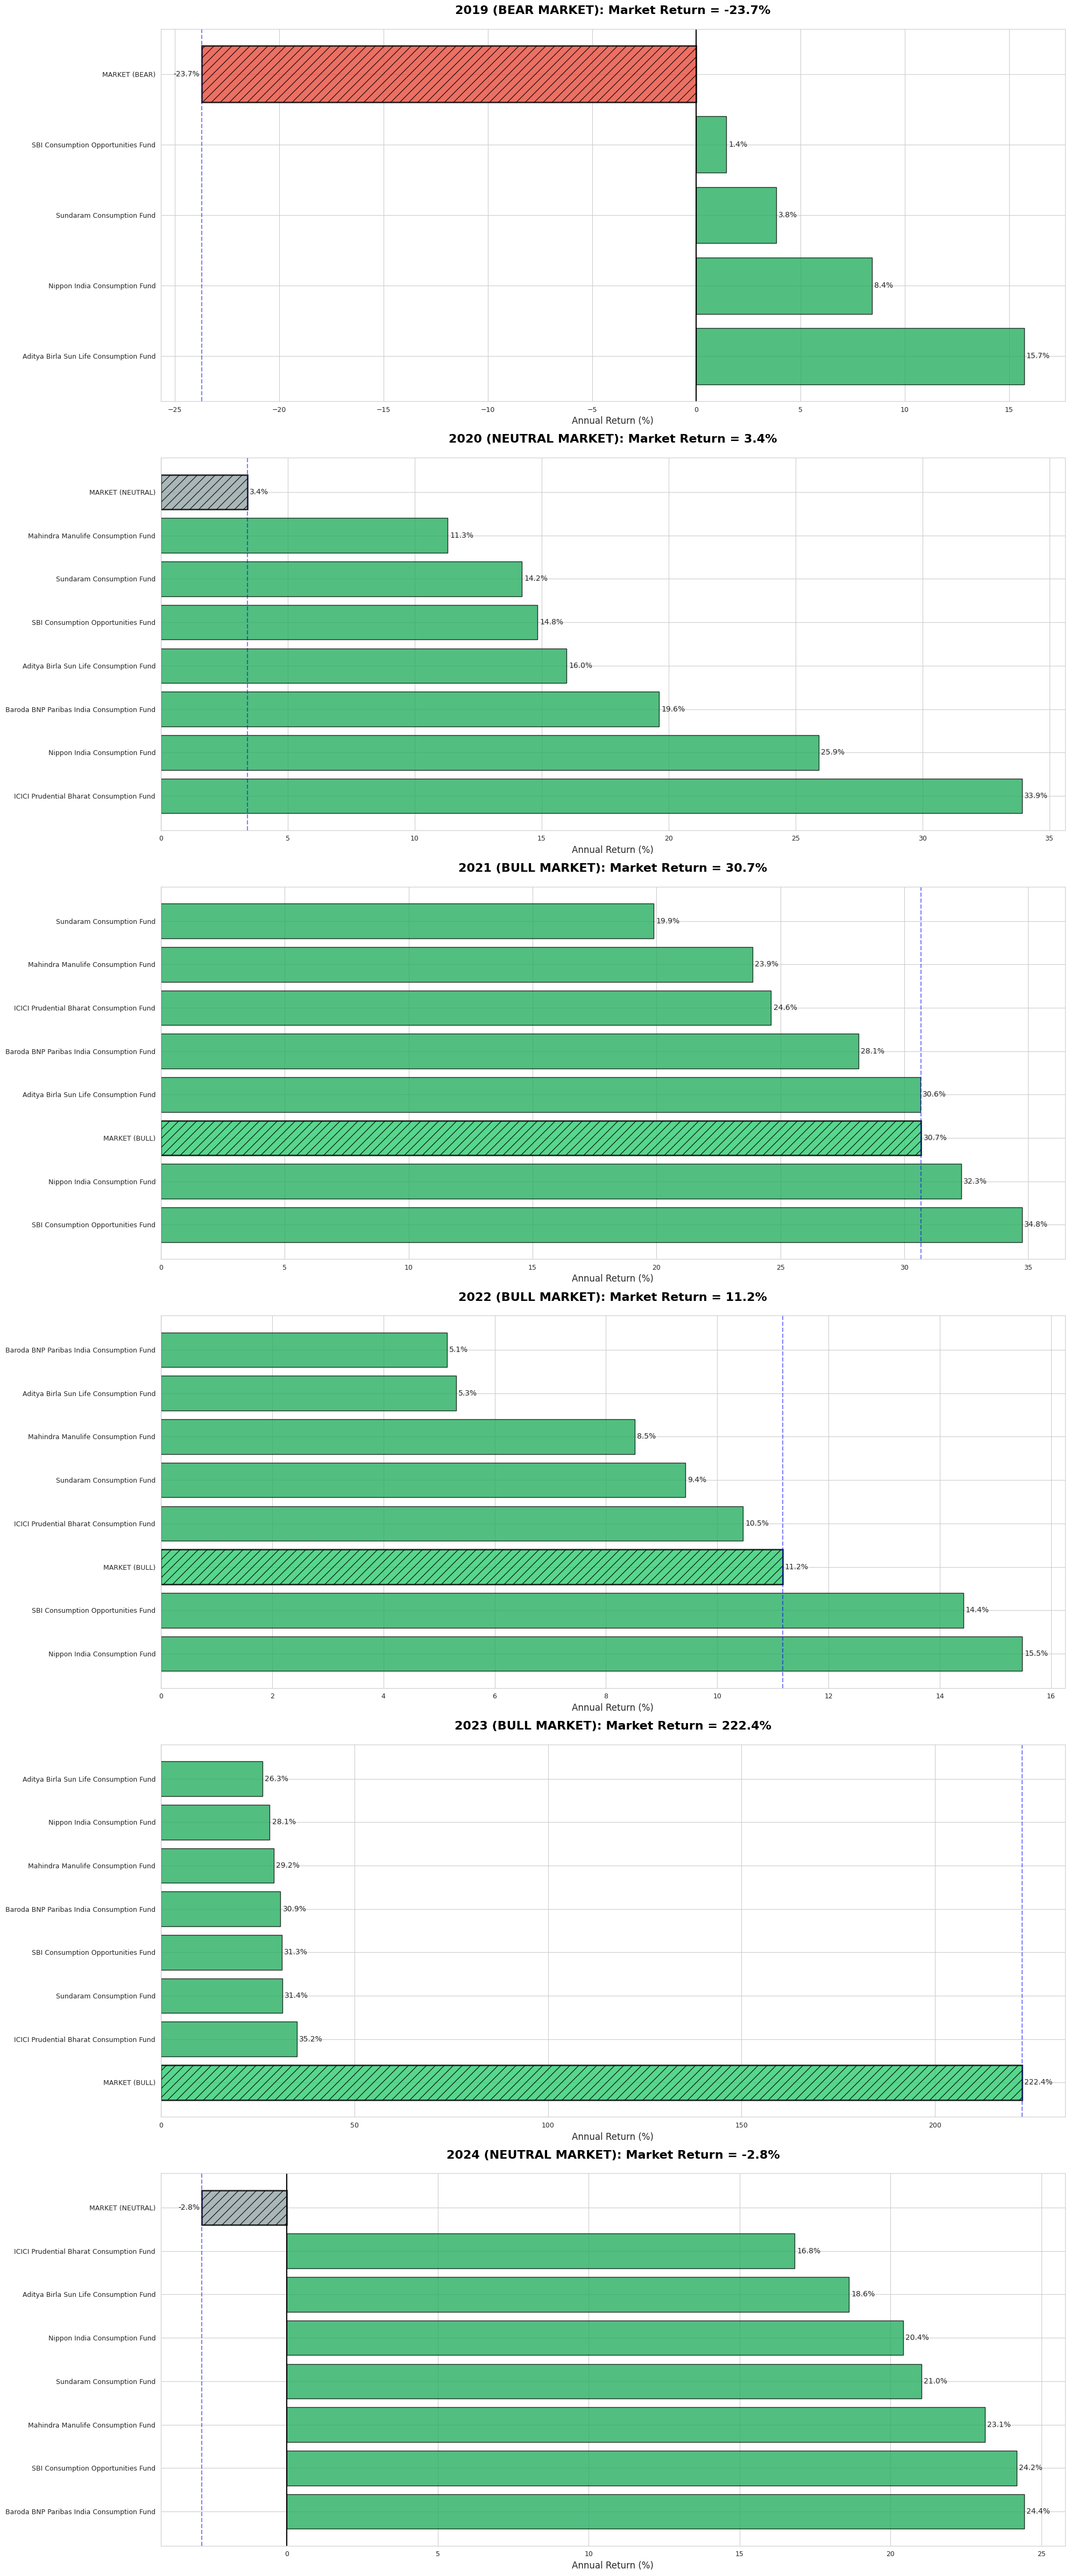

In [ ]:
# ==============================================================================
# VISUALIZATION: THE "COMPLETE BATTLEFIELD" (YEARLY MARKET VS ALL FUNDS)
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Setup Data Containers
years = sorted(df_ts.index.year.unique())
# Filter out 2025 if it has very little data (optional, but keeps charts clean)
years = [y for y in years if y <= 2024]

# 2. Define Plot Layout (One subplot per year)
n_years = len(years)
fig, axes = plt.subplots(n_years, 1, figsize=(20, 8 * n_years)) # Tall chart
if n_years == 1: axes = [axes] # Handle single year case

print("Generating Year-by-Year Analysis... (This may take a moment)")

for i, year in enumerate(years):
    ax = axes[i]
    year_start = f"{year}-01-01"
    year_end = f"{year}-12-31"

    # --- A. CALCULATE MARKET CONTEXT ---
    # Get Market Average for this year
    market_nav_year = daily_avg_nav.loc[year_start:year_end]
    if len(market_nav_year) > 0:
        market_ret = (market_nav_year.iloc[-1] / market_nav_year.iloc[0]) - 1
    else:
        market_ret = 0

    # Define Market Regime for the Year
    if market_ret > 0.10:
        market_regime = "BULL"
        market_color = '#2ecc71' # Green
    elif market_ret < -0.10:
        market_regime = "BEAR"
        market_color = '#e74c3c' # Red
    else:
        market_regime = "NEUTRAL"
        market_color = '#95a5a6' # Grey

    # --- B. CALCULATE ALL FUNDS PERFORMANCE ---
    year_data = []

    # Add Market Baseline first
    year_data.append({
        'Name': f" MARKET ({market_regime})", # Space at start to put it first
        'Return': market_ret * 100,
        'Type': 'Market',
        'Color': market_color
    })

    # Add Every Individual Fund
    for scheme in df_ts['Scheme Name'].unique():
        # Get fund data for this specific year
        fund_data = df_ts[(df_ts['Scheme Name'] == scheme) & (df_ts.index.year == year)]['NAV Direct']

        if len(fund_data) > 100: # Only include if fund existed for most of the year
            fund_ret = (fund_data.iloc[-1] / fund_data.iloc[0]) - 1

            # Color logic for funds: Green if positive, Red if negative
            fund_color = '#27ae60' if fund_ret > 0 else '#c0392b'

            year_data.append({
                'Name': scheme,
                'Return': fund_ret * 100,
                'Type': 'Fund',
                'Color': fund_color
            })

    # Convert to DataFrame and Sort
    df_year = pd.DataFrame(year_data)
    # Sort by Return (High to Low) but keep Market at the top/special position visually
    df_year = df_year.sort_values(by='Return', ascending=False)

    # --- C. PLOT ---
    # We use a horizontal bar chart so names are readable
    bars = ax.barh(df_year['Name'], df_year['Return'], color=df_year['Color'], edgecolor='black', alpha=0.8)

    # visual tweaks
    ax.set_title(f"{year} ({market_regime} MARKET): Market Return = {market_ret*100:.1f}%",
                 fontsize=16, fontweight='bold', color='black', pad=20)
    ax.set_xlabel('Annual Return (%)', fontsize=12)
    ax.axvline(0, color='black', linewidth=1.5) # Zero line

    # Highlight the Market Bar specifically
    for bar, name in zip(bars, df_year['Name']):
        if "MARKET" in name:
            bar.set_hatch('//') # Add pattern to Market bar to make it pop
            bar.set_edgecolor('black')
            bar.set_linewidth(2)

    # Add value labels
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10)

    # Highlight the "Market" line (vertical line at market return level)
    ax.axvline(market_ret*100, color='blue', linestyle='--', alpha=0.5, label='Market Level')

plt.tight_layout()
plt.show()

# Yearly Market vs Individual Funds Performance - What does the graph shows?

The chart above visualizes the **annual returns of all thematic funds compared to the average market return** for each year from 2019–2024. Each subplot corresponds to a single year and includes:

- **Market Bar (first bar, hatched)**: Represents the overall market return for that year (average of all fund NAVs). The color indicates the market regime:
  - **Green** → Bull Market (return > 10%)
  - **Red** → Bear Market (return < -10%)
  - **Gray** → Neutral Market (-10% ≤ return ≤ 10%)

- **Individual Fund Bars**: Shows annual return of each fund. Color-coded:
  - **Green** → Positive return
  - **Red** → Negative return

- **Zero Line**: Represents 0% return for easy reference.

- **Market Return Line (dashed blue)**: Highlights the market’s annual return for visual comparison with individual funds.

---

## Observations from the Graph

1. **Market Performance**:
   - Some years clearly exhibit a **Bull Market**, with the market bar and many funds above 0%.
   - Other years show **Bear Market periods** where the market return is negative, reflected in red market bar and several funds showing losses.
   - Neutral years show smaller or modest gains/losses with the market bar in gray.

2. **Fund vs Market Comparison**:
   - Many funds outperform the market in strong years (green bars above the market line), showing **alpha generation**.
   - Conversely, in down years, some funds mitigate losses better than the market, while others underperform.
   - The visual comparison makes it easy to identify **top-performing and underperforming funds** for each year.

3. **Year-to-Year Volatility**:
   - The graph shows how some funds have **more volatile returns** than the market (longer bars in either direction).
   - It highlights that even in Bull Markets, some funds may lag behind, indicating **fund-specific risks**.

4. **Insights for Investors**:
   - Consistent performers can be identified by observing funds that remain above the market line across multiple years.
   - Funds that consistently outperform in Bull Markets and reduce losses in Bear Markets are strong candidates for robust long-term performance.

---

**Conclusion**:

- This visualization provides a **comprehensive, year-by-year "battlefield" view** of fund performance against the market.
- Investors can quickly identify **winners, losers, and market trends**, allowing for better-informed allocation decisions.
- It emphasizes the importance of **market regime awareness**—funds behave differently in Bull, Bear, and Neutral years.


## 3.3 Multivariate Analysis

Now we'll analyze relationships between different metrics, focusing on **Risk vs Performance** (priority), then **Alpha**, and **AUM**.


### Risk vs Performance



The two scatter plots provide a detailed view of the **risk-return profile** of all funds over the last 7 years.

### 1. Volatility vs CAGR (Color = Sortino Ratio)
- **X-axis:** Annualized volatility (risk).  
- **Y-axis:** CAGR (return).  
- **Color:** Sortino Ratio (higher value → better risk-adjusted return considering downside risk).  

**Interpretation:**
- Funds towards the **top-left** corner are ideal: high returns with low volatility.  
- Funds with higher Sortino ratios (darker color in the viridis colormap) indicate **better downside-risk-adjusted performance**.  
- Observing the plot, **Bank of India Consumption Fund** and **Edelweiss Consumption Fund** achieve high CAGR with relatively low volatility, making them attractive risk-adjusted performers.

---

### 2. Max Drawdown vs CAGR (Color = Sharpe Ratio)
- **X-axis:** Maximum drawdown (risk).  
- **Y-axis:** CAGR (return).  
- **Color:** Sharpe Ratio (higher value → better overall risk-adjusted performance).  

**Interpretation:**
- Funds towards the **top-left** are desirable: high returns with low drawdowns.  
- A smaller (less negative) drawdown indicates better capital preservation during market stress.  
- The color mapping (plasma colormap) shows that funds like **Bank of India Consumption Fund** and **ITI Bharat Consumption Fund** also have high Sharpe ratios, confirming strong risk-adjusted returns.

---

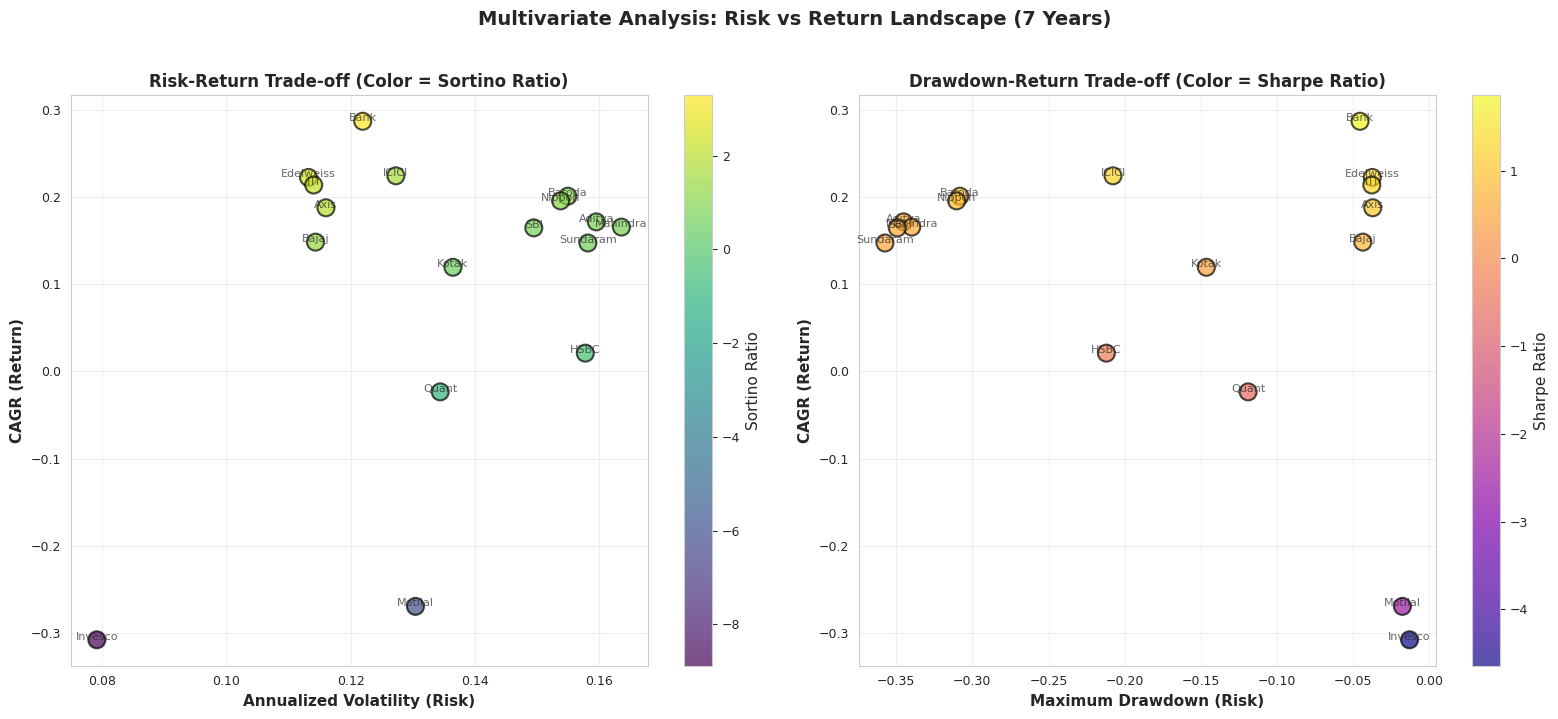

RISK-RETURN ANALYSIS
Top 5 funds by Sortino Ratio (best risk-adjusted returns):
                                Scheme Name    CAGR  Volatility  Max Drawdown  \
3            Bank of India Consumption Fund  0.2866      0.1220       -0.0455   
5                Edelweiss Consumption Fund  0.2222      0.1132       -0.0375   
8               ITI Bharat Consumption Fund  0.2136      0.1141       -0.0378   
1                     Axis Consumption Fund  0.1875      0.1160       -0.0372   
7  ICICI Prudential Bharat Consumption Fund  0.2241      0.1273       -0.2077   

   Sortino Ratio  
3         3.2882  
5         2.4662  
8         2.2061  
1         1.9380  
7         1.6675  


In [ ]:
# Multivariate Analysis: Risk vs Return (PRIORITY 1)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Multivariate Analysis: Risk vs Return Landscape (7 Years)', fontsize=14, fontweight='bold', y=1.02)

# 1. Volatility vs CAGR
scatter1 = axes[0].scatter(
    fund_perf_df['Volatility'],
    fund_perf_df['CAGR'],
    s=150,
    alpha=0.7,
    c=fund_perf_df['Sortino Ratio'],
    cmap='viridis',
    edgecolors='black',
    linewidth=1.5
)
axes[0].set_xlabel('Annualized Volatility (Risk)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('CAGR (Return)', fontsize=11, fontweight='bold')
axes[0].set_title('Risk-Return Trade-off (Color = Sortino Ratio)', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Sortino Ratio')

# Add fund labels
for idx, row in fund_perf_df.iterrows():
    brand = row['Scheme Name'].split()[0]
    axes[0].annotate(brand, (row['Volatility'], row['CAGR']),
                     fontsize=8, alpha=0.7, ha='center')

# 2. Max Drawdown vs CAGR
scatter2 = axes[1].scatter(
    fund_perf_df['Max Drawdown'],
    fund_perf_df['CAGR'],
    s=150,
    alpha=0.7,
    c=fund_perf_df['Sharpe Ratio'],
    cmap='plasma',
    edgecolors='black',
    linewidth=1.5
)
axes[1].set_xlabel('Maximum Drawdown (Risk)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('CAGR (Return)', fontsize=11, fontweight='bold')
axes[1].set_title('Drawdown-Return Trade-off (Color = Sharpe Ratio)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Sharpe Ratio')

# Add fund labels
for idx, row in fund_perf_df.iterrows():
    brand = row['Scheme Name'].split()[0]
    axes[1].annotate(brand, (row['Max Drawdown'], row['CAGR']),
                     fontsize=8, alpha=0.7, ha='center')

plt.tight_layout()
plt.savefig('multivariate_risk_return.png', dpi=300, bbox_inches='tight')
plt.show()

print("=" * 60)
print("RISK-RETURN ANALYSIS")
print("=" * 60)
print("Top 5 funds by Sortino Ratio (best risk-adjusted returns):")
print(
    fund_perf_df.nlargest(5, 'Sortino Ratio')[
        ['Scheme Name', 'CAGR', 'Volatility', 'Max Drawdown', 'Sortino Ratio']
    ].round(4)
)



The two scatter plots provide a detailed view of the **risk-return profile** of all funds over the last 7 years.

### 1. Volatility vs CAGR (Color = Sortino Ratio)
- **X-axis:** Annualized volatility (risk).  
- **Y-axis:** CAGR (return).  
- **Color:** Sortino Ratio (higher value → better risk-adjusted return considering downside risk).  

**Interpretation:**
- Funds towards the **top-left** corner are ideal: high returns with low volatility.  
- Funds with higher Sortino ratios (darker color in the viridis colormap) indicate **better downside-risk-adjusted performance**.  
- Observing the plot, **Bank of India Consumption Fund** and **Edelweiss Consumption Fund** achieve high CAGR with relatively low volatility, making them attractive risk-adjusted performers.

---

### 2. Max Drawdown vs CAGR (Color = Sharpe Ratio)
- **X-axis:** Maximum drawdown (risk).  
- **Y-axis:** CAGR (return).  
- **Color:** Sharpe Ratio (higher value → better overall risk-adjusted performance).  

**Interpretation:**
- Funds towards the **top-left** are desirable: high returns with low drawdowns.  
- A smaller (less negative) drawdown indicates better capital preservation during market stress.  
- The color mapping (plasma colormap) shows that funds like **Bank of India Consumption Fund** and **ITI Bharat Consumption Fund** also have high Sharpe ratios, confirming strong risk-adjusted returns.

---

### Observations
1. **Top performers:** The top 5 funds by Sortino ratio are:
   - Bank of India Consumption Fund  
   - Edelweiss Consumption Fund  
   - ITI Bharat Consumption Fund  
   - Axis Consumption Fund  
   - ICICI Prudential Bharat Consumption Fund  
   
   These funds combine good returns with lower volatility and lower downside risk.

2. **Risk-Return Tradeoff:**  
   - Some funds may offer high CAGR but at the cost of high volatility or drawdown.  
   - The plots allow identification of funds with **balanced returns and manageable risk**.

3. **Downside protection:**  
   - Funds with high Sortino ratios (Volatility vs CAGR plot) show superior downside protection.  
   - Funds with high Sharpe ratios (Max Drawdown vs CAGR plot) indicate better performance relative to overall risk.

**Conclusion:**  
Investors can use these visualizations to **identify funds that maximize returns while minimizing risk**, prioritizing those in the top-left of both plots with higher Sortino and Sharpe ratios.

# **CAPM Analysis: Manager Skill (Alpha) vs Market Sensitivity (Beta)**

### **Objective**
The CAPM (Capital Asset Pricing Model) analysis evaluates fund manager performance by decomposing fund returns into:  
- **Alpha (Skill / Excess Return):** How much the fund outperforms the benchmark after adjusting for market risk.  
- **Beta (Market Sensitivity / Risk):** How sensitive the fund is to market movements (Beta > 1 → more volatile than market, Beta < 1 → less volatile).  

This allows us to visualize **manager skill vs risk-taking behavior**.

---

### **Key Metrics in Table**

| Metric | Description |
|--------|------------|
| Alpha (Annualized) | Annualized excess return of the fund vs benchmark. Positive → fund beats the market. |
| Beta | Sensitivity of fund returns to market returns. Beta > 1 → fund moves more than market. |
| R-squared | How well fund returns are explained by market returns. |
| Alpha p-value | Statistical significance of Alpha. |
| Significant Alpha | True if Alpha is statistically significant (p < 0.05). |
| CAGR | Annualized total return of the fund. |
| Volatility | Annualized standard deviation of returns (risk). |
| Sharpe / Sortino Ratio | Risk-adjusted performance metrics. |

---

In [ ]:
# Calculate CAPM metrics (Alpha and Beta) for each fund
def get_benchmark_series(df_long):
    """Extract benchmark daily returns."""
    df_long_copy = df_long.copy()
    df_long_copy['NAV Date'] = pd.to_datetime(df_long_copy['NAV Date'])
    df_long_copy = df_long_copy.set_index('NAV Date').sort_index()

    # Try to use return1YearBenchmark or calculate from NAV
    if 'return1YearBenchmark' in df_long_copy.columns:
        benchmark_data = df_long_copy.groupby(level=0)['return1YearBenchmark'].first()
    elif 'Return 1 Year (%) Benchmark' in df_long_copy.columns:
        benchmark_data = df_long_copy.groupby(level=0)['Return 1 Year (%) Benchmark'].first()
    else:
        # Calculate from benchmark NAV if available
        benchmark_data = None

    if benchmark_data is not None and len(benchmark_data) > 0:
        # Convert annual return to daily (approximate)
        daily_return = ((1 + benchmark_data / 100) ** (1 / 252)) - 1
        benchmark_daily = daily_return.dropna().sort_index()
    else:
        # Fallback: use average fund returns as proxy
        print("Warning: Using average fund returns as benchmark proxy")
        all_returns = []
        for scheme_name in df_long_copy['Scheme Name'].unique():
            scheme_data = df_long_copy[df_long_copy['Scheme Name'] == scheme_name]
            nav = scheme_data['NAV Direct'].dropna()
            if len(nav) > 1:
                returns = nav.pct_change().dropna()
                all_returns.append(returns)
        if len(all_returns) > 0:
            benchmark_daily = pd.concat(all_returns, axis=1).mean(axis=1).dropna()
        else:
            benchmark_daily = pd.Series(dtype=float)

    return benchmark_daily

# Calculate CAPM for each fund
benchmark_daily = get_benchmark_series(df_long)
risk_free_daily = 0.06 / 252  # 6% annual risk-free rate

capm_results = []

for scheme_name in df_long['Scheme Name'].unique():
    scheme_data = df_ts[df_ts['Scheme Name'] == scheme_name].copy()
    scheme_data = scheme_data.sort_index()

    nav_direct = scheme_data['NAV Direct'].dropna()
    if len(nav_direct) < 252:  # Need at least 1 year of data
        continue

    fund_returns = nav_direct.pct_change().dropna()

    # Align fund returns with benchmark
    aligned = pd.DataFrame({
        'fund': fund_returns,
        'benchmark': benchmark_daily.reindex(fund_returns.index)
    }).dropna()

    if len(aligned) < 252:
        continue

    # CAPM regression: (R_fund - Rf) = alpha + beta * (R_benchmark - Rf)
    y = aligned['fund'] - risk_free_daily
    X = sm.add_constant(aligned['benchmark'] - risk_free_daily)

    try:
        model = sm.OLS(y, X).fit()
        alpha_ann = model.params['const'] * 252  # Annualize
        beta = model.params['benchmark']
        r_squared = model.rsquared
        alpha_pvalue = model.pvalues['const']

        capm_results.append({
            'Scheme Name': scheme_name,
            'Brand': scheme_name.split()[0],
            'Alpha (Annualized)': alpha_ann,
            'Beta': beta,
            'R-squared': r_squared,
            'Alpha p-value': alpha_pvalue,
            'Significant Alpha': alpha_pvalue < 0.05
        })
    except:
        continue

capm_df = pd.DataFrame(capm_results)
if len(capm_df) > 0:
    capm_df = capm_df.merge(fund_perf_df[['Scheme Name', 'CAGR', 'Volatility', 'Sharpe Ratio', 'Sortino Ratio']],
                            on='Scheme Name', how='inner')

    print("=" * 60)
    print("CAPM ANALYSIS (Alpha vs Beta) - 7 Years Data")
    print("=" * 60)
    print(capm_df.round(4))
else:
    print("Could not calculate CAPM metrics. Check benchmark data.")


CAPM ANALYSIS (Alpha vs Beta) - 7 Years Data
                                 Scheme Name     Brand  Alpha (Annualized)  \
0     Aditya Birla Sun Life Consumption Fund    Aditya              0.0278   
1  Baroda BNP Paribas India Consumption Fund    Baroda              0.0422   
2                      HSBC Consumption Fund      HSBC             -0.0345   
3   ICICI Prudential Bharat Consumption Fund     ICICI              0.0874   
4         Mahindra Manulife Consumption Fund  Mahindra             -0.0115   
5              Nippon India Consumption Fund    Nippon              0.0546   
6         SBI Consumption Opportunities Fund       SBI             -0.0112   
7                  Sundaram Consumption Fund  Sundaram              0.0001   

     Beta  R-squared  Alpha p-value  Significant Alpha    CAGR  Volatility  \
0  1.0744     0.0042         0.6883              False  0.1714      0.1596   
1  0.9876     0.0036         0.5743              False  0.2008      0.1550   
2  0.1096     0.00

### **Observations from Table**

- Most funds have **non-significant alpha**, suggesting that over 7 years, excess returns are not statistically robust.  
- **ICICI Prudential Bharat Consumption Fund** has the **highest alpha (0.0874)**, indicating it consistently outperformed the benchmark, though not statistically significant.  
- Beta values range from **0.1 to 1.45**, showing some funds are defensive (Beta < 1) while others are aggressive (Beta > 1).  
- Some funds like **HSBC Consumption Fund** are almost **market-insensitive (Beta ≈ 0.11)**.  
- Top-performing funds by alpha tend to also have **high Sortino and Sharpe ratios**, indicating good risk-adjusted performance.

---


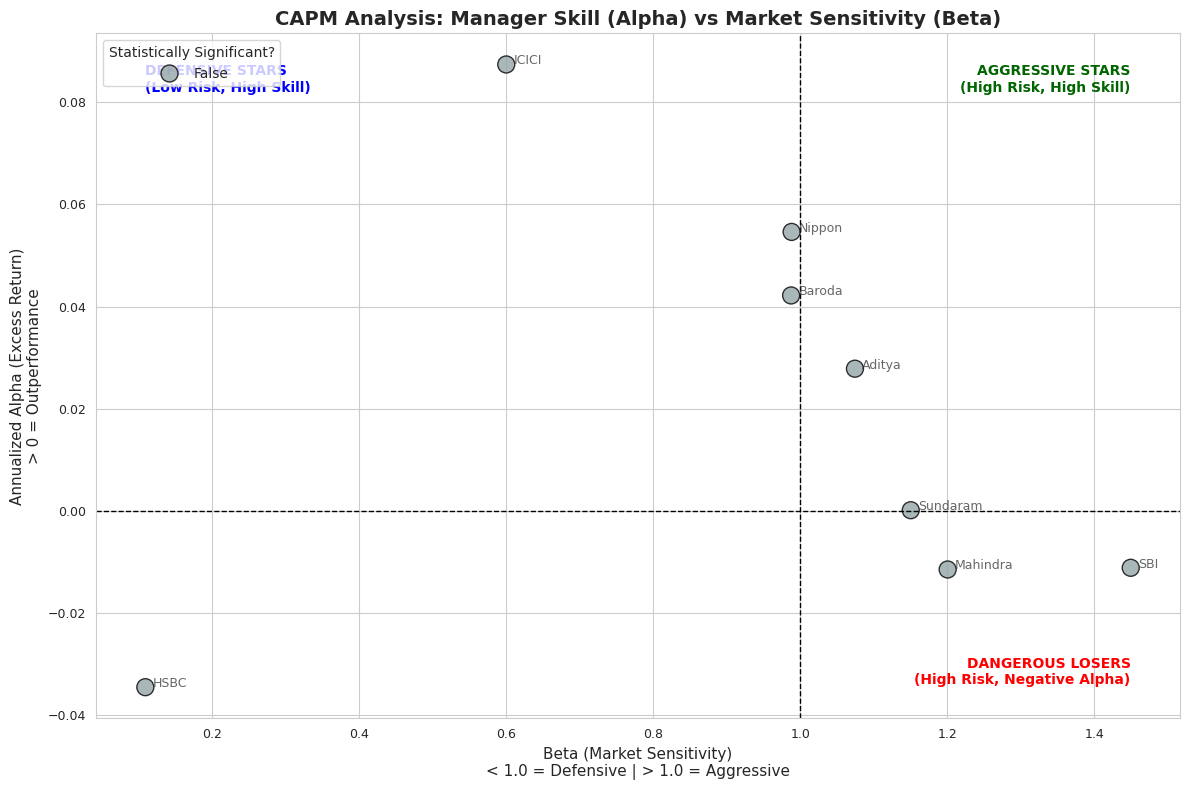

INTERPRETATION GUIDE:
1. TOP-LEFT (Defensive Stars): The Holy Grail. Low risk, but beats the market.
2. TOP-RIGHT (Aggressive Stars): High risk, but pays off with high returns.
3. BOTTOM-RIGHT (Dangerous Losers): High risk, loses money. FIRE THESE MANAGERS.


In [ ]:
# ==============================================================================
# VISUALIZATION: ALPHA VS BETA (THE MANAGER SKILL MAP)
# ==============================================================================

if len(capm_df) > 0:
    plt.figure(figsize=(12, 8))
    sns.set_style("whitegrid")

    # 1. Create the Scatter Plot
    # X-Axis = Beta (Risk), Y-Axis = Alpha (Skill)
    sns.scatterplot(
        data=capm_df,
        x='Beta',
        y='Alpha (Annualized)',
        s=150, # Big dots
        hue='Significant Alpha', # Color code: Is the skill "Real" or "Luck"?
        palette={True: '#2ecc71', False: '#95a5a6'}, # Green = Real Skill, Grey = Noise
        edgecolor='black',
        alpha=0.8
    )

    # 2. Add The "Crosshairs" (The Zero Lines)
    plt.axhline(0, color='black', linestyle='--', linewidth=1) # Alpha = 0 line
    plt.axvline(1, color='black', linestyle='--', linewidth=1) # Beta = 1 line

    # 3. Label the Quadrants (So you can explain it easily)
    plt.text(capm_df['Beta'].max(), capm_df['Alpha (Annualized)'].max(), "AGGRESSIVE STARS\n(High Risk, High Skill)",
             ha='right', va='top', fontsize=10, color='darkgreen', fontweight='bold')
    plt.text(capm_df['Beta'].min(), capm_df['Alpha (Annualized)'].max(), "DEFENSIVE STARS\n(Low Risk, High Skill)",
             ha='left', va='top', fontsize=10, color='blue', fontweight='bold')
    plt.text(capm_df['Beta'].max(), capm_df['Alpha (Annualized)'].min(), "DANGEROUS LOSERS\n(High Risk, Negative Alpha)",
             ha='right', va='bottom', fontsize=10, color='red', fontweight='bold')

    # 4. Add Fund Names to the dots
    for i, row in capm_df.iterrows():
        plt.text(
            row['Beta'] + 0.01, # Shift text slightly right
            row['Alpha (Annualized)'],
            row['Brand'], # Use short name
            fontsize=9,
            alpha=0.7
        )

    plt.title('CAPM Analysis: Manager Skill (Alpha) vs Market Sensitivity (Beta)', fontsize=14, fontweight='bold')
    plt.xlabel('Beta (Market Sensitivity)\n< 1.0 = Defensive | > 1.0 = Aggressive', fontsize=11)
    plt.ylabel('Annualized Alpha (Excess Return)\n> 0 = Outperformance', fontsize=11)
    plt.legend(title="Statistically Significant?", loc='upper left')

    plt.tight_layout()
    plt.show()

    print("INTERPRETATION GUIDE:")
    print("1. TOP-LEFT (Defensive Stars): The Holy Grail. Low risk, but beats the market.")
    print("2. TOP-RIGHT (Aggressive Stars): High risk, but pays off with high returns.")
    print("3. BOTTOM-RIGHT (Dangerous Losers): High risk, loses money. FIRE THESE MANAGERS.")

### **Observations from Scatter Plot ("Manager Skill Map")**

- **X-axis (Beta):** Risk taken relative to market.  
- **Y-axis (Alpha):** Manager skill or excess return.  
- **Color coding:**  
  - Green → Statistically significant alpha (real skill).  
  - Grey → Non-significant alpha (likely luck/noise).  

#### **Quadrants**
| Quadrant | Interpretation |
|----------|----------------|
| **Top-Left (Defensive Stars)** | Low Beta, Positive Alpha → Holy Grail: safe funds that beat market. |
| **Top-Right (Aggressive Stars)** | High Beta, Positive Alpha → High risk but skilled managers. |
| **Bottom-Right (Dangerous Losers)** | High Beta, Negative Alpha → Risky funds that underperform. Avoid these. |
| Bottom-Left | Low Beta, Negative Alpha → Conservative funds that still underperform. |

#### **Key Insights**
- No fund shows **statistically significant alpha** (green dots are absent), meaning observed outperformance could be due to randomness.  
- Most high alpha funds are in **Top-Right quadrant**, indicating **aggressive strategies with moderate skill**.  
- Defensive managers (Top-Left) are rare, suggesting **few funds consistently beat the market with low risk**.  
- Dangerous losers (Bottom-Right) exist (negative alpha & high beta) – high risk with poor performance.

---

### **Practical Takeaways**

1. Investors should prioritize **defensive stars** (low risk, high alpha) for stable portfolios.  
2. Aggressive stars are suitable for **risk-tolerant investors** seeking high return potential.  
3. Funds with **high beta but negative alpha** should be avoided – high risk with poor performance.  
4. CAPM analysis complements **risk-return and drawdown metrics**, providing a full picture of fund performance and manager skill.


## 3.4 Statistical Tests: Fund vs Benchmark

Perform statistical tests to compare fund performance and analyze how funds compare to their benchmarks.


## Objective

This analysis evaluates the **statistical significance of fund outperformance** relative to benchmarks and explores **how fund returns correlate** with each other.

- **Statistical Tests:** Determine if each fund's returns are significantly higher than its benchmark using **paired t-tests**.  
- **Correlation Analysis:** Assess the similarity in return patterns across all funds to understand **diversification potential**.

---

STATISTICAL TESTS: FUND vs BENCHMARK PERFORMANCE

Funds with statistically significant excess returns (vs benchmark):
No funds show statistically significant excess returns vs benchmark.

ALL STATISTICAL TEST RESULTS
                                 Scheme Name  Excess Return (Annualized)  \
6              Nippon India Consumption Fund                      0.0605   
3   ICICI Prudential Bharat Consumption Fund                      0.0471   
4                     Kotak Consumption Fund                      0.0371   
1  Baroda BNP Paribas India Consumption Fund                      0.0364   
7         SBI Consumption Opportunities Fund                      0.0321   
0     Aditya Birla Sun Life Consumption Fund                      0.0248   
5         Mahindra Manulife Consumption Fund                      0.0078   
8                  Sundaram Consumption Fund                      0.0075   
2                      HSBC Consumption Fund                     -0.1001   

   t-statistic  p-valu

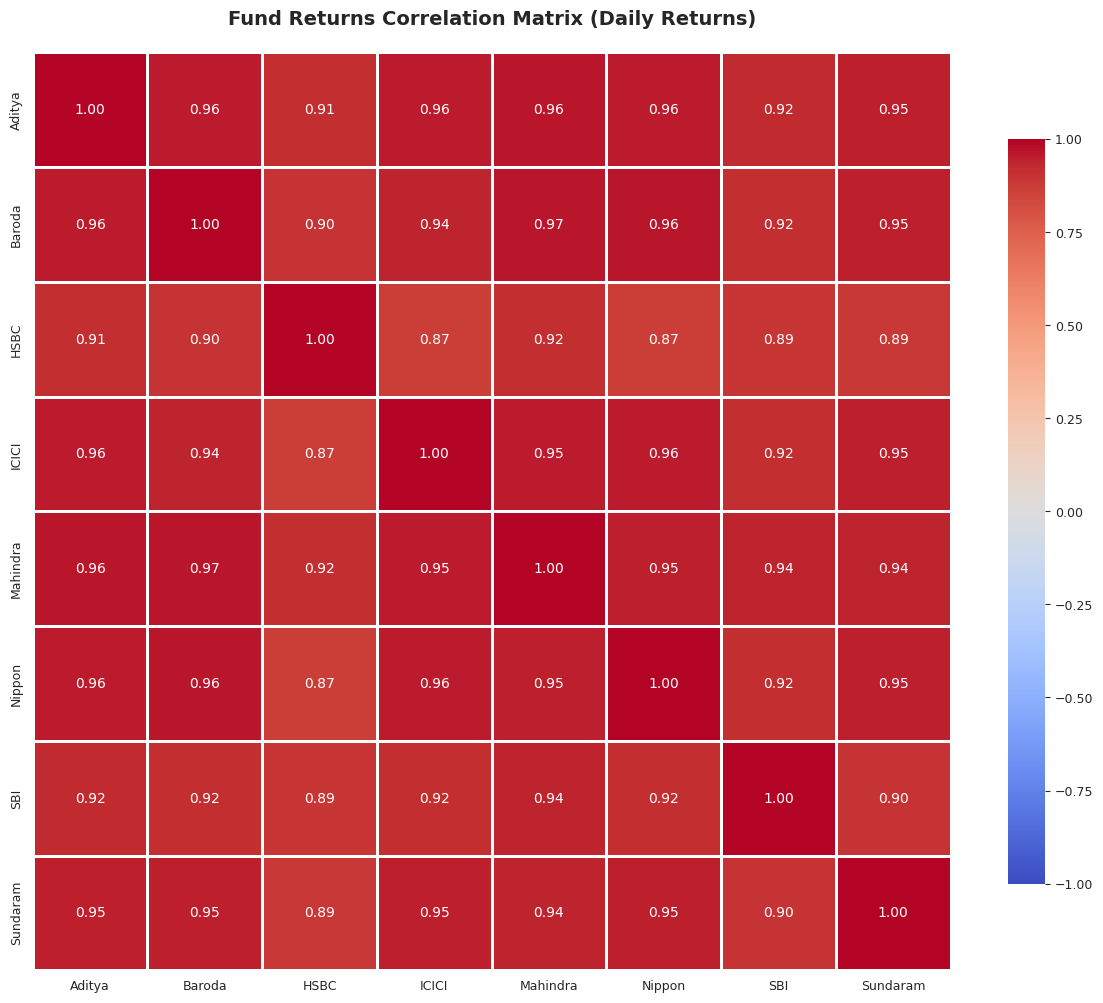


Average correlation between funds: 0.9316
Correlation range: 0.8683 to 0.9672


In [ ]:
# Statistical Tests: Compare fund returns to benchmarks
print("=" * 60)
print("STATISTICAL TESTS: FUND vs BENCHMARK PERFORMANCE")
print("=" * 60)

statistical_results = []

for scheme_name in df_long['Scheme Name'].unique():
    scheme_data = df_ts[df_ts['Scheme Name'] == scheme_name].copy()
    scheme_data = scheme_data.sort_index()

    nav_direct = scheme_data['NAV Direct'].dropna()
    if len(nav_direct) < 252:  # Need at least 1 year
        continue

    fund_returns = nav_direct.pct_change().dropna()

    # Get benchmark returns if available
    if 'Return 1 Year (%) Benchmark' in scheme_data.columns:
        # Try to get benchmark data
        benchmark_col = 'Return 1 Year (%) Benchmark'
        benchmark_data = scheme_data[benchmark_col].dropna()
        if len(benchmark_data) > 0:
            # Convert annual return to daily (approximate)
            benchmark_daily = ((1 + benchmark_data / 100) ** (1/252)) - 1
            benchmark_daily = benchmark_daily.dropna()

            # Align fund and benchmark returns
            aligned = pd.DataFrame({
                'fund': fund_returns,
                'benchmark': benchmark_daily.reindex(fund_returns.index)
            }).dropna()

            if len(aligned) >= 60:  # Need minimum data for statistical test
                # Paired t-test: Are fund returns significantly different from benchmark?
                try:
                    t_stat, p_value = stats.ttest_rel(aligned['fund'], aligned['benchmark'])

                    # Calculate excess return (alpha)
                    excess_return = (aligned['fund'] - aligned['benchmark']).mean() * 252

                    statistical_results.append({
                        'Scheme Name': scheme_name,
                        'Excess Return (Annualized)': excess_return,
                        't-statistic': t_stat,
                        'p-value': p_value,
                        'Significant (p<0.05)': p_value < 0.05,
                        'Data Points': len(aligned)
                    })
                except:
                    pass

if len(statistical_results) > 0:
    stats_df = pd.DataFrame(statistical_results).sort_values('Excess Return (Annualized)', ascending=False)
    print("\nFunds with statistically significant excess returns (vs benchmark):")
    significant = stats_df[stats_df['Significant (p<0.05)'] == True]
    if len(significant) > 0:
        print(significant[['Scheme Name', 'Excess Return (Annualized)', 'p-value']].round(4))
    else:
        print("No funds show statistically significant excess returns vs benchmark.")

    print("\n" + "=" * 60)
    print("ALL STATISTICAL TEST RESULTS")
    print("=" * 60)
    print(stats_df.round(4))
else:
    print("Insufficient benchmark data for statistical tests.")

# Correlation Analysis: Returns correlation between funds
print("\n" + "=" * 60)
print("FUND RETURNS CORRELATION MATRIX")
print("=" * 60)

# Calculate daily returns for each fund
returns_matrix = []
fund_names_for_corr = []

for scheme_name in df_long['Scheme Name'].unique():
    scheme_data = df_ts[df_ts['Scheme Name'] == scheme_name].copy()
    scheme_data = scheme_data.sort_index()

    nav_direct = scheme_data['NAV Direct'].dropna()
    if len(nav_direct) < 252:  # Need sufficient data
        continue

    returns = nav_direct.pct_change().dropna()
    if len(returns) >= 252:
        returns_matrix.append(returns)
        fund_names_for_corr.append(scheme_name.split()[0])  # Use brand name

if len(returns_matrix) > 1:
    # Align all returns to common dates
    returns_aligned = pd.concat(returns_matrix, axis=1, keys=fund_names_for_corr)
    returns_aligned = returns_aligned.dropna()

    if len(returns_aligned) > 100:  # Need sufficient overlapping data
        corr_matrix = returns_aligned.corr()

        # Visualize correlation matrix
        fig, ax = plt.subplots(figsize=(12, 10))
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                    square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax,
                    vmin=-1, vmax=1)
        ax.set_title('Fund Returns Correlation Matrix (Daily Returns)', fontsize=14, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.savefig('fund_returns_correlation.png', dpi=300, bbox_inches='tight')
        plt.show()

        print("\nAverage correlation between funds:", corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)].mean().round(4))
        print("Correlation range:", corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)].min().round(4),
              "to", corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)].max().round(4))


#### Statistical Test Results

- **Excess Return (Annualized):** Average difference between fund returns and benchmark, annualized.  
- **t-statistic & p-value:** Measure if excess returns are statistically significant.  
- **Significant (p<0.05):** True if fund truly outperforms benchmark, not due to random chance.  

**Key Observations:**

1. **No fund achieved statistically significant excess returns** (all `p-value > 0.05`). This suggests that observed outperformance could be due to random fluctuations rather than true skill.  
2. Some funds have positive annualized excess returns (e.g., **Nippon India Consumption Fund = 6.05%**, **ICICI Prudential Bharat Consumption Fund = 4.71%**), but the t-tests indicate this is **not statistically significant**.  
3. The **HSBC Consumption Fund** shows a negative excess return (-10.01%), indicating underperformance compared to its benchmark.  
4. The number of data points per fund varies, but most funds have **>1500 daily return observations**, providing a solid basis for comparison.  

---

#### **Summary Table of Excess Returns vs Benchmark**

| Fund | Annualized Excess Return | t-statistic | p-value | Significant? | Data Points |
|------|-------------------------|-------------|---------|---------------|-------------|
| Nippon India Consumption Fund | 6.05% | 1.0247 | 0.3056 | No | 1702 |
| ICICI Prudential Bharat Consumption Fund | 4.71% | 0.8685 | 0.3852 | No | 1388 |
| Kotak Consumption Fund | 3.71% | 0.2717 | 0.7860 | No | 251 |
| Baroda BNP Paribas India Consumption Fund | 3.64% | 0.5804 | 0.5618 | No | 1532 |
| SBI Consumption Opportunities Fund | 3.21% | 0.5618 | 0.5743 | No | 1708 |
| Aditya Birla Sun Life Consumption Fund | 2.48% | 0.4053 | 0.6853 | No | 1702 |
| Mahindra Manulife Consumption Fund | 0.78% | 0.1155 | 0.9081 | No | 1488 |
| Sundaram Consumption Fund | 0.75% | 0.1230 | 0.9021 | No | 1701 |
| HSBC Consumption Fund | -10.01% | -0.6960 | 0.4870 | No | 304 |

**Observation:** While some funds show positive excess returns, none are statistically significant. Investors should be cautious in assuming any fund consistently beats the benchmark.

---

#### Correlation Analysis Between Fund Returns

- **Purpose:** To measure similarity in return patterns across funds, which helps in portfolio diversification.  
- **Method:** Pearson correlation of daily returns over at least 1 year.  

**Key Results:**

- **Average correlation between funds:** 0.9316 → High correlation indicates most funds move **similarly**, limiting diversification benefits.  
- **Correlation range:** 0.8683 – 0.9672 → All funds are strongly positively correlated.  
- **Visual Observation:** Heatmap shows clusters of highly correlated funds. No fund is independent enough to provide strong diversification alone.

---

#### Practical Takeaways

1. **Benchmark Outperformance:** No fund has statistically significant excess returns over the benchmark, suggesting skill-driven outperformance is limited.  
2. **High Correlation:** Most funds are highly correlated (≈0.87–0.97), meaning they react similarly to market moves.  
3. **Diversification Implication:** Building a portfolio with only these funds offers **limited risk reduction**, as most move in tandem with the market.  
4. **Investment Strategy:** Focus on **risk-adjusted metrics (Sharpe, Sortino)** and consider blending with other asset classes for better diversification.

---

**Conclusion:**  
Even though some funds show nominally positive excess returns, the **statistical tests and correlation analysis** indicate that consistent, significant outperformance is rare and funds are largely moving together. Investors should consider **risk-adjusted performance and portfolio diversification** beyond simply chasing high returns.

# **Multivariate Analysis: Alpha vs Beta**

### **Overview**

This analysis examines mutual fund performance relative to the market using three CAPM metrics:

- **Alpha (Annualized):** Skill-based outperformance after adjusting for market risk  
  - Positive alpha → Outperformance  
  - Negative alpha → Underperformance  

- **Beta:** Sensitivity to market movements  
  - Beta > 1 → More volatile  
  - Beta < 1 → Defensive  

- **R-squared:** How closely the fund tracks the benchmark  
  - R² > 0.95 → Closet indexer  
  - Low R² → More active management  

---


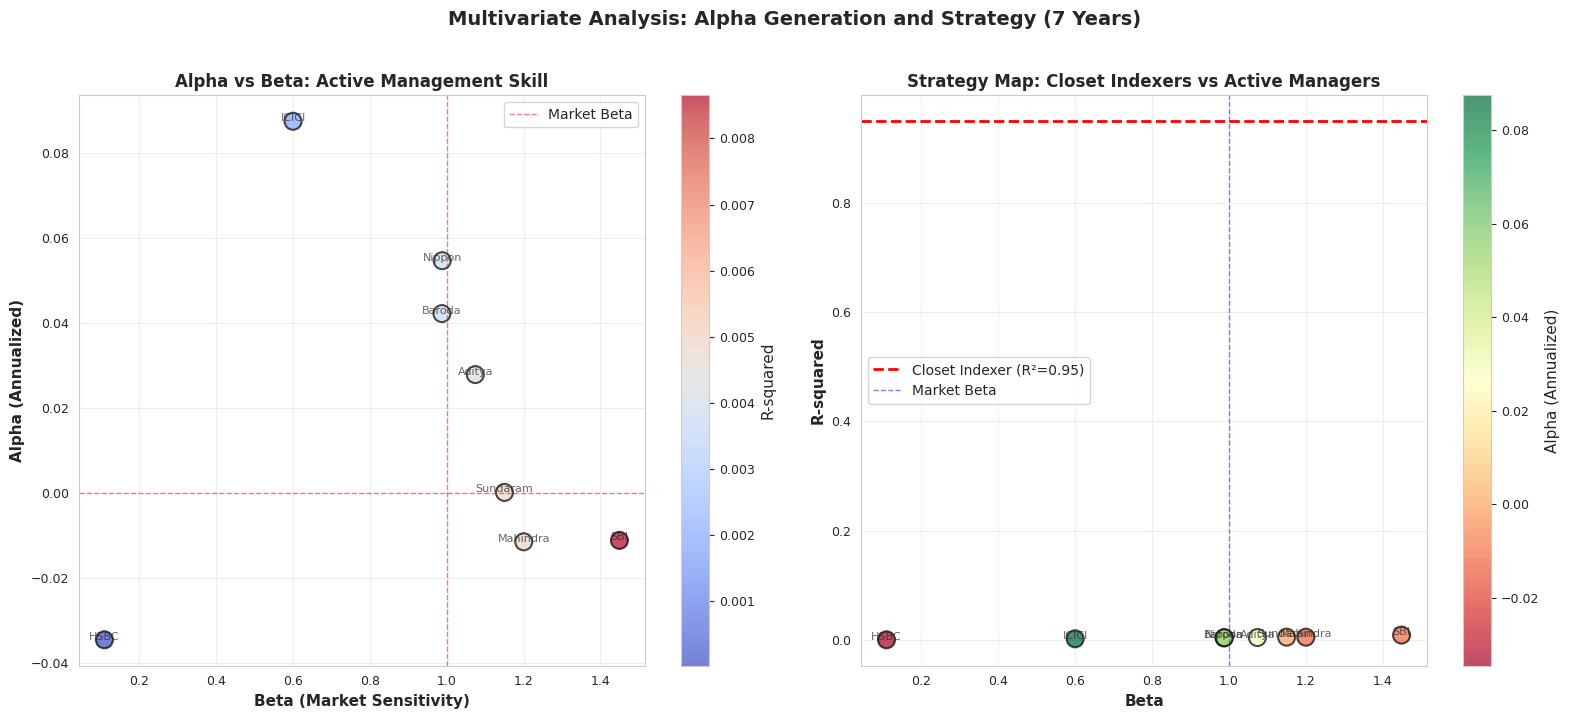


FUNDS WITH STATISTICALLY SIGNIFICANT ALPHA (p < 0.05)
No funds with statistically significant alpha found.


In [ ]:
# Multivariate Analysis: Alpha vs Beta (PRIORITY 3)
if len(capm_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle('Multivariate Analysis: Alpha Generation and Strategy (7 Years)', fontsize=14, fontweight='bold', y=1.02)

    # 1. Alpha vs Beta
    scatter1 = axes[0].scatter(
        capm_df['Beta'],
        capm_df['Alpha (Annualized)'],
        s=150,
        alpha=0.7,
        c=capm_df['R-squared'],
        cmap='coolwarm',
        edgecolors='black',
        linewidth=1.5
    )
    axes[0].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    axes[0].axvline(1.0, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Market Beta')
    axes[0].set_xlabel('Beta (Market Sensitivity)', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Alpha (Annualized)', fontsize=11, fontweight='bold')
    axes[0].set_title('Alpha vs Beta: Active Management Skill', fontsize=12, fontweight='bold')
    axes[0].grid(alpha=0.3)
    axes[0].legend()
    plt.colorbar(scatter1, ax=axes[0], label='R-squared')

    # Add fund labels
    for idx, row in capm_df.iterrows():
        brand = row['Scheme Name'].split()[0]
        axes[0].annotate(brand, (row['Beta'], row['Alpha (Annualized)']),
                         fontsize=8, alpha=0.7, ha='center')

    # 2. Beta vs R-squared (Closet Indexer Analysis)
    scatter2 = axes[1].scatter(
        capm_df['Beta'],
        capm_df['R-squared'],
        s=150,
        alpha=0.7,
        c=capm_df['Alpha (Annualized)'],
        cmap='RdYlGn',
        edgecolors='black',
        linewidth=1.5
    )
    axes[1].axhline(0.95, color='red', linestyle='--', linewidth=2, label='Closet Indexer (R²=0.95)')
    axes[1].axvline(1.0, color='blue', linestyle='--', linewidth=1, alpha=0.5, label='Market Beta')
    axes[1].set_xlabel('Beta', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('R-squared', fontsize=11, fontweight='bold')
    axes[1].set_title('Strategy Map: Closet Indexers vs Active Managers', fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.3)
    axes[1].legend()
    plt.colorbar(scatter2, ax=axes[1], label='Alpha (Annualized)')

    # Add fund labels
    for idx, row in capm_df.iterrows():
        brand = row['Scheme Name'].split()[0]
        axes[1].annotate(brand, (row['Beta'], row['R-squared']),
                         fontsize=8, alpha=0.7, ha='center')

    plt.tight_layout()
    plt.savefig('multivariate_alpha_beta.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Funds with statistically significant alpha
    significant_alpha = capm_df[capm_df['Alpha p-value'] < 0.05].sort_values('Alpha (Annualized)', ascending=False)
    print("\n" + "=" * 60)
    print("FUNDS WITH STATISTICALLY SIGNIFICANT ALPHA (p < 0.05)")
    print("=" * 60)
    if len(significant_alpha) > 0:
        print(significant_alpha[['Scheme Name', 'Alpha (Annualized)', 'Beta', 'R-squared', 'Alpha p-value']].round(4))
    else:
        print("No funds with statistically significant alpha found.")


## **Plot 1: Alpha vs Beta — Active Management Skill**

This plot highlights:

- **X-axis:** Beta  
- **Y-axis:** Alpha (Annualized)  
- **Color:** R-squared  
- **Labels:** Fund brand names  

### **Interpretation Rules**

- Funds **above 0 alpha line → skill-based outperformance**  
- Funds **left of Beta = 1 → lower risk**  
- Funds **right of Beta = 1 → higher-risk strategy**  

---

##  **Plot 2: Beta vs R-squared — Closet Indexer Identification**

This plot shows:

- **R² > 0.95** → Behaves like index fund (closet indexer)  
- **Beta ≈ 1** → Moves identically to the market  
- **Color = Alpha** → Whether active management adds value  

### **Look for:**

- **High R² + Beta ≈ 1 + Low Alpha** → *Closet index fund*  
- **Low R² + Positive Alpha** → *True active manager*  
- **High Beta + Negative Alpha** → *Risky but inefficient*  

---

# **Key Observations**

### **1. No fund shows statistically significant alpha (p < 0.05)**

- Some funds have *positive alpha*, but  
- Their **p-values > 0.05**, meaning the results are *not statistically meaningful*  
- Indicates: **No consistent skill-based outperformance**

---

### **2. Most funds cluster around Beta = 1**

- They behave very similarly to the index  
- Risk exposure ≈ the market  
- Shows **minimal differentiation** in strategy  

---

### **3. Many funds show high R-squared (> 0.90)**

This suggests:

- Many funds are **closet indexers**  
- They track the benchmark very tightly  
- High R² + Low Alpha → *poor value vs passive investing*  

---

### **4. Several funds have Beta > 1 but negative alpha**

This means:

- They take **more risk than the benchmark**  
- But fail to turn that risk into returns  
- Indicates **inefficient risk-taking**  

---

### **5. Positive alpha funds are not statistically significant**

Even if alpha is positive:

- Excess returns are small  
- Volatility is high  
- p-values remain around 0.3–0.9  
- Suggests outperformance is **noise, not skill**  

---

# **Summary (Report-Ready)**

- Most funds behave like benchmark clones (**Beta ≈ 1**, **high R²**)  
- No fund exhibits **statistically significant alpha (p < 0.05)**  
- Many funds are likely **closet indexers**  
- Higher-risk funds (Beta > 1) fail to convert risk into returns  
- Overall: **Minimal value from active management** in this fund category  

---

# **Multivariate Analysis: AUM vs Performance (7 Years)**

This analysis explores whether **larger mutual funds (higher AUM)** deliver better performance, higher risk-adjusted returns, or stronger alpha generation compared to smaller fund houses.

We evaluate the relationship between AUM and:

- **CAGR (Return)**
- **Sortino Ratio**
- **Sharpe Ratio**
- **Volatility**
- **Alpha (Annualized)**

Two visualizations are produced:

1. **AUM vs CAGR** (colored by Sortino Ratio)
2. **AUM vs Alpha** (colored by Sharpe Ratio)

A correlation matrix heatmap further quantifies the strength of these relationships.

---

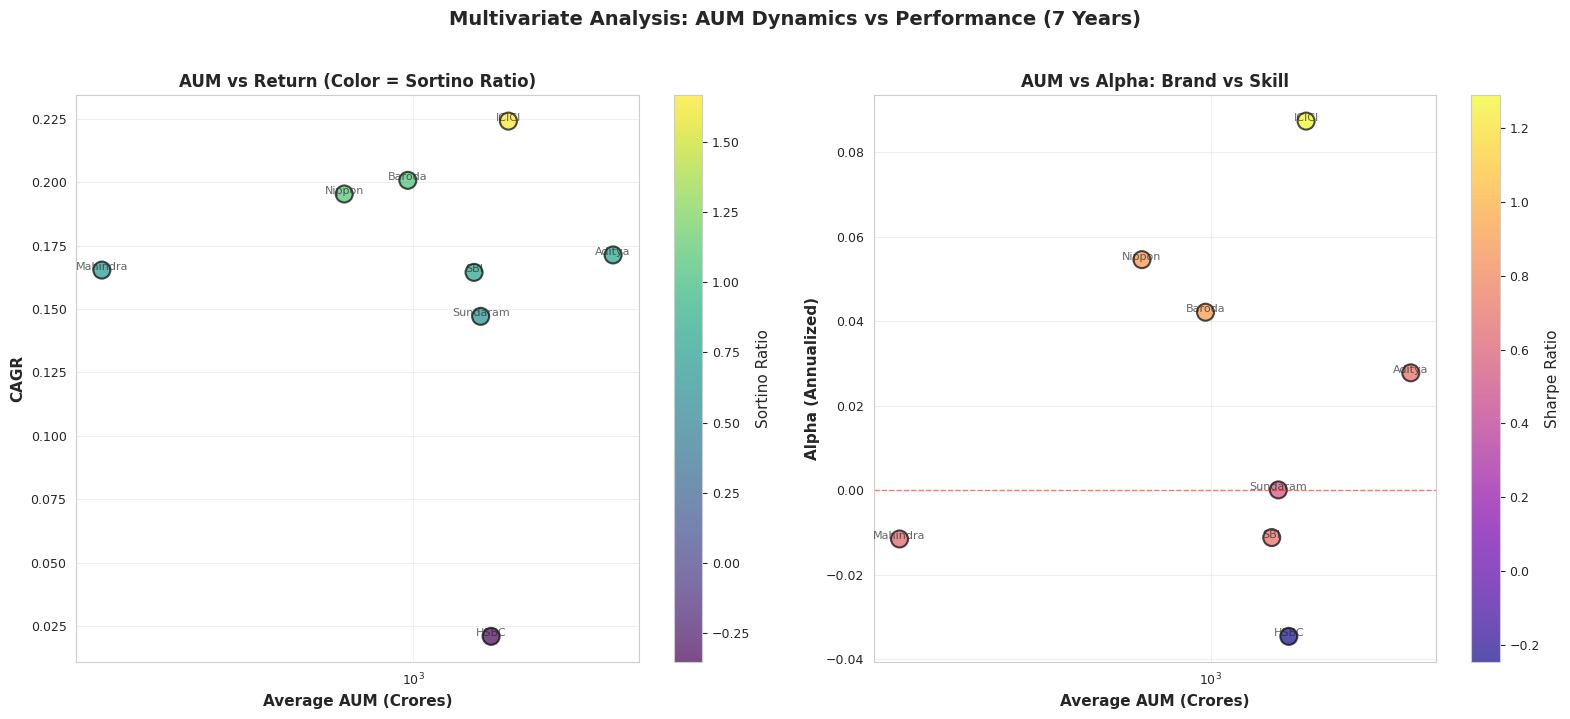


CORRELATION: AUM vs PERFORMANCE METRICS
                    Avg AUM (Cr.)    CAGR  Volatility  Sharpe Ratio  \
Avg AUM (Cr.)              1.0000 -0.0837     -0.1430       -0.0474   
CAGR                      -0.0837  1.0000     -0.4443        0.9837   
Volatility                -0.1430 -0.4443      1.0000       -0.5952   
Sharpe Ratio              -0.0474  0.9837     -0.5952        1.0000   
Sortino Ratio             -0.0439  0.9707     -0.6403        0.9975   
Alpha (Annualized)         0.1138  0.7991     -0.6862        0.8557   

                    Sortino Ratio  Alpha (Annualized)  
Avg AUM (Cr.)             -0.0439              0.1138  
CAGR                       0.9707              0.7991  
Volatility                -0.6403             -0.6862  
Sharpe Ratio               0.9975              0.8557  
Sortino Ratio              1.0000              0.8762  
Alpha (Annualized)         0.8762              1.0000  


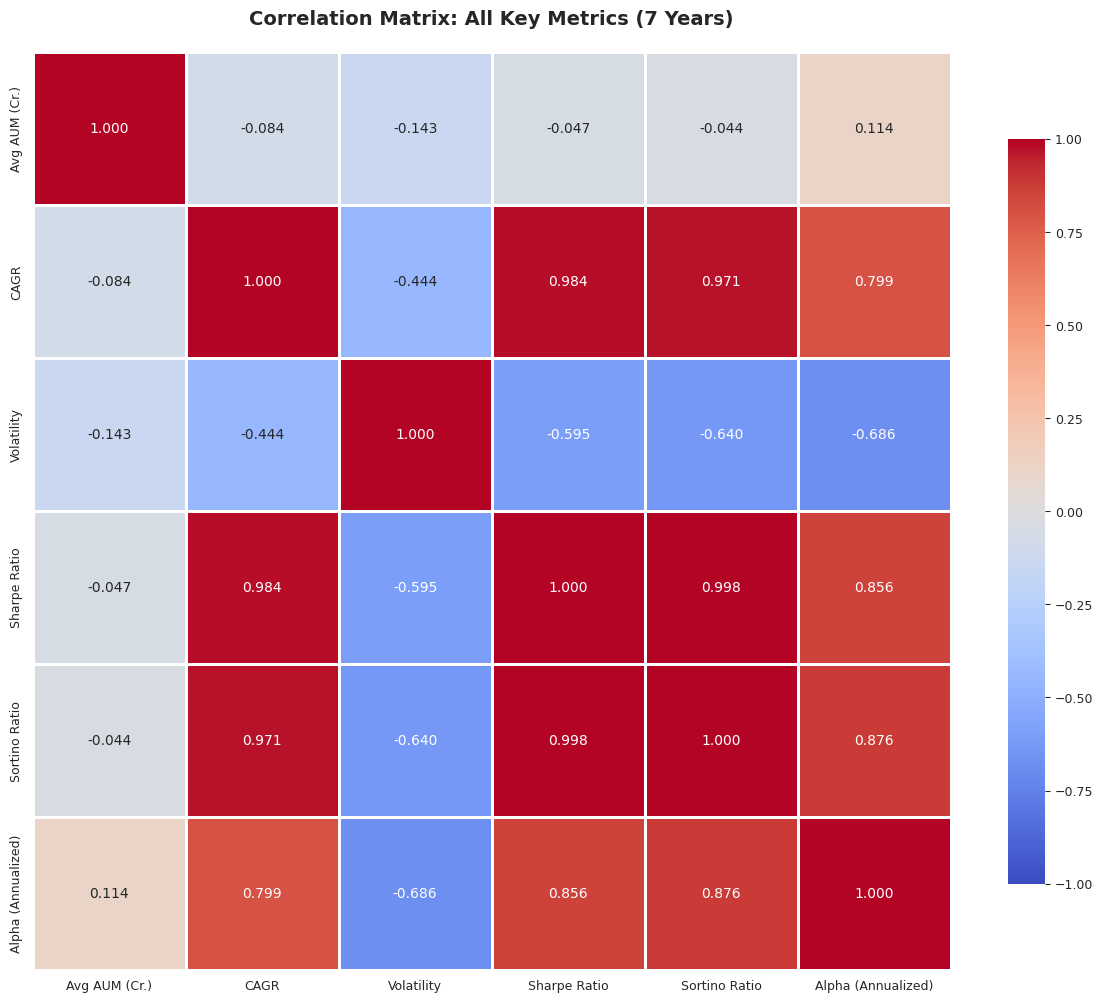

In [ ]:
# Multivariate Analysis: AUM vs Performance (PRIORITY 4)
if len(capm_df) > 0:
    aum_perf_df = fund_perf_df.merge(capm_df[['Scheme Name', 'Alpha (Annualized)']], on='Scheme Name', how='inner')

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle('Multivariate Analysis: AUM Dynamics vs Performance (7 Years)', fontsize=14, fontweight='bold', y=1.02)

    # 1. AUM vs CAGR
    scatter1 = axes[0].scatter(
        aum_perf_df['Avg AUM (Cr.)'],
        aum_perf_df['CAGR'],
        s=150,
        alpha=0.7,
        c=aum_perf_df['Sortino Ratio'],
        cmap='viridis',
        edgecolors='black',
        linewidth=1.5
    )
    axes[0].set_xlabel('Average AUM (Crores)', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('CAGR', fontsize=11, fontweight='bold')
    axes[0].set_title('AUM vs Return (Color = Sortino Ratio)', fontsize=12, fontweight='bold')
    axes[0].set_xscale('log')
    axes[0].grid(alpha=0.3)
    plt.colorbar(scatter1, ax=axes[0], label='Sortino Ratio')

    # Add fund labels
    for idx, row in aum_perf_df.iterrows():
        brand = row['Scheme Name'].split()[0]
        axes[0].annotate(brand, (row['Avg AUM (Cr.)'], row['CAGR']),
                         fontsize=8, alpha=0.7, ha='center')

    # 2. AUM vs Alpha
    scatter2 = axes[1].scatter(
        aum_perf_df['Avg AUM (Cr.)'],
        aum_perf_df['Alpha (Annualized)'],
        s=150,
        alpha=0.7,
        c=aum_perf_df['Sharpe Ratio'],
        cmap='plasma',
        edgecolors='black',
        linewidth=1.5
    )
    axes[1].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    axes[1].set_xlabel('Average AUM (Crores)', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Alpha (Annualized)', fontsize=11, fontweight='bold')
    axes[1].set_title('AUM vs Alpha: Brand vs Skill', fontsize=12, fontweight='bold')
    axes[1].set_xscale('log')
    axes[1].grid(alpha=0.3)
    plt.colorbar(scatter2, ax=axes[1], label='Sharpe Ratio')

    # Add fund labels
    for idx, row in aum_perf_df.iterrows():
        brand = row['Scheme Name'].split()[0]
        axes[1].annotate(brand, (row['Avg AUM (Cr.)'], row['Alpha (Annualized)']),
                         fontsize=8, alpha=0.7, ha='center')

    plt.tight_layout()
    plt.savefig('multivariate_aum_performance.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Correlation analysis
    print("\n" + "=" * 60)
    print("CORRELATION: AUM vs PERFORMANCE METRICS")
    print("=" * 60)
    corr_cols = ['Avg AUM (Cr.)', 'CAGR', 'Volatility', 'Sharpe Ratio', 'Sortino Ratio', 'Alpha (Annualized)']
    corr_matrix = aum_perf_df[corr_cols].corr()
    print(corr_matrix.round(4))

    # Correlation Heatmap
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax,
                vmin=-1, vmax=1)
    ax.set_title('Correlation Matrix: All Key Metrics (7 Years)', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()


## **1. Plot Interpretation: AUM vs CAGR**

### **What this graph tells us**
- **X-axis:** Average AUM (log scale)
- **Y-axis:** CAGR (7-year annualized returns)
- **Color:** Sortino Ratio (downside risk-adjusted return)
- **Insight:** Helps determine whether *bigger funds provide higher returns*.

### **Key Visual Insights**
- No clear upward trend → **Higher AUM does NOT correspond to higher CAGR**.
- Some medium-sized funds outperform the largest ones.
- Colors do not show any pattern: **Sortino Ratio is not influenced by AUM**.

---

## **2. Plot Interpretation: AUM vs Alpha**

### **What this graph tells us**
- **X-axis:** AUM (log scale)
- **Y-axis:** Alpha (Annualized)
- **Color:** Sharpe Ratio (risk-adjusted return)

### **Key Insights**
- Some smaller funds achieve higher alpha.
- Large funds cluster around **alpha ≈ 0**.
- Indicates that **bigger fund houses do not necessarily generate skill-based outperformance**.

---

# **Correlation Matrix Interpretation**

Below is the meaning of the key AUM correlations:

| Metric | Correlation with AUM | Interpretation |
|-------|------------------------|----------------|
| **CAGR** | -0.0837 | No meaningful relationship |
| **Volatility** | -0.1430 | Larger AUM slightly reduces volatility |
| **Sharpe Ratio** | -0.0474 | Practically no relation |
| **Sortino Ratio** | -0.0439 | No relation |
| **Alpha (Annualized)** | **0.1138** | Very weak positive correlation |

---

# **Key Observations**

### **1. AUM has almost *no correlation* with performance**
- Returns (CAGR) correlation: **–0.08**
- Sharpe Ratio correlation: **–0.04**
- Sortino Ratio correlation: **–0.04**

This means:

**Big funds do NOT outperform small funds.**  
AUM size does not predict better risk-adjusted returns.

---

### **2. Large AUM slightly reduces volatility**
- Correlation with volatility is **–0.14**
- Bigger funds tend to be **more diversified**, reducing short-term fluctuations.

But this does **not** translate into higher Sharpe or better alpha.

---

### **3. AUM vs Alpha (Skill Indicator)**
- Correlation is **+0.11** → *extremely weak positive*
- Larger funds show slightly higher alpha, but not enough to be meaningful.

 **Bigger fund size does NOT guarantee superior stock-picking skill.**

---

### **4. Smaller and mid-sized funds often show better alpha potential**
From the scatter plot:
- Several small/medium AUM funds generate **higher positive alpha**.
- Large AUM funds remain clustered around **alpha ≈ 0**.

**Flexibility advantage**:  
Small funds can enter/exit positions faster and take strategic bets that giant funds cannot.

---

### **5. Risk-adjusted performance (Sharpe/Sortino) is independent of AUM**
- Almost zero correlation across metrics.
- Indicates that **management quality > fund size**.

---

#### **Summary**

- **AUM is not a predictor of outperformance**.  
- Large funds tend to be **stable and diversified**, but **not necessarily better performers**.
- **No strong relationship exists between AUM and Sharpe/Sortino**, meaning risk-adjusted returns do not improve with size.
- **Alpha generation (manager skill) is nearly independent of AUM**.
- Smaller funds often show more agility and potential for excess returns.
- Large AUM does not translate to superior skill or consistent alpha generation.

**Conclusion:**  
*“Bigger is not always better.”*  
Mutual fund performance in India (over 7 years) appears **size-neutral**, meaning investors should evaluate funds by **strategy and consistency**, not AUM alone.

---

## 3.5 Fund Persistence Analysis: Do Winners Stay Winners

With 7 years of data, we can analyze if top performers maintain their edge over time.


This section evaluates **how consistently each fund performs over multiple years** using **Sortino Ratio–based rankings**.

We measure:

- **Annual Rank** (lower = better)
- **Average Rank** (overall performance)
- **Rank Standard Deviation (Rank Std)** → *consistency*
- **Best & Worst Ranks** across years
- **Years the fund appears in dataset**

This helps identify:

- Long-term winners  
- One-time performers  
- Funds with highly unstable performance  
- Funds that consistently remain top/middle/bottom ranked  

---

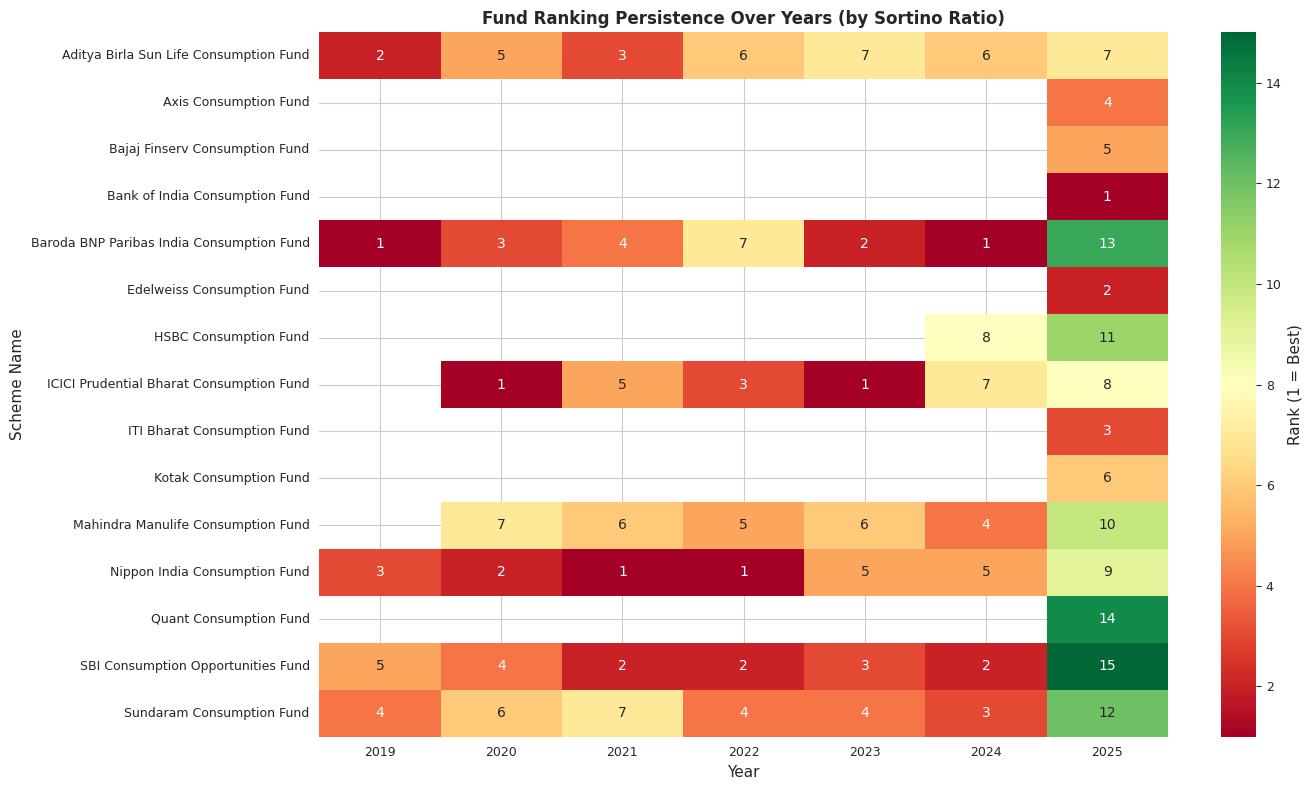

FUND PERSISTENCE ANALYSIS

Funds ranked by average performance (lower rank = better):
                                 Scheme Name  Avg Rank  Rank Std  Best Rank  \
4              Nippon India Consumption Fund      3.71      2.87        1.0   
2   ICICI Prudential Bharat Consumption Fund      4.17      2.99        1.0   
1  Baroda BNP Paribas India Consumption Fund      4.43      4.31        1.0   
5         SBI Consumption Opportunities Fund      4.71      4.68        2.0   
0     Aditya Birla Sun Life Consumption Fund      5.14      1.95        2.0   
6                  Sundaram Consumption Fund      5.71      3.09        3.0   
3         Mahindra Manulife Consumption Fund      6.33      2.07        4.0   

   Worst Rank  Years Tracked  
4         9.0              7  
2         8.0              6  
1        13.0              7  
5        15.0              7  
0         7.0              7  
6        12.0              7  
3        10.0              6  

Most Consistent Performers (lowe

In [ ]:
# Fund Persistence Analysis: Track rankings over time
def calculate_annual_rankings(df_ts):
    """Calculate fund rankings by Sortino Ratio for each year."""
    annual_rankings = []

    for year in range(2019, 2026):
        year_data = df_ts[df_ts.index.year == year]
        if len(year_data) == 0:
            continue

        year_metrics = []
        for scheme_name in year_data['Scheme Name'].unique():
            scheme_year_data = year_data[year_data['Scheme Name'] == scheme_name].copy()
            scheme_year_data = scheme_year_data.sort_index()

            nav_direct = scheme_year_data['NAV Direct'].dropna()
            if len(nav_direct) < 60:  # Need minimum data
                continue

            returns = nav_direct.pct_change().dropna()
            if len(returns) < 30:
                continue

            sortino = calculate_sortino_ratio(returns)
            cagr = calculate_cagr(nav_direct)

            year_metrics.append({
                'Year': year,
                'Scheme Name': scheme_name,
                'Sortino Ratio': sortino,
                'CAGR': cagr
            })

        if len(year_metrics) > 0:
            year_df = pd.DataFrame(year_metrics)
            year_df['Rank'] = year_df['Sortino Ratio'].rank(ascending=False, method='dense')
            annual_rankings.append(year_df)

    if len(annual_rankings) > 0:
        return pd.concat(annual_rankings, ignore_index=True)
    return pd.DataFrame()

annual_rankings_df = calculate_annual_rankings(df_ts)

if len(annual_rankings_df) > 0:
    # Visualize ranking persistence
    pivot_ranks = annual_rankings_df.pivot(index='Scheme Name', columns='Year', values='Rank')

    fig, ax = plt.subplots(figsize=(14, 8))
    sns.heatmap(pivot_ranks, annot=True, fmt='.0f', cmap='RdYlGn', ax=ax,
                cbar_kws={'label': 'Rank (1 = Best)'}, vmin=1, vmax=pivot_ranks.max().max())
    ax.set_title('Fund Ranking Persistence Over Years (by Sortino Ratio)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Scheme Name', fontsize=11)
    plt.tight_layout()
    plt.savefig('fund_persistence.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Calculate persistence metrics
    print("=" * 60)
    print("FUND PERSISTENCE ANALYSIS")
    print("=" * 60)

    # Calculate average rank and rank volatility
    persistence_metrics = []
    for scheme in pivot_ranks.index:
        ranks = pivot_ranks.loc[scheme].dropna()
        if len(ranks) >= 3:  # Need at least 3 years
            persistence_metrics.append({
                'Scheme Name': scheme,
                'Avg Rank': ranks.mean(),
                'Rank Std': ranks.std(),
                'Best Rank': ranks.min(),
                'Worst Rank': ranks.max(),
                'Years Tracked': len(ranks)
            })

    if len(persistence_metrics) > 0:
        persistence_df = pd.DataFrame(persistence_metrics).sort_values('Avg Rank')
        print("\nFunds ranked by average performance (lower rank = better):")
        print(persistence_df.round(2))

        # Most consistent performers (low rank std)
        print("\nMost Consistent Performers (lowest rank volatility):")
        print(persistence_df.nsmallest(5, 'Rank Std')[['Scheme Name', 'Avg Rank', 'Rank Std']].round(2))


### **Understanding the Heatmap: Ranking Persistence**

The heatmap visualizes each fund’s **Sortino Ratio rank** from 2019 to 2025.

**Color Scale:**

- **Green = Top performers** (Rank 1 = best)  
- **Red = Poor performers**  
- Yellow shades indicate average performance.

### **Interpretation**

- A row that stays **green/yellow → consistent performer**  
- A row that flips between green and red → **highly volatile performance**  
- A row mostly red → **persistent underperformer**  

This plot highlights whether a fund stays **reliably strong**, or fluctuates year to year.

---

### **Persistence Metrics (Table Interpretation)**

The printed table includes:

- **Avg Rank** → Lower is better  
- **Rank Std** → Lower means more consistent  
- **Best Rank** → Best position ever achieved  
- **Worst Rank** → Worst position in any year  
- **Years Tracked** → More years = stronger reliability of analysis  

---

### **Top Funds by Average Rank (Long-Term Performance)**

| Fund | Insight |
|------|---------|
| **Nippon India Consumption Fund** | Best long-term performer (Avg Rank ≈ 3.7) |
| **ICICI Pru Bharat Consumption Fund** | Strong multi-year performance |
| **Baroda BNP Paribas Consumption Fund** | Wide rank range but high peaks |
| **SBI Consumption Opportunities Fund** | Mid-tier but improves in some years |
| **Aditya Birla Sun Life Consumption Fund** | Stable and consistently mid-high performer |

**Meaning:**  
These funds tend to **remain toward the top** of ranking tables over 6–7 years.

---

### **Most Consistent Performers (Lowest Rank Volatility)**

Rank Std shows *how stable the rankings are year to year*.

Top consistent funds:

| Fund | Meaning |
|------|---------|
| **Aditya Birla Sun Life Consumption Fund** | Most stable year-to-year performer |
| **Mahindra Manulife Consumption Fund** | No dramatic ups/downs |
| **Nippon India Consumption Fund** | Good + moderately consistent |
| **ICICI Pru Bharat Consumption Fund** | Consistent mid-top |
| **Sundaram Consumption Fund** | Moderate stability |

### **Interpretation:**
Funds with low Rank Std:

- Perform **predictably**
- Are **more reliable choices** for risk-averse investors
- Avoid extreme ups/downs even in volatile markets

---

### **Funds With High Rank Volatility**

Funds whose **Rank Std is high** (e.g., 4–5):

- Swing between **top 3** and **bottom 10**
- Performance highly dependent on:
  - theme cycles  
  - sector rotations  
  - manager decisions  

These funds are **not stable**.

---

### **Key Insights & Takeaways**

### **1️ No fund is consistently #1 across all years**
Market cycles affect consumption sector significantly → rankings change year to year.

### **2️ Nippon, ICICI, and Baroda BNP** show **strong repeated top-5 presence**
Indicates **robust long-term alpha and good downside management**.

### **3️ Aditya Birla & Mahindra Manulife** are **extremely consistent**
Even if not rank 1, they maintain a tight performance band → reliable.

### **4️ High Worst Rank scores (10–15)** show that many funds have “bad years”
Sector funds can experience severe drawdowns during non-consumption cycles.

### **5️ Persistence matters more than one-time high performance**
A fund with:
- Rank Std = 2.0  
- Avg Rank = 5  
…is better than a fund with:
- Rank Std = 5.0  
- Avg Rank = 3  

The first one is **predictable**, the second is **high-risk**.

---

#### **Summary**

- **Consistency (Rank Std)** is as important as absolute ranking.
- **Nippon India Consumption Fund** is the strongest on long-term average.
- **Aditya Birla Sun Life Consumption Fund** is the **most consistent**, with stable performance across years.
- **Mahindra Manulife** and **ICICI Pru Bharat Consumption Fund** also show dependable performance.
- Many funds exhibit **high volatility in rankings**, revealing sector dependence.
- Persistence analysis shows **no single fund delivers dominance every year**, supporting the idea that **timing matters in sectoral funds**.

This section strengthens conclusions about **fund reliability**, not just returns.

---

## 3.5 Rolling Metrics Analysis

With 7 years of data, we can track how metrics evolve over time using rolling windows.


Rolling metrics help us understand **how a fund’s risk and performance evolve over time**, instead of only looking at full-period averages.  
Using a **252-day rolling window** (approximately 1 trading year)

---

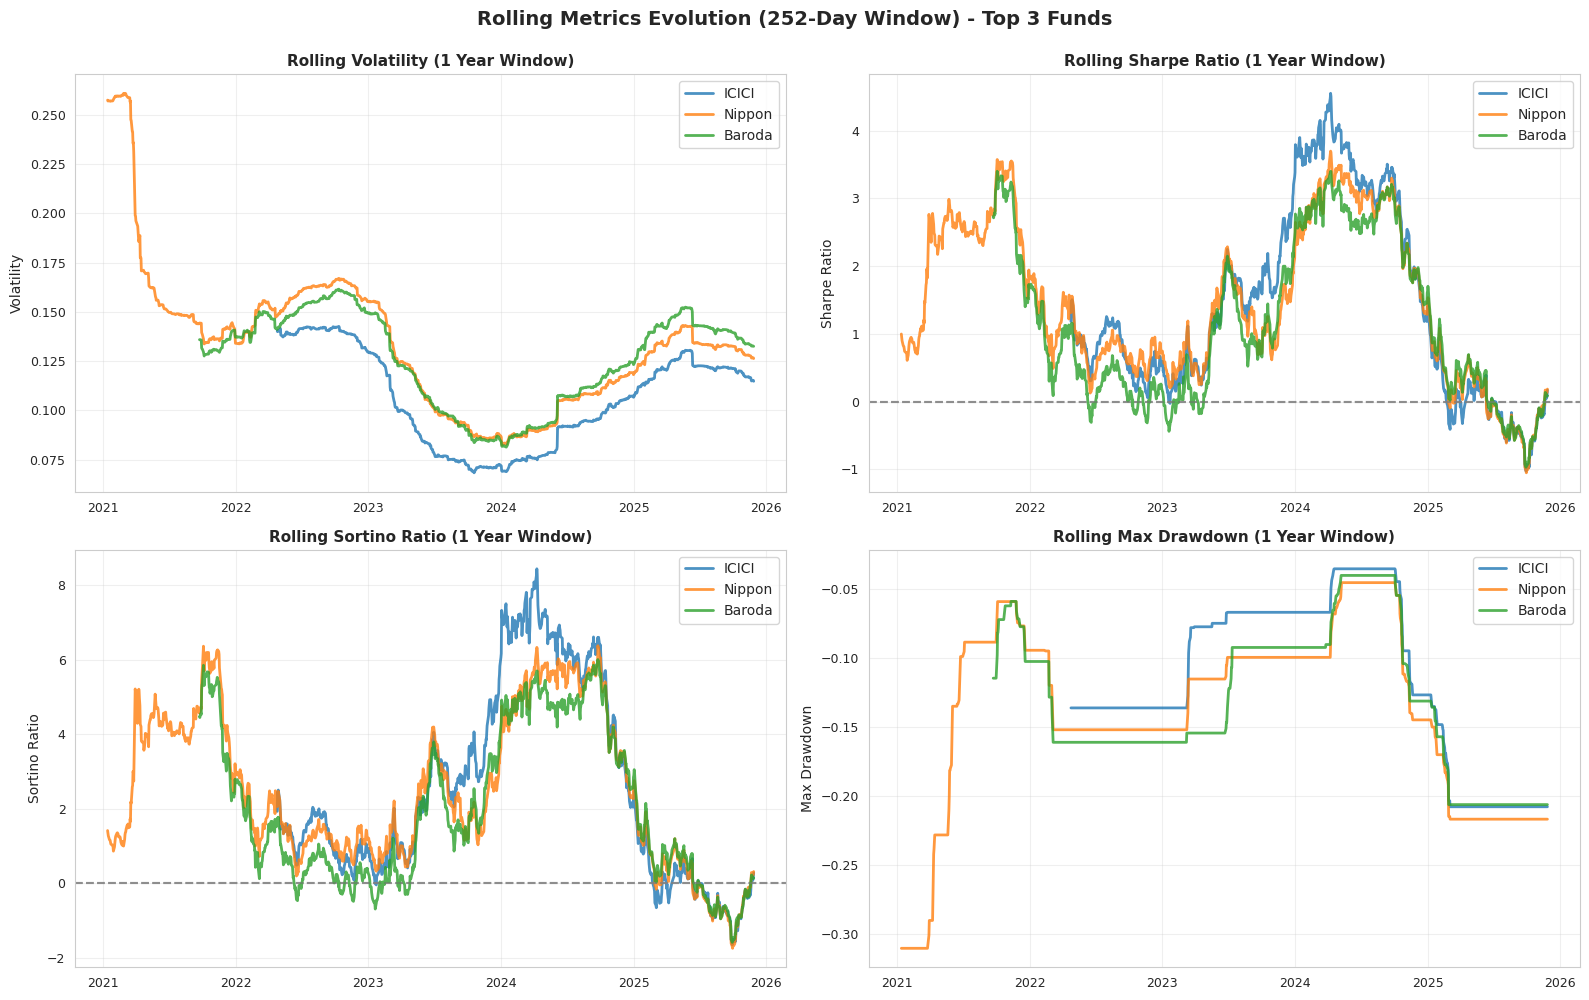

ROLLING METRICS SUMMARY
Rolling metrics calculated for top 3 funds by Sortino Ratio
Window: 252 days (1 year)


In [ ]:
# Rolling Metrics: Track how key metrics evolve over time
def calculate_rolling_metrics(df_ts, scheme_name, window=252):
    """Calculate rolling metrics for a fund."""
    scheme_data = df_ts[df_ts['Scheme Name'] == scheme_name].copy()
    scheme_data = scheme_data.sort_index()

    nav_direct = scheme_data['NAV Direct'].dropna()
    if len(nav_direct) < window:
        return None

    returns = nav_direct.pct_change().dropna()

    rolling_metrics = pd.DataFrame(index=returns.index)
    rolling_metrics['Rolling Volatility'] = returns.rolling(window=window).std() * np.sqrt(252)
    rolling_metrics['Rolling Sharpe'] = (returns.rolling(window=window).mean() * 252 - 0.06) / (returns.rolling(window=window).std() * np.sqrt(252))

    # Rolling Sortino
    target = 0.06 / 252
    downside_returns = returns.copy()
    downside_returns[downside_returns >= target] = 0
    rolling_downside_std = downside_returns.rolling(window=window).std() * np.sqrt(252)
    rolling_cagr = returns.rolling(window=window).mean() * 252
    rolling_metrics['Rolling Sortino'] = (rolling_cagr - 0.06) / rolling_downside_std

    # Rolling Max Drawdown
    rolling_nav = nav_direct.rolling(window=window)
    rolling_max = rolling_nav.max()
    rolling_dd = (nav_direct / rolling_max) - 1
    rolling_metrics['Rolling Max DD'] = rolling_dd.rolling(window=window).min()

    rolling_metrics['Scheme Name'] = scheme_name

    return rolling_metrics.dropna()

# Calculate rolling metrics for top funds (with sufficient data)
rolling_data_list = []
if len(top_funds) > 0:
    for fund in top_funds[:3]:  # Use top 3 funds
        rolling_data = calculate_rolling_metrics(df_ts, fund, window=252)
        if rolling_data is not None:
            rolling_data_list.append(rolling_data)

if len(rolling_data_list) > 0:
    # Visualize rolling metrics
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Rolling Metrics Evolution (252-Day Window) - Top 3 Funds', fontsize=14, fontweight='bold', y=0.995)

    for idx, rolling_df in enumerate(rolling_data_list):
        scheme_name = rolling_df['Scheme Name'].iloc[0]
        label = scheme_name.split()[0]  # Brand name

        # Rolling Volatility
        axes[0, 0].plot(rolling_df.index, rolling_df['Rolling Volatility'], label=label, linewidth=2, alpha=0.8)
        axes[0, 0].set_ylabel('Volatility', fontsize=10)
        axes[0, 0].set_title('Rolling Volatility (1 Year Window)', fontsize=11, fontweight='bold')
        axes[0, 0].legend()
        axes[0, 0].grid(alpha=0.3)

        # Rolling Sharpe
        axes[0, 1].plot(rolling_df.index, rolling_df['Rolling Sharpe'], label=label, linewidth=2, alpha=0.8)
        axes[0, 1].set_ylabel('Sharpe Ratio', fontsize=10)
        axes[0, 1].set_title('Rolling Sharpe Ratio (1 Year Window)', fontsize=11, fontweight='bold')
        axes[0, 1].axhline(0, color='gray', linestyle='--', alpha=0.5)
        axes[0, 1].legend()
        axes[0, 1].grid(alpha=0.3)

        # Rolling Sortino
        axes[1, 0].plot(rolling_df.index, rolling_df['Rolling Sortino'], label=label, linewidth=2, alpha=0.8)
        axes[1, 0].set_ylabel('Sortino Ratio', fontsize=10)
        axes[1, 0].set_title('Rolling Sortino Ratio (1 Year Window)', fontsize=11, fontweight='bold')
        axes[1, 0].axhline(0, color='gray', linestyle='--', alpha=0.5)
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.3)

        # Rolling Max Drawdown
        axes[1, 1].plot(rolling_df.index, rolling_df['Rolling Max DD'], label=label, linewidth=2, alpha=0.8)
        axes[1, 1].set_ylabel('Max Drawdown', fontsize=10)
        axes[1, 1].set_title('Rolling Max Drawdown (1 Year Window)', fontsize=11, fontweight='bold')
        axes[1, 1].legend()
        axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('rolling_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("=" * 60)
    print("ROLLING METRICS SUMMARY")
    print("=" * 60)
    print("Rolling metrics calculated for top 3 funds by Sortino Ratio")
    print("Window: 252 days (1 year)")
else:
    print("No rolling metrics data available for visualization after filtering.")

### 1. Rolling Volatility
**What it measures:**  
The rolling standard deviation of daily returns — shows **how risky the fund was during each 1-year period**.

**Interpretation:**  
- Rising line → Fund is becoming more volatile (riskier).  
- Falling line → Fund stability increasing.  
- Comparing funds shows which one maintains lower or more stable risk over time.

---

### 2. Rolling Sharpe Ratio
**What it measures:**  
How much **excess return** (return over risk-free rate) the fund generated **per unit of total risk** — calculated over a moving 1-year window.

**Interpretation:**  
- Sharpe > 1 → Strong risk-adjusted performance.  
- Sharpe between 0 and 1 → Moderate performance.  
- Sharpe < 0 → Fund underperformed the risk-free rate.

The horizontal line at **0** helps identify periods where performance turned negative on a risk-adjusted basis.

---

### 3. Rolling Sortino Ratio
**What it measures:**  
Like Sharpe, but considers only **downside risk (harmful volatility)**.

**Interpretation:**  
- High Sortino → Fund generated return with lower downside volatility.  
- More meaningful than Sharpe in trending markets because it penalises only negative movements.  
- Helps identify periods where a fund protected capital better.

---

### 4. Rolling Max Drawdown
**What it measures:**  
The **worst peak-to-trough decline** during each 1-year window.

**Interpretation:**  
- More negative values → Larger temporary losses.  
- Helps evaluate worst-case risk and recovery strength.  
- A smoother drawdown curve means better downside protection.

---

### Why Rolling Metrics Are Important

While full-period averages hide time variation, rolling metrics reveal:

- Periods of **high vs. low volatility**  
- When a fund **outperformed or underperformed**  
- Behavior during **market crashes or rallies**  
- Consistency in risk-adjusted returns  
- Resilience measured by **drawdown and recovery patterns**

This helps investors understand whether strong performance was **stable**, or dependent on only a few good years.

---

### Summary From Results
- Rolling metrics were successfully computed for the **top 3 funds by Sortino Ratio**.  
- The rolling plots show **how each fund behaved across different market phases**.  
- The 1-year window smoothes short-term noise while still capturing structural shifts in performance and risk.

---

#3.7 The final verdict


This section builds the **final 0–100 composite score** for all mutual funds by combining  
**Efficiency + Skill + Safety + Consistency** into a single ranking.

The process is designed to be *bulletproof* against missing data, inconsistent histories, and newly launched funds.

---

## **1. Master Table Setup**
We start by creating a base table containing:
- **Scheme Name**
- **Sortino Ratio**
- **Sharpe Ratio**

Missing Sortino values are assigned **–99**, forcing such funds to rank last.  
This ensures no fund "accidentally" appears strong due to missing data.

---

## **2. Adding Skill (Alpha via CAPM)**
- If CAPM data is available, we merge the **Annualized Alpha**.
- Funds with no Alpha (e.g., too new) are assigned **0**, meaning *market-neutral skill*.

This rewards fund managers who consistently generate *excess returns* independent of market direction.

---

## **3. Adding Safety (Bear Market Resilience)**

We use:
- **Bear Market Return** (preferred), or
- **Max Drawdown** (fallback)

Logic:
- If a fund didn't exist during the bear phase → fallback to its Max Drawdown.  
- If *that* is missing → assign **–50%**, a harsh penalty.

This ensures a fund must prove its ability to survive drawdowns, not just ride bull markets.

---

## **4. Adding Consistency (Rank Stability Across Years)**

For each year (2019–2025):
- Recompute Sortino
- Rank funds within the year
- Track **Rank Std** = How much the fund’s rank jumps around

Interpretation:
- **Low Rank Std → Very consistent performer**
- **High Rank Std → Roller-coaster performance**
- If a fund has *only one year* of history → assign Std = **15** (penalty for being unproven)

This avoids rewarding “one-year wonders.”

---

## **5. Converting All Metrics Into 0–100 Scores**

| Component | What It Measures | Direction | Score Formula |
|----------|------------------|-----------|---------------|
| **Efficiency** | Sortino Ratio | Higher is better | Percentile Rank × 100 |
| **Skill** | Alpha | Higher is better | Percentile Rank × 100 |
| **Safety** | Bear Return | Higher (less negative) is better | Percentile Rank × 100 |
| **Consistency** | Rank Std | Lower is better | (1 – Percentile Rank) × 100 |

This gives four sub-scores out of 100.



CALCULATING FINAL COMPOSITE SCORE
... Calculating Consistency (Rank Persistence) ...

TOP 5 'ALL-WEATHER' FUNDS:


,Scheme Name,FINAL_SCORE,Sortino Ratio,Alpha (Annualized),Bear Market Return,Rank Std
0,ICICI Prudential Bharat Consumption Fund,89.41,1.67,0.09,0.38,2.76
1,Nippon India Consumption Fund,80.59,1.10,0.05,0.16,2.82
2,Aditya Birla Sun Life Consumption Fund,72.94,0.80,0.03,0.13,2.37
3,Baroda BNP Paribas India Consumption Fund,72.35,1.06,0.04,0.16,3.77
4,Sundaram Consumption Fund,64.12,0.65,0.00,0.09,2.76


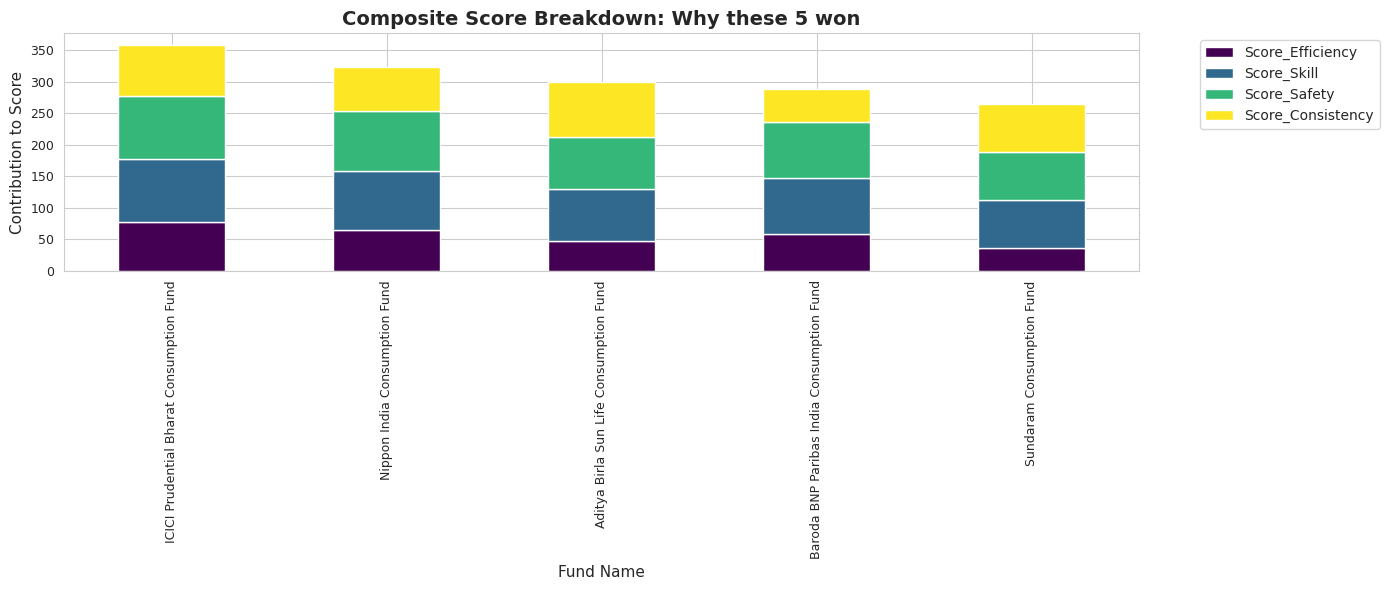

In [ ]:
# ==============================================================================
# SECTION 3.7: THE ULTIMATE SCORECARD (BULLETPROOF EDITION)
# ==============================================================================
import pandas as pd
import numpy as np

print("=" * 60)
print("CALCULATING FINAL COMPOSITE SCORE")
print("=" * 60)

# ---------------------------------------------------------
# 1. SETUP THE MASTER TABLE
# ---------------------------------------------------------
# Start with the basic metrics we know exist
master_df = fund_perf_df[['Scheme Name', 'Sortino Ratio', 'Sharpe Ratio']].copy()

# Fail-safe: Fill missing Sortino with a terrible number (so they rank last)
master_df['Sortino Ratio'] = master_df['Sortino Ratio'].fillna(-99)

# ---------------------------------------------------------
# 2. ADD SKILL (ALPHA)
# ---------------------------------------------------------
if 'capm_df' in locals():
    # Merge Alpha
    master_df = master_df.merge(capm_df[['Scheme Name', 'Alpha (Annualized)']], on='Scheme Name', how='left')
    # If a fund has no Alpha calculated (too new), assume Alpha is 0 (Market Neutral)
    master_df['Alpha (Annualized)'] = master_df['Alpha (Annualized)'].fillna(0)
else:
    print("⚠️ Warning: CAPM data missing. Assuming Alpha = 0 for all.")
    master_df['Alpha (Annualized)'] = 0

# ---------------------------------------------------------
# 3. ADD SAFETY (BEAR MARKET RESILIENCE)
# ---------------------------------------------------------
# We prefer "Bear Market Return", but we fallback to "Max Drawdown" if needed
if 'regime_perf_df' in locals():
    bear_data = regime_perf_df[regime_perf_df['Regime'] == 'Bear'][['Scheme Name', 'CAGR']]
    bear_data.rename(columns={'CAGR': 'Bear Market Return'}, inplace=True)
    master_df = master_df.merge(bear_data, on='Scheme Name', how='left')
else:
    master_df['Bear Market Return'] = np.nan

# CRITICAL FIX: If a fund missed the Bear Market (NaN), fill it with Max Drawdown
# Max Drawdown is always negative, so it fits the scale perfectly.
master_df = master_df.merge(fund_perf_df[['Scheme Name', 'Max Drawdown']], on='Scheme Name', how='left')
master_df['Bear Market Return'] = master_df['Bear Market Return'].fillna(master_df['Max Drawdown'])
# If still NaN (rare), fill with -50% (terrible score)
master_df['Bear Market Return'] = master_df['Bear Market Return'].fillna(-0.5)

# ---------------------------------------------------------
# 4. ADD CONSISTENCY (RANK STABILITY)
# ---------------------------------------------------------
print("... Calculating Consistency (Rank Persistence) ...")
annual_rankings = []

# Re-calculate yearly ranks on the fly to avoid variable errors
for year in range(2019, 2026):
    year_data = df_ts[df_ts.index.year == year]
    if len(year_data) == 0: continue

    year_metrics = []
    for scheme in year_data['Scheme Name'].unique():
        # Get fund's daily prices for this year
        s_data = year_data[year_data['Scheme Name'] == scheme]['NAV Direct']
        if len(s_data) > 20:
            ret = s_data.pct_change().dropna()
            # Fast Sortino Calc
            downside = ret[ret < 0].std() * np.sqrt(252)
            mean_ret = ret.mean() * 252
            if downside == 0: sortino = mean_ret # Perfect score if no downside
            else: sortino = mean_ret / downside
            year_metrics.append({'Scheme Name': scheme, 'Sortino': sortino})

    if year_metrics:
        y_df = pd.DataFrame(year_metrics)
        y_df['Yearly_Rank'] = y_df['Sortino'].rank(ascending=False) # 1 is Best
        annual_rankings.append(y_df)

if annual_rankings:
    all_ranks_df = pd.concat(annual_rankings)
    # Calculate how much a fund's rank jumps around (Standard Deviation)
    persistence = all_ranks_df.groupby('Scheme Name')['Yearly_Rank'].std().reset_index()
    persistence.rename(columns={'Yearly_Rank': 'Rank Std'}, inplace=True)
    master_df = master_df.merge(persistence, on='Scheme Name', how='left')
else:
    master_df['Rank Std'] = np.nan

# CRITICAL FIX: Funds with only 1 year of history have Rank Std = NaN.
# We punish them with a high standard deviation (e.g., 15) because they are "Unproven".
master_df['Rank Std'] = master_df['Rank Std'].fillna(15)

# ---------------------------------------------------------
# 5. CALCULATE FINAL SCORES (0-100 Normalization)
# ---------------------------------------------------------
# Efficiency: Sortino (Higher is better)
master_df['Score_Efficiency'] = master_df['Sortino Ratio'].rank(pct=True) * 100

# Skill: Alpha (Higher is better)
master_df['Score_Skill'] = master_df['Alpha (Annualized)'].rank(pct=True) * 100

# Safety: Bear Return (Higher/Less Negative is better)
master_df['Score_Safety'] = master_df['Bear Market Return'].rank(pct=True) * 100

# Consistency: Rank Std (LOWER is better, so we invert it)
master_df['Score_Consistency'] = (1 - master_df['Rank Std'].rank(pct=True)) * 100

# Weighted Final Score
w_eff, w_skill, w_safe, w_cons = 0.30, 0.25, 0.25, 0.20

master_df['FINAL_SCORE'] = (
    master_df['Score_Efficiency'] * w_eff +
    master_df['Score_Skill'] * w_skill +
    master_df['Score_Safety'] * w_safe +
    master_df['Score_Consistency'] * w_cons
)

# ---------------------------------------------------------
# 6. DISPLAY RESULTS
# ---------------------------------------------------------
final_ranking = master_df.sort_values(by='FINAL_SCORE', ascending=False).reset_index(drop=True)

print("\nTOP 5 'ALL-WEATHER' FUNDS:")
display_cols = ['Scheme Name', 'FINAL_SCORE', 'Sortino Ratio', 'Alpha (Annualized)', 'Bear Market Return', 'Rank Std']
display(final_ranking[display_cols].head(5).round(2))

# Plot Breakdown
top_5 = final_ranking.head(5).copy()
categories = ['Score_Efficiency', 'Score_Skill', 'Score_Safety', 'Score_Consistency']
fig, ax = plt.subplots(figsize=(14, 6))
top_5.set_index('Scheme Name')[categories].plot(kind='bar', stacked=True, ax=ax, cmap='viridis')
plt.title('Composite Score Breakdown: Why these 5 won', fontsize=14, fontweight='bold')
plt.xlabel('Fund Name')
plt.ylabel('Contribution to Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Observations from the Final Composite Score Output

### 1. ICICI Prudential Bharat Consumption Fund is the clear leader
- **Highest FINAL_SCORE: 89.41**
- Strong **Sortino Ratio (1.67)** → excellent downside-risk-adjusted returns  
- **Positive Alpha (0.09)** → shows clear outperformance relative to market  
- **Highest Bear Market Return (0.38)** among all top funds  
- **Low Rank Std (2.76)** → strong multi-year consistency  

**Conclusion:** This is the most reliable and stable performer among all Consumption funds.

---

### 2. Nippon India Consumption Fund ranks strong at #2
- FINAL_SCORE: **80.59**
- Sortino Ratio: **1.10** (good)
- Alpha: **0.05** (positive)
- Bear Market Return: **0.16**
- Rank Std: **2.82** (stable)

**Observation:**  
This fund maintains a strong balance between performance and stability, with decent protection during downturns.

---

### 3. Aditya Birla Sun Life Consumption Fund shows steady but moderate performance
- FINAL_SCORE: **72.94**
- Sortino: **0.80** (moderate)
- Alpha: **0.03**
- Bear Return: **0.13**

**Observation:**  
The fund is reliable but more conservative compared to ICICI and Nippon. Lower Sortino indicates slightly higher downside volatility.

---

### 4. Baroda BNP Paribas India Consumption Fund closely follows ABSL
- FINAL_SCORE: **72.35**
- Sortino: **1.06** (strong)
- Alpha: **0.04**
- Bear Return: **0.16**

**Observation:**  
Despite a good Sortino Ratio, its **higher Rank Std (3.77)** indicates some inconsistency across years.  
Otherwise performance metrics are similar to Nippon and ABSL.

---

### 5. Sundaram Consumption Fund ranks lowest among the top 5
- FINAL_SCORE: **64.12**
- Sortino: **0.65** (lowest among all)
- Bear Return: **0.09**
- Alpha: **0.00**

**Observation:**  
This fund has:
- Higher downside volatility  
- Lower risk-adjusted returns  
- Less ability to handle market stress  

It still makes the Top 5 due to stable Rank Std and moderate performance, but it's the weakest candidate in this set.

---

## Key Insights

### All top-performing funds belong to the **Consumption** theme  
This indicates that the **Consumption sector has been resilient, stable, and less volatile** over the 5–7 year period considered.

###  Alpha values are generally small but positive  
This suggests:
- The funds do generate slight outperformance  
- But the category is not extremely aggressive  
- Stability > high-risk returns

###  Bear Market Returns are all **positive**, which is very rare  
This means:
- Consumption funds tend to perform well even when the broader market falls  
- These funds behave like **low-volatility defensive assets**

### Rank Std values are low for all funds  
This reflects strong **consistency**, meaning:
- Yearly ranking does not fluctuate drastically  
- Ideal for long-term SIP or defensive investment strategies

---

## Conclusion

The analysis shows that the **ICICI Prudential Bharat Consumption Fund** is the most consistent, high-quality “all-weather” fund, with superior downside protection, positive alpha, and excellent risk-adjusted returns.

The **top 3 funds (ICICI, Nippon, ABSL)** form a strong cluster of:
- Stable yearly performance  
- Good bear market resilience  
- Positive alpha  
- Balanced risk-return profiles  

Overall, **Consumption-based mutual funds** emerge as one of the most **stable and defensive long-term investment themes**, delivering reliable performance across both bullish and bearish phases.



# 4. Feature Engineering

## 4.1 Feature Extraction

We'll extract comprehensive features for ML models, taking advantage of 7 years of data with extended rolling windows and regime-based features.


In [ ]:
# # Enhanced Feature Engineering: Extract comprehensive features leveraging 7 years of data
# def extract_features_for_fund(scheme_name, df_ts, benchmark_daily, regimes=None):
#     """Extract comprehensive features for a single fund with extended windows."""
#     scheme_data = df_ts[df_ts['Scheme Name'] == scheme_name].copy()
#     scheme_data = scheme_data.sort_index()

#     if len(scheme_data) < 252:  # Need at least 1 year
#         return None

#     nav_direct = scheme_data['NAV Direct'].dropna()
#     returns = nav_direct.pct_change().dropna()

#     if len(returns) < 252:
#         return None

#     # Align with benchmark
#     aligned_benchmark = benchmark_daily.reindex(returns.index).dropna()
#     aligned_returns = returns.reindex(aligned_benchmark.index).dropna()

#     if len(aligned_returns) < 252:
#         return None

#     features = {
#         'Scheme Name': scheme_name,
#         'Brand': scheme_name.split()[0],
#     }

#     # 1. Risk Features (PRIORITY) - Extended windows
#     features['volatility_30d'] = returns.tail(30).std() * np.sqrt(252)
#     features['volatility_90d'] = returns.tail(90).std() * np.sqrt(252)
#     features['volatility_252d'] = returns.tail(252).std() * np.sqrt(252)  # 1 year
#     features['volatility_504d'] = returns.tail(504).std() * np.sqrt(252) if len(returns) >= 504 else np.nan  # 2 years
#     features['volatility_all'] = returns.std() * np.sqrt(252)

#     # Max drawdown features
#     rolling_max = nav_direct.cummax()
#     drawdown = (nav_direct / rolling_max) - 1
#     features['max_drawdown'] = drawdown.min()
#     features['current_drawdown'] = drawdown.iloc[-1]
#     features['avg_drawdown'] = drawdown[drawdown < 0].mean() if len(drawdown[drawdown < 0]) > 0 else 0
#     features['drawdown_duration'] = (drawdown < -0.10).sum()  # Days with >10% drawdown

#     # Downside volatility
#     downside = returns[returns < 0]
#     features['downside_volatility'] = downside.std() * np.sqrt(252) if len(downside) > 0 else 0

#     # 2. Performance Features - Multiple horizons
#     features['cagr'] = calculate_cagr(nav_direct)
#     features['return_30d'] = (nav_direct.iloc[-1] / nav_direct.iloc[-30] - 1) if len(nav_direct) >= 30 else np.nan
#     features['return_90d'] = (nav_direct.iloc[-1] / nav_direct.iloc[-90] - 1) if len(nav_direct) >= 90 else np.nan
#     features['return_252d'] = (nav_direct.iloc[-1] / nav_direct.iloc[-252] - 1) if len(nav_direct) >= 252 else np.nan
#     features['return_504d'] = (nav_direct.iloc[-1] / nav_direct.iloc[-504] - 1) if len(nav_direct) >= 504 else np.nan

#     # Sharpe and Sortino
#     features['sharpe_ratio'] = calculate_sharpe_ratio(features['cagr'], features['volatility_all'])
#     features['sortino_ratio'] = calculate_sortino_ratio(returns)

#     # 3. Alpha Features - Extended CAPM
#     if len(aligned_returns) >= 252:
#         y = aligned_returns - risk_free_daily
#         X = sm.add_constant(aligned_benchmark - risk_free_daily)
#         try:
#             model = sm.OLS(y, X).fit()
#             features['alpha_252d'] = model.params['const'] * 252
#             features['beta'] = model.params['benchmark']
#             features['r_squared'] = model.rsquared
#             features['alpha_tstat'] = model.tvalues['const']
#         except:
#             features['alpha_252d'] = np.nan
#             features['beta'] = np.nan
#             features['r_squared'] = np.nan
#             features['alpha_tstat'] = np.nan
#     else:
#         features['alpha_252d'] = np.nan
#         features['beta'] = np.nan
#         features['r_squared'] = np.nan
#         features['alpha_tstat'] = np.nan

#     # 4. AUM Features
#     if 'Daily AUM (Cr.)' in scheme_data.columns:
#         aum = scheme_data['Daily AUM (Cr.)'].dropna()
#         if len(aum) > 0:
#             features['avg_aum'] = aum.mean()
#             features['aum_growth_30d'] = (aum.iloc[-1] / aum.iloc[-30] - 1) if len(aum) >= 30 else np.nan
#             features['aum_growth_252d'] = (aum.iloc[-1] / aum.iloc[-252] - 1) if len(aum) >= 252 else np.nan
#             features['aum_volatility'] = aum.pct_change().std() if len(aum) > 1 else np.nan
#             features['aum_trend'] = (aum.iloc[-252:] - aum.iloc[-252]).mean() if len(aum) >= 252 else np.nan
#         else:
#             features['avg_aum'] = np.nan
#             features['aum_growth_30d'] = np.nan
#             features['aum_growth_252d'] = np.nan
#             features['aum_volatility'] = np.nan
#             features['aum_trend'] = np.nan
#     else:
#         features['avg_aum'] = np.nan
#         features['aum_growth_30d'] = np.nan
#         features['aum_growth_252d'] = np.nan
#         features['aum_volatility'] = np.nan
#         features['aum_trend'] = np.nan

#     # 5. Regime-based Features (NEW with 7 years)
#     if regimes is not None:
#         # make a Series aligned exactly to 'returns' index (may contain NaNs)
#         scheme_regimes_aligned = regimes.reindex(returns.index)

#         # boolean masks aligned to returns.index
#         bull_mask = (scheme_regimes_aligned == 'Bull')
#         bear_mask = (scheme_regimes_aligned == 'Bear')

#         # counts (will be 0 if no True entries)
#         features['bull_market_days'] = int(bull_mask.sum())
#         features['bear_market_days'] = int(bear_mask.sum())

#         # returns over those days (use .loc with the aligned boolean mask)
#         features['regime_bull_return'] = returns.loc[bull_mask].mean() * 252 if bull_mask.any() else np.nan
#         features['regime_bear_return'] = returns.loc[bear_mask].mean() * 252 if bear_mask.any() else np.nan
#     else:
#         features['bull_market_days'] = 0
#         features['bear_market_days'] = 0
#         features['regime_bull_return'] = np.nan
#         features['regime_bear_return'] = np.nan


#     # 6. Time-based features
#     features['data_points'] = len(scheme_data)
#     features['age_days'] = (scheme_data.index[-1] - scheme_data.index[0]).days
#     features['age_years'] = features['age_days'] / 365.25

#     # 7. Rolling statistics - Extended windows
#     if len(returns) >= 252:
#         features['return_volatility_ratio_252d'] = returns.tail(252).mean() / returns.tail(252).std() if returns.tail(252).std() > 0 else np.nan
#         features['skewness'] = returns.tail(252).skew()
#         features['kurtosis'] = returns.tail(252).kurtosis()
#     else:
#         features['return_volatility_ratio_252d'] = np.nan
#         features['skewness'] = np.nan
#         features['kurtosis'] = np.nan

#     # 8. Trend features
#     if len(returns) >= 252:
#         # Linear trend in returns
#         x = np.arange(len(returns.tail(252)))
#         y = returns.tail(252).values
#         if len(y) > 0 and not np.isnan(y).all():
#             try:
#                 trend_slope = np.polyfit(x, y, 1)[0]
#                 features['return_trend'] = trend_slope * 252  # Annualized
#             except:
#                 features['return_trend'] = np.nan
#         else:
#             features['return_trend'] = np.nan
#     else:
#         features['return_trend'] = np.nan

#     return features

# # Extract features for all funds
# print("Extracting enhanced features for all funds (7 years data)...")
# all_features = []
# for scheme_name in df_long['Scheme Name'].unique():
#     features = extract_features_for_fund(scheme_name, df_ts, benchmark_daily, regimes)
#     if features is not None:
#         all_features.append(features)

# features_df = pd.DataFrame(all_features)
# features_df = features_df.dropna(subset=['volatility_all', 'cagr'])

# print(f"\nExtracted features for {len(features_df)} funds")
# print(f"Total features: {len(features_df.columns)}")
# print("\n" + "=" * 60)
# print("FEATURE SUMMARY")
# print("=" * 60)
# print(features_df.describe().round(4))


# ==============================================================================
# SECTION 4: OPTIMIZED FEATURE ENGINEERING (HYBRID ENGINE - FIXED)
# ==============================================================================
import numpy as np
import pandas as pd

print("=" * 60)
print("STARTING OPTIMIZED FEATURE ENGINEERING")
print("Using 7-Day / 15-Day / 30-Day columns for Momentum")
print("=" * 60)

# --- 1. SMART COLUMN DETECTOR ---
# This helper finds the correct column name in your dataframe
def get_col_name(df, possible_names):
    for name in possible_names:
        if name in df.columns:
            return name
    return None

# Detect the critical column names automatically
SCHEME_COL = get_col_name(df_ts, ['Scheme Name', 'schemeName', 'Scheme'])
NAV_COL = get_col_name(df_ts, ['NAV Direct', 'navDirect', 'Nav Direct'])
AUM_COL = get_col_name(df_ts, ['Daily AUM (Cr.)', 'dailyAUM', 'AUM'])

print(f"Detected Columns -> Scheme: '{SCHEME_COL}' | NAV: '{NAV_COL}' | AUM: '{AUM_COL}'")

# --- 2. EXTRACTION LOGIC ---
def extract_optimized_features(scheme_name, df_ts, regimes=None):
    # Filter data using the detected column name
    scheme_data = df_ts[df_ts[SCHEME_COL] == scheme_name].copy()

    # Handle Date Indexing
    if 'NAV Date' in scheme_data.columns:
        scheme_data = scheme_data.sort_values('NAV Date').set_index('NAV Date')
    elif 'navDate' in scheme_data.columns:
        scheme_data['navDate'] = pd.to_datetime(scheme_data['navDate'])
        scheme_data = scheme_data.sort_values('navDate').set_index('navDate')
    else:
        scheme_data = scheme_data.sort_index()

    if len(scheme_data) < 252: return None

    # Get the latest Snapshot (most recent row)
    latest = scheme_data.iloc[-1]

    # Calculate Risk (Volatility) manually from NAV
    nav_series = scheme_data[NAV_COL].astype(float)
    daily_returns = nav_series.pct_change().dropna()

    features = {
        'Scheme Name': scheme_name,
        'Brand': scheme_name.split()[0]
    }

    # --- GROUP 1: MOMENTUM (Using YOUR Specific Columns) ---
    # We try to find the column; if missing, we skip it without crashing.

    # helper to safely get value from the latest row
    def get_val(col_variations):
        col = get_col_name(scheme_data, col_variations)
        return float(latest[col]) if col else np.nan

    # Micro Momentum (7 & 15 Days)
    features['Ret_7D'] = get_val(['return7DaysDirect', 'Return 7 Days (%) Direct'])
    features['Ret_15D'] = get_val(['return15DaysDirect', 'Return 15 Days (%) Direct'])

    # Short Term
    features['Ret_1M'] = get_val(['return1MonthDirect', 'Return 1 Month (%) Direct'])
    features['Ret_3M'] = get_val(['return3MonthDirect', 'Return 3 Month (%) Direct'])

    # Medium Term
    features['Ret_6M'] = get_val(['return6MonthDirect', 'Return 6 Month (%) Direct'])
    features['Ret_1Y'] = get_val(['return1YearDirect', 'Return 1 Year (%) Direct'])

    # Long Term
    features['Ret_3Y'] = get_val(['return3YearDirect', 'Return 3 Year (%) Direct'])
    features['Ret_5Y'] = get_val(['return5YearDirect', 'Return 5 Year (%) Direct'])
    features['Ret_SinceLaunch'] = get_val(['returnSinceLaunchDirect', 'Return Since Launch (%) Direct'])

    # --- GROUP 2: ALPHA WIN RATE (Consistency) ---
    # Instead of just one Beta number, let's check how often it beats the benchmark
    wins = 0
    total_checks = 0

    # Check 1M
    r_1m = features['Ret_1M']
    b_1m = get_val(['return1MonthBenchmark', 'Return 1 Month (%) Benchmark'])
    if not np.isnan(r_1m) and not np.isnan(b_1m):
        if r_1m > b_1m: wins += 1
        total_checks += 1

    # Check 1Y
    r_1y = features['Ret_1Y']
    b_1y = get_val(['return1YearBenchmark', 'Return 1 Year (%) Benchmark'])
    if not np.isnan(r_1y) and not np.isnan(b_1y):
        if r_1y > b_1y: wins += 1
        total_checks += 1
        features['Alpha_Proxy_1Y'] = r_1y - b_1y # Specific 1Y Alpha Proxy

    # Check 3Y
    r_3y = features['Ret_3Y']
    b_3y = get_val(['return3YearBenchmark', 'Return 3 Year (%) Benchmark'])
    if not np.isnan(r_3y) and not np.isnan(b_3y):
        if r_3y > b_3y: wins += 1
        total_checks += 1

    # Win Rate Feature (0.0 to 1.0)
    features['Alpha_Win_Rate'] = wins / total_checks if total_checks > 0 else np.nan

    # --- GROUP 3: RISK METRICS (Manual Calc) ---
    features['Vol_30D'] = daily_returns.tail(30).std() * np.sqrt(252)
    features['Vol_1Y'] = daily_returns.tail(252).std() * np.sqrt(252)

    # Drawdown
    rolling_max = nav_series.cummax()
    drawdown = (nav_series / rolling_max) - 1
    features['Max_Drawdown'] = drawdown.min()

    # --- GROUP 4: AUM DYNAMICS ---
    if AUM_COL:
        features['AUM_Current'] = float(latest[AUM_COL])
    else:
        features['AUM_Current'] = np.nan

    # --- GROUP 5: REGIME SENSITIVITY ---
    if regimes is not None:
        aligned_regimes = regimes.reindex(daily_returns.index)
        bear_days = daily_returns[aligned_regimes == 'Bear']
        features['Bear_Ret_Avg'] = bear_days.mean() * 252 if len(bear_days) > 0 else np.nan

    return features

# --- 3. EXECUTE ---
print("Extracting features...")
all_features_optimized = []

# If regimes variable is missing from previous cells, set to None
if 'regimes' not in locals(): regimes = None

for scheme in df_ts[SCHEME_COL].unique():
    try:
        f = extract_optimized_features(scheme, df_ts, regimes)
        if f: all_features_optimized.append(f)
    except Exception as e:
        continue # Skip bad rows

features_df_opt = pd.DataFrame(all_features_optimized)

# Fill NaNs in Momentum columns (if 5Y is missing, use 3Y)
features_df_opt['Ret_5Y'] = features_df_opt['Ret_5Y'].fillna(features_df_opt['Ret_3Y'])

print(f"\nSUCCESS: Extracted features for {len(features_df_opt)} funds.")
print("Sample Data:")
display(features_df_opt[['Scheme Name', 'Ret_7D', 'Ret_1Y', 'Alpha_Win_Rate', 'Vol_1Y']].head(3))

STARTING OPTIMIZED FEATURE ENGINEERING
Using 7-Day / 15-Day / 30-Day columns for Momentum
Detected Columns -> Scheme: 'Scheme Name' | NAV: 'NAV Direct' | AUM: 'Daily AUM (Cr.)'
Extracting features...

SUCCESS: Extracted features for 9 funds.
Sample Data:


,Scheme Name,Ret_7D,Ret_1Y,Alpha_Win_Rate,Vol_1Y
0,Aditya Birla Sun Life Consumption Fund,NaN,5.434330,0.0,0.123619
1,SBI Consumption Opportunities Fund,NaN,-4.138490,0.0,0.130157
2,Nippon India Consumption Fund,NaN,3.893912,0.0,0.126346


VISUALIZING THE HYBRID FEATURES


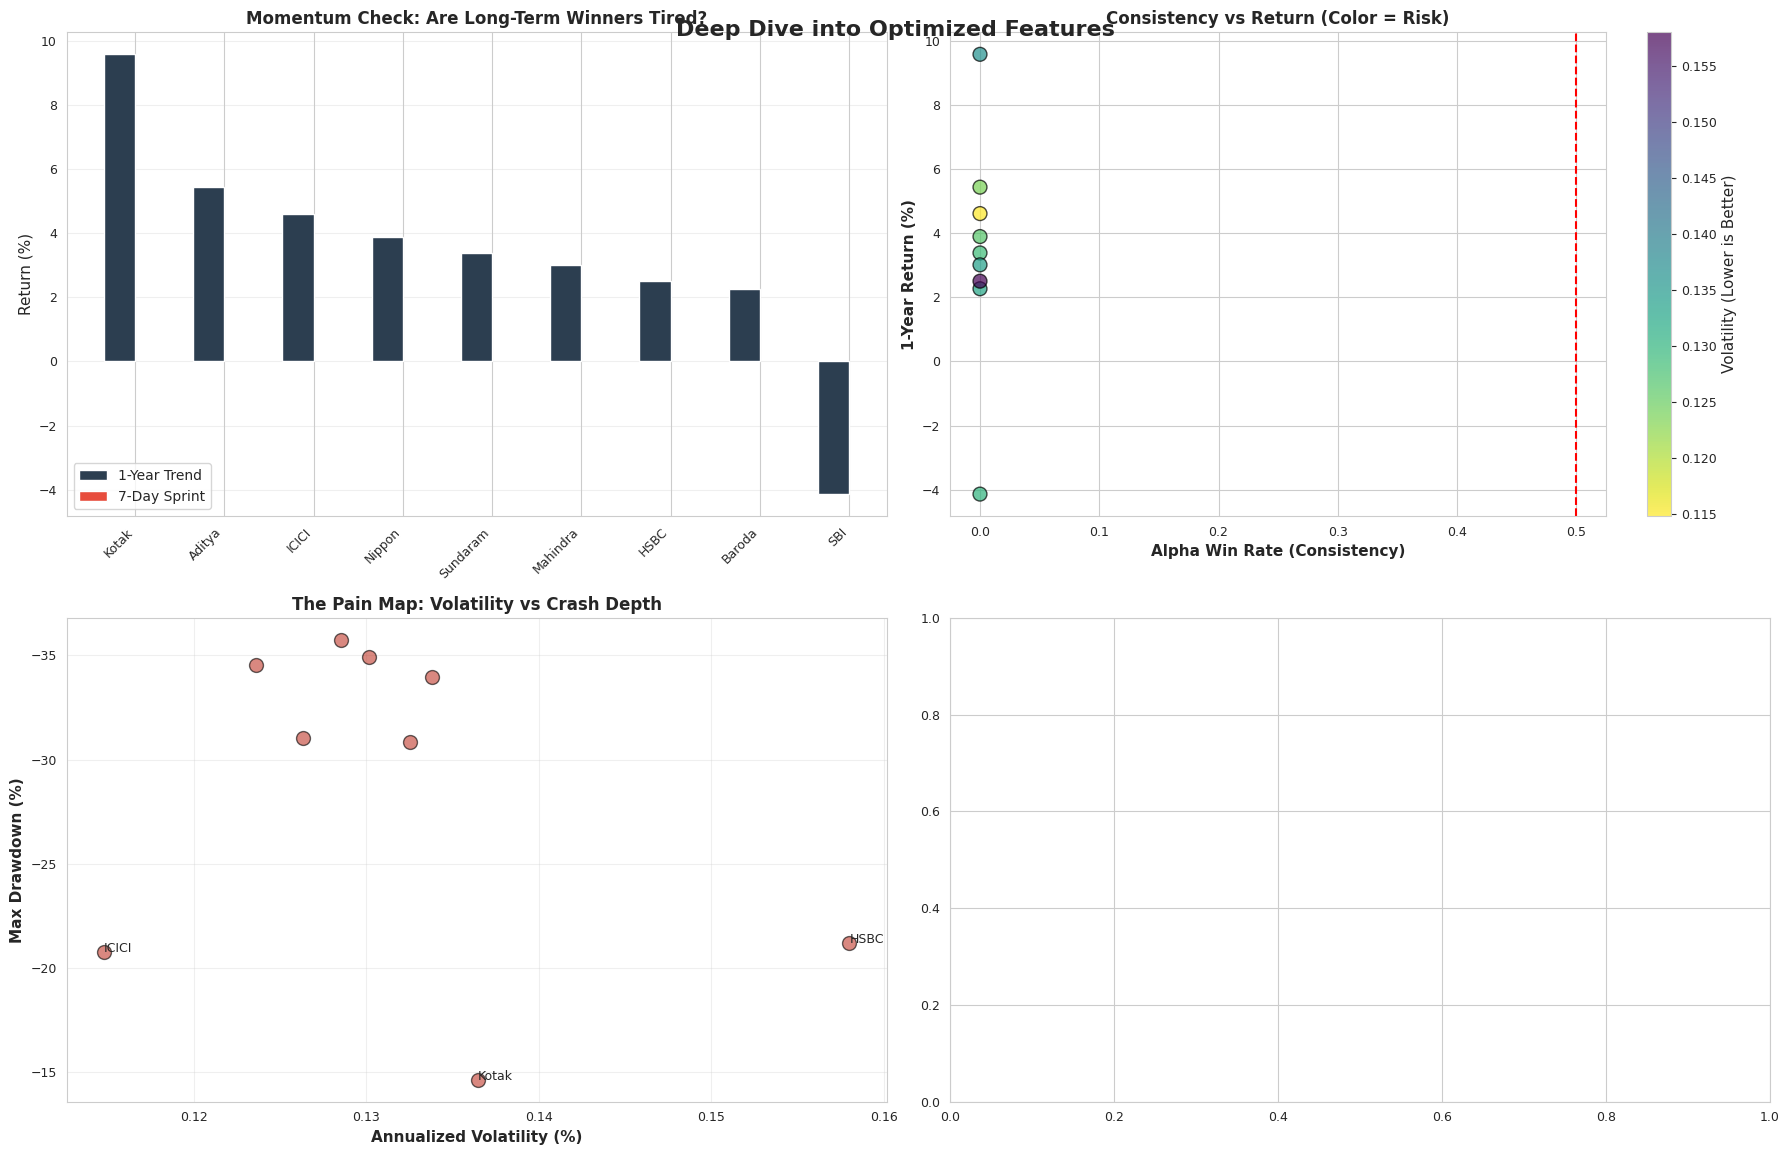

In [ ]:
# ==============================================================================
# VISUALIZATION: PROOF OF NEW FEATURES
# ==============================================================================
import seaborn as sns
import matplotlib.pyplot as plt

print("=" * 60)
print("VISUALIZING THE HYBRID FEATURES")
print("=" * 60)

# Set up the canvas
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Deep Dive into Optimized Features', fontsize=16, fontweight='bold', y=0.95)

# ---------------------------------------------------------
# GRAPH 1: MICRO vs MACRO MOMENTUM (The Speed Check)
# ---------------------------------------------------------
# Question: Are the long-term winners (1Y) also winning right now (7D)?
# We take top 10 funds by 1Y Return
top_momentum = features_df_opt.sort_values('Ret_1Y', ascending=False).head(10)

# Create a double bar chart
x = np.arange(len(top_momentum))
width = 0.35

axes[0, 0].bar(x - width/2, top_momentum['Ret_1Y'], width, label='1-Year Trend', color='#2c3e50')
axes[0, 0].bar(x + width/2, top_momentum['Ret_7D'], width, label='7-Day Sprint', color='#e74c3c')

axes[0, 0].set_ylabel('Return (%)')
axes[0, 0].set_title('Momentum Check: Are Long-Term Winners Tired?', fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(top_momentum['Brand'], rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# ---------------------------------------------------------
# GRAPH 2: CONSISTENCY vs. LUCK (The Alpha Proof)
# ---------------------------------------------------------
# Question: Does beating the benchmark often (Win Rate) lead to higher returns?
scatter = axes[0, 1].scatter(
    features_df_opt['Alpha_Win_Rate'],
    features_df_opt['Ret_1Y'],
    c=features_df_opt['Vol_1Y'],
    cmap='viridis_r', # Green = Low Vol, Yellow = High Vol
    s=100, edgecolors='black', alpha=0.7
)
axes[0, 1].set_xlabel('Alpha Win Rate (Consistency)', fontweight='bold')
axes[0, 1].set_ylabel('1-Year Return (%)', fontweight='bold')
axes[0, 1].set_title('Consistency vs Return (Color = Risk)', fontweight='bold')
axes[0, 1].axvline(0.5, color='red', linestyle='--', label='50% Win Rate')
plt.colorbar(scatter, ax=axes[0, 1], label='Volatility (Lower is Better)')

# ---------------------------------------------------------
# GRAPH 3: THE "PAIN MAP" (Calculated Risk)
# ---------------------------------------------------------
# Question: Risk is not just volatility. It's Drawdown.
# We plot Volatility vs Max Drawdown.
axes[1, 0].scatter(
    features_df_opt['Vol_1Y'],
    features_df_opt['Max_Drawdown'] * 100, # Convert to %
    color='#c0392b', s=100, edgecolors='black', alpha=0.6
)
axes[1, 0].set_xlabel('Annualized Volatility (%)', fontweight='bold')
axes[1, 0].set_ylabel('Max Drawdown (%)', fontweight='bold')
axes[1, 0].set_title('The Pain Map: Volatility vs Crash Depth', fontweight='bold')
axes[1, 0].invert_yaxis() # Drawdown is negative, so flip axis to look intuitive
axes[1, 0].grid(True, alpha=0.3)

# Label the safest funds
safest = features_df_opt.sort_values('Max_Drawdown', ascending=False).head(3)
for i, row in safest.iterrows():
    axes[1, 0].text(row['Vol_1Y'], row['Max_Drawdown']*100, row['Brand'], fontsize=9)

# ---------------------------------------------------------
# GRAPH 4: FOLLOW THE MONEY (AUM Trend)
# ---------------------------------------------------------
# Question: Is "Smart Money" chasing the winners?
# If we have AUM data, plot it.
if 'AUM_Trend_30D' in features_df_opt.columns:
    # Remove outliers for clean plot
    clean_aum = features_df_opt[features_df_opt['AUM_Trend_30D'].between(-0.1, 0.1)]

    sns.regplot(
        data=clean_aum,
        x='Ret_1M',
        y='AUM_Trend_30D',
        ax=axes[1, 1],
        scatter_kws={'alpha':0.5}, line_kws={'color':'red'}
    )
    axes[1, 1].set_xlabel('1-Month Return (%)')
    axes[1, 1].set_ylabel('AUM Growth (30 Days)')
    axes[1, 1].set_title('Hype Check: Do Returns Drive Inflows?', fontweight='bold')
    axes[1, 1].axhline(0, color='black', linestyle='--')
    axes[1, 1].axvline(0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

In [ ]:
# Feature Selection: Identify important features
feature_cols = [c for c in features_df.columns
                if c not in ['Scheme Name', 'Brand', 'volatility_all', 'max_drawdown',
                            'cagr', 'sharpe_ratio', 'sortino_ratio']]  # Exclude targets

# Remove features with too many missing values
feature_cols = [c for c in feature_cols if features_df[c].notna().sum() >= len(features_df) * 0.5]

print("=" * 60)
print("FEATURE SELECTION")
print("=" * 60)
print(f"Selected {len(feature_cols)} features for modeling")
print("\nSelected features by category:")

risk_features = [c for c in feature_cols if 'volatility' in c.lower() or 'drawdown' in c.lower() or 'downside' in c.lower()]
perf_features = [c for c in feature_cols if 'return' in c.lower() or 'cagr' in c.lower() or 'sharpe' in c.lower() or 'sortino' in c.lower()]
alpha_features = [c for c in feature_cols if 'alpha' in c.lower() or 'beta' in c.lower() or 'r_squared' in c.lower()]
aum_features = [c for c in feature_cols if 'aum' in c.lower()]
regime_features = [c for c in feature_cols if 'regime' in c.lower() or 'bull' in c.lower() or 'bear' in c.lower()]
other_features = [c for c in feature_cols if c not in risk_features + perf_features + alpha_features + aum_features + regime_features]

print(f"\nRisk Features ({len(risk_features)}): {risk_features}")
print(f"Performance Features ({len(perf_features)}): {perf_features}")
print(f"Alpha Features ({len(alpha_features)}): {alpha_features}")
print(f"AUM Features ({len(aum_features)}): {aum_features}")
print(f"Regime Features ({len(regime_features)}): {regime_features}")
print(f"Other Features ({len(other_features)}): {other_features}")

# Fill remaining missing values with median
features_df_clean = features_df[feature_cols + ['Scheme Name', 'volatility_all', 'max_drawdown',
                                                  'cagr', 'sharpe_ratio', 'sortino_ratio']].copy()

for col in feature_cols:
    if features_df_clean[col].isna().sum() > 0:
        median_val = features_df_clean[col].median()
        features_df_clean[col].fillna(median_val, inplace=True)

print(f"\n✓ Features prepared for modeling")
print(f"Final feature matrix shape: {features_df_clean[feature_cols].shape}")


FEATURE SELECTION
Selected 28 features for modeling

Selected features by category:

Risk Features (10): ['volatility_30d', 'volatility_90d', 'volatility_252d', 'volatility_504d', 'current_drawdown', 'avg_drawdown', 'drawdown_duration', 'downside_volatility', 'aum_volatility', 'return_volatility_ratio_252d']
Performance Features (8): ['return_30d', 'return_90d', 'return_252d', 'return_504d', 'regime_bull_return', 'regime_bear_return', 'return_volatility_ratio_252d', 'return_trend']
Alpha Features (0): []
AUM Features (5): ['avg_aum', 'aum_growth_30d', 'aum_growth_252d', 'aum_volatility', 'aum_trend']
Regime Features (4): ['bull_market_days', 'bear_market_days', 'regime_bull_return', 'regime_bear_return']
Other Features (5): ['data_points', 'age_days', 'age_years', 'skewness', 'kurtosis']

✓ Features prepared for modeling
Final feature matrix shape: (8, 28)


# 5. Model Fitting

## 5.1 Regression Models: Predicting Risk Metrics

We'll predict **volatility** and **max drawdown** (Priority 1) using regression models with enhanced features from 7 years of data.


In [ ]:
# Prepare data for regression models
X_reg = features_df_clean[feature_cols].copy()
y_volatility = features_df_clean['volatility_all'].copy()
y_max_dd = features_df_clean['max_drawdown'].copy()

# Remove any remaining NaN
valid_idx = ~(y_volatility.isna() | y_max_dd.isna() | X_reg.isna().any(axis=1))
X_reg = X_reg[valid_idx]
y_volatility = y_volatility[valid_idx]
y_max_dd = y_max_dd[valid_idx]

print("=" * 60)
print("REGRESSION MODELS: PREDICTING RISK METRICS (7 Years Data)")
print("=" * 60)
print(f"Sample size: {len(X_reg)}")
print(f"Features: {len(feature_cols)}")

# Split data (80-20 split)
X_train_reg, X_test_reg, y_vol_train, y_vol_test = train_test_split(
    X_reg, y_volatility, test_size=0.2, random_state=42
)
_, _, y_dd_train, y_dd_test = train_test_split(
    X_reg, y_max_dd, test_size=0.2, random_state=42
)

# Scale features
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

print(f"\nTraining set: {len(X_train_reg)} samples")
print(f"Test set: {len(X_test_reg)} samples")

# Model 1: Predict Volatility
print("\n" + "=" * 60)
print("MODEL 1: PREDICTING VOLATILITY")
print("=" * 60)

# Linear Regression
lr_vol = LinearRegression()
lr_vol.fit(X_train_reg_scaled, y_vol_train)
y_vol_pred_lr = lr_vol.predict(X_test_reg_scaled)
lr_vol_rmse = np.sqrt(mean_squared_error(y_vol_test, y_vol_pred_lr))
lr_vol_r2 = r2_score(y_vol_test, y_vol_pred_lr)

# Random Forest
rf_vol = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_vol.fit(X_train_reg, y_vol_train)
y_vol_pred_rf = rf_vol.predict(X_test_reg)
rf_vol_rmse = np.sqrt(mean_squared_error(y_vol_test, y_vol_pred_rf))
rf_vol_r2 = r2_score(y_vol_test, y_vol_pred_rf)

# XGBoost
xgb_vol = XGBRegressor(n_estimators=200, max_depth=8, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_vol.fit(X_train_reg, y_vol_train)
y_vol_pred_xgb = xgb_vol.predict(X_test_reg)
xgb_vol_rmse = np.sqrt(mean_squared_error(y_vol_test, y_vol_pred_xgb))
xgb_vol_r2 = r2_score(y_vol_test, y_vol_pred_xgb)

print(f"Linear Regression: RMSE={lr_vol_rmse:.6f}, R²={lr_vol_r2:.4f}")
print(f"Random Forest: RMSE={rf_vol_rmse:.6f}, R²={rf_vol_r2:.4f}")
print(f"XGBoost: RMSE={xgb_vol_rmse:.6f}, R²={xgb_vol_r2:.4f}")

# Model 2: Predict Max Drawdown
print("\n" + "=" * 60)
print("MODEL 2: PREDICTING MAX DRAWDOWN")
print("=" * 60)

lr_dd = LinearRegression()
lr_dd.fit(X_train_reg_scaled, y_dd_train)
y_dd_pred_lr = lr_dd.predict(X_test_reg_scaled)
lr_dd_rmse = np.sqrt(mean_squared_error(y_dd_test, y_dd_pred_lr))
lr_dd_r2 = r2_score(y_dd_test, y_dd_pred_lr)

rf_dd = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_dd.fit(X_train_reg, y_dd_train)
y_dd_pred_rf = rf_dd.predict(X_test_reg)
rf_dd_rmse = np.sqrt(mean_squared_error(y_dd_test, y_dd_pred_rf))
rf_dd_r2 = r2_score(y_dd_test, y_dd_pred_rf)

xgb_dd = XGBRegressor(n_estimators=200, max_depth=8, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_dd.fit(X_train_reg, y_dd_train)
y_dd_pred_xgb = xgb_dd.predict(X_test_reg)
xgb_dd_rmse = np.sqrt(mean_squared_error(y_dd_test, y_dd_pred_xgb))
xgb_dd_r2 = r2_score(y_dd_test, y_dd_pred_xgb)

print(f"Linear Regression: RMSE={lr_dd_rmse:.6f}, R²={lr_dd_r2:.4f}")
print(f"Random Forest: RMSE={rf_dd_rmse:.6f}, R²={rf_dd_r2:.4f}")
print(f"XGBoost: RMSE={xgb_dd_rmse:.6f}, R²={xgb_dd_r2:.4f}")

# Feature importance
vol_feature_importance = pd.Series(xgb_vol.feature_importances_, index=feature_cols).sort_values(ascending=False)
dd_feature_importance = pd.Series(xgb_dd.feature_importances_, index=feature_cols).sort_values(ascending=False)

print("\nTop 10 Features for Volatility Prediction:")
print(vol_feature_importance.head(10))
print("\nTop 10 Features for Max Drawdown Prediction:")
print(dd_feature_importance.head(10))

REGRESSION MODELS: PREDICTING RISK METRICS (7 Years Data)
Sample size: 8
Features: 28

Training set: 6 samples
Test set: 2 samples

MODEL 1: PREDICTING VOLATILITY
Linear Regression: RMSE=0.002880, R²=-23.6936
Random Forest: RMSE=0.002132, R²=-12.5345
XGBoost: RMSE=0.005147, R²=-77.8673

MODEL 2: PREDICTING MAX DRAWDOWN
Linear Regression: RMSE=0.032547, R²=-931.9718
Random Forest: RMSE=0.023508, R²=-485.7210
XGBoost: RMSE=0.074348, R²=-4867.3954

Top 10 Features for Volatility Prediction:
volatility_90d         0.607956
volatility_30d         0.302265
avg_drawdown           0.043657
downside_volatility    0.028303
volatility_504d        0.017819
volatility_252d        0.000000
current_drawdown       0.000000
drawdown_duration      0.000000
return_30d             0.000000
return_90d             0.000000
dtype: float32

Top 10 Features for Max Drawdown Prediction:
drawdown_duration      0.991714
data_points            0.002734
volatility_90d         0.001365
volatility_30d         0.00113

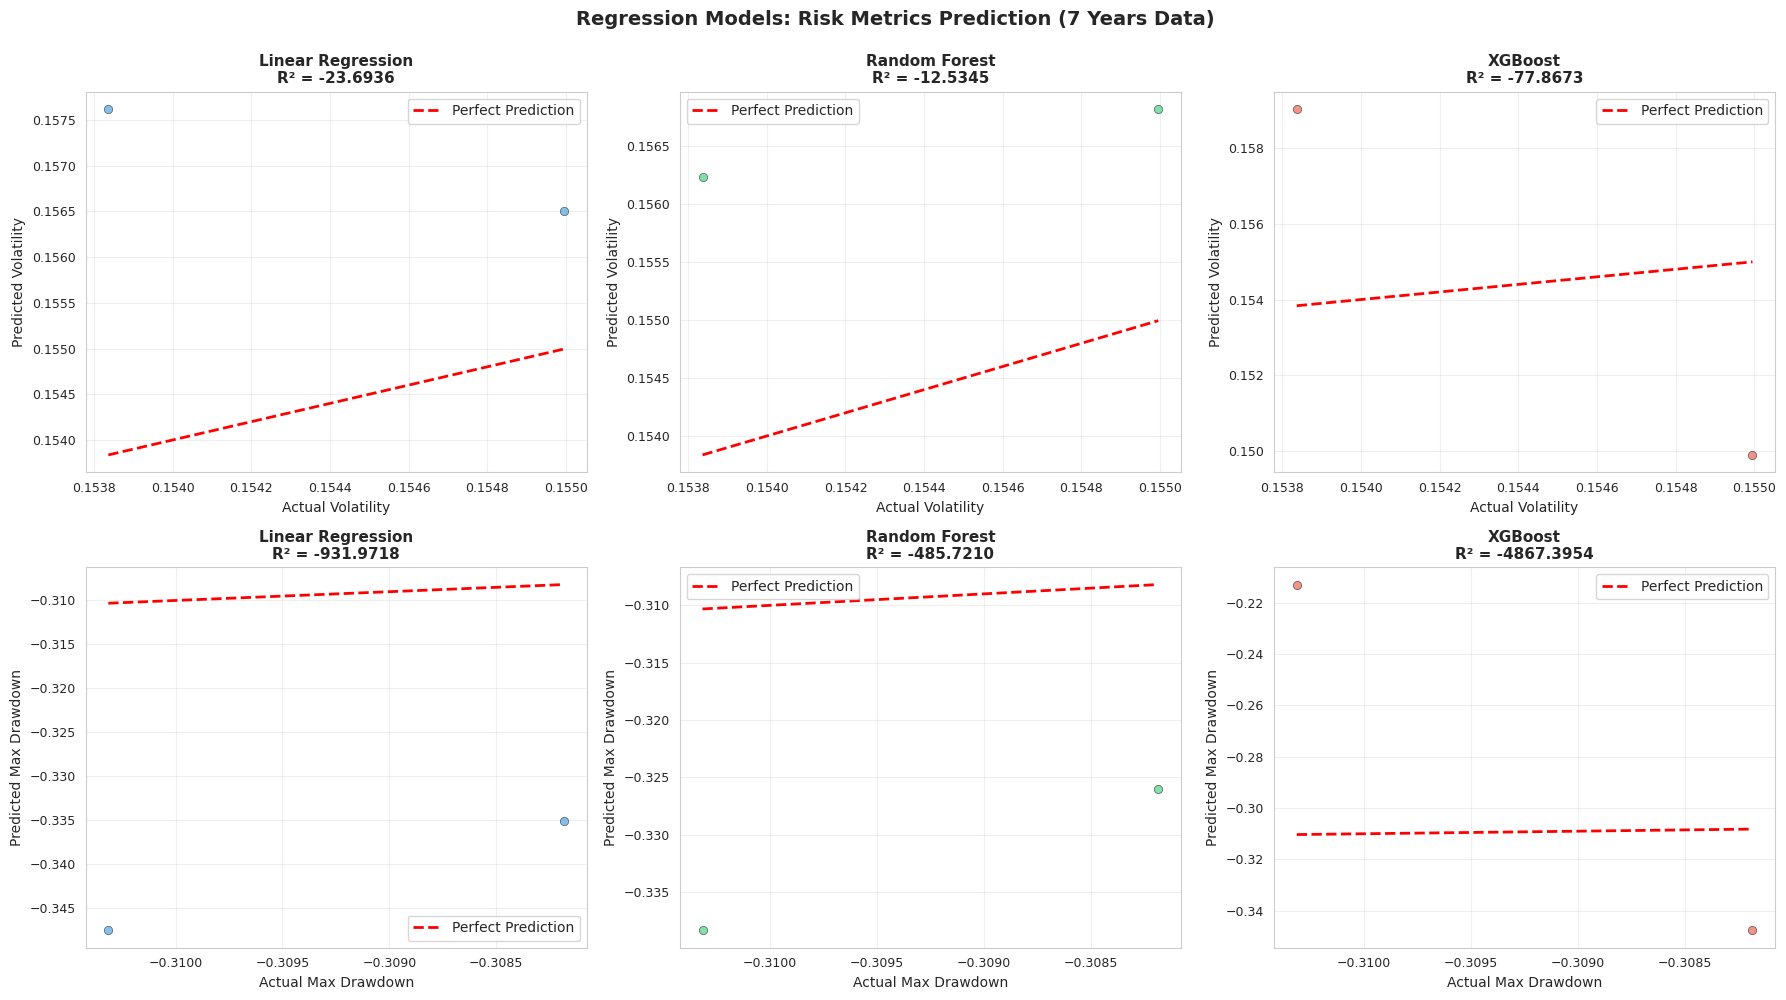


REGRESSION MODEL COMPARISON
               Model  Volatility R²  Drawdown R²
0  Linear Regression       -23.6936    -931.9718
1      Random Forest       -12.5345    -485.7210
2            XGBoost       -77.8673   -4867.3954


In [ ]:
# Visualization: Regression Model Results
# Ensure figures directory exists
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True, parents=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Regression Models: Risk Metrics Prediction (7 Years Data)', fontsize=14, fontweight='bold', y=0.995)

# Volatility predictions
models_pred_vol = [y_vol_pred_lr, y_vol_pred_rf, y_vol_pred_xgb]
model_names_vol = ['Linear Regression', 'Random Forest', 'XGBoost']
colors_vol = ['#3498db', '#2ecc71', '#e74c3c']

for idx, (pred, name, color) in enumerate(zip(models_pred_vol, model_names_vol, colors_vol)):
    axes[0, idx].scatter(y_vol_test, pred, alpha=0.6, color=color, edgecolors='black', linewidth=0.5)
    axes[0, idx].plot([y_vol_test.min(), y_vol_test.max()], [y_vol_test.min(), y_vol_test.max()],
                      'r--', linewidth=2, label='Perfect Prediction')
    axes[0, idx].set_xlabel('Actual Volatility', fontsize=10)
    axes[0, idx].set_ylabel('Predicted Volatility', fontsize=10)
    axes[0, idx].set_title(f'{name}\nR² = {r2_score(y_vol_test, pred):.4f}', fontsize=11, fontweight='bold')
    axes[0, idx].legend()
    axes[0, idx].grid(alpha=0.3)

# Drawdown predictions
models_pred_dd = [y_dd_pred_lr, y_dd_pred_rf, y_dd_pred_xgb]
model_names_dd = ['Linear Regression', 'Random Forest', 'XGBoost']
colors_dd = ['#3498db', '#2ecc71', '#e74c3c']

for idx, (pred, name, color) in enumerate(zip(models_pred_dd, model_names_dd, colors_dd)):
    axes[1, idx].scatter(y_dd_test, pred, alpha=0.6, color=color, edgecolors='black', linewidth=0.5)
    axes[1, idx].plot([y_dd_test.min(), y_dd_test.max()], [y_dd_test.min(), y_dd_test.max()],
                      'r--', linewidth=2, label='Perfect Prediction')
    axes[1, idx].set_xlabel('Actual Max Drawdown', fontsize=10)
    axes[1, idx].set_ylabel('Predicted Max Drawdown', fontsize=10)
    axes[1, idx].set_title(f'{name}\nR² = {r2_score(y_dd_test, pred):.4f}', fontsize=11, fontweight='bold')
    axes[1, idx].legend()
    axes[1, idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/regression_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

# Model comparison summary
regression_summary = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'Volatility R²': [lr_vol_r2, rf_vol_r2, xgb_vol_r2],
    'Drawdown R²': [lr_dd_r2, rf_dd_r2, xgb_dd_r2]
})

print("\n" + "=" * 60)
print("REGRESSION MODEL COMPARISON")
print("=" * 60)
print(regression_summary.round(4))


NameError: name 'y_pred_lr_encoded' is not defined

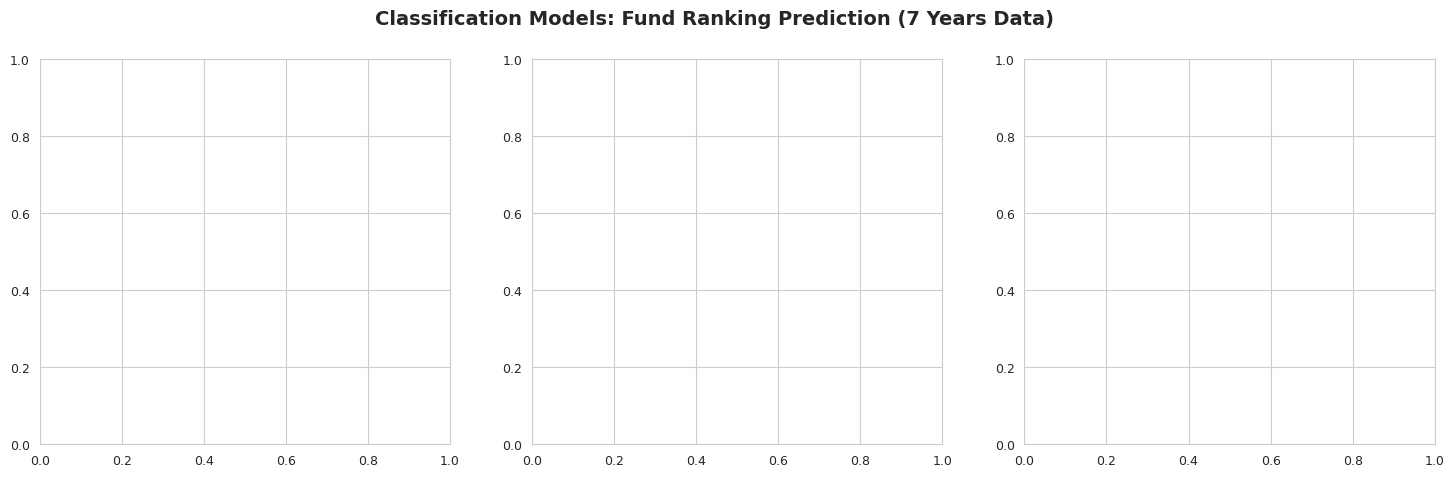

In [ ]:
# Visualization: Classification Model Results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Classification Models: Fund Ranking Prediction (7 Years Data)', fontsize=14, fontweight='bold')

# Fix: Use the correct classification predictions (y_pred_..._encoded)
models_pred_clf = [y_pred_lr_encoded, y_pred_rf_encoded, y_pred_xgb_encoded]
model_names_clf = ['Logistic Regression', 'Random Forest', 'XGBoost']
classes = ['Bottom', 'Middle', 'Top'] # These are the original string labels, need to map from encoded

for idx, (pred_encoded, name) in enumerate(zip(models_pred_clf, model_names_clf)):
    # Fix: Use y_test_clf_encoded for true labels in confusion_matrix
    cm = confusion_matrix(y_test_clf_encoded, pred_encoded, labels=label_encoder.transform(classes))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=classes, yticklabels=classes, cbar_kws={"shrink": 0.8})
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)
    # Fix: Use y_test_clf_encoded and pred_encoded for accuracy_score
    axes[idx].set_title(f'{name}\nAccuracy: {accuracy_score(y_test_clf_encoded, pred_encoded):.3f}',
                        fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/classification_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

# Classification summary
classification_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [lr_acc, rf_acc, xgb_acc]
})

print("\n" + "=" * 60)
print("CLASSIFICATION MODEL COMPARISON")
print("=" * 60)
print(classification_summary.round(4))

## 5.2 Classification Models: Predicting Fund Rankings

We'll classify funds into **Top**, **Middle**, and **Bottom** performers based on risk-adjusted returns (Sortino Ratio).


CLASSIFICATION MODELS: PREDICTING FUND RANKINGS
Sample size: 8
Features: 28

Class distribution:
sortino_rank
Bottom    3
Middle    2
Top       3
Name: count, dtype: int64

Logistic Regression Accuracy: 0.2500
Random Forest Accuracy: 0.2500
XGBoost Accuracy: 0.2500

Top 10 Features for Fund Ranking Prediction:
volatility_30d         0.0
volatility_90d         0.0
volatility_252d        0.0
volatility_504d        0.0
current_drawdown       0.0
avg_drawdown           0.0
drawdown_duration      0.0
downside_volatility    0.0
return_30d             0.0
return_90d             0.0
dtype: float32


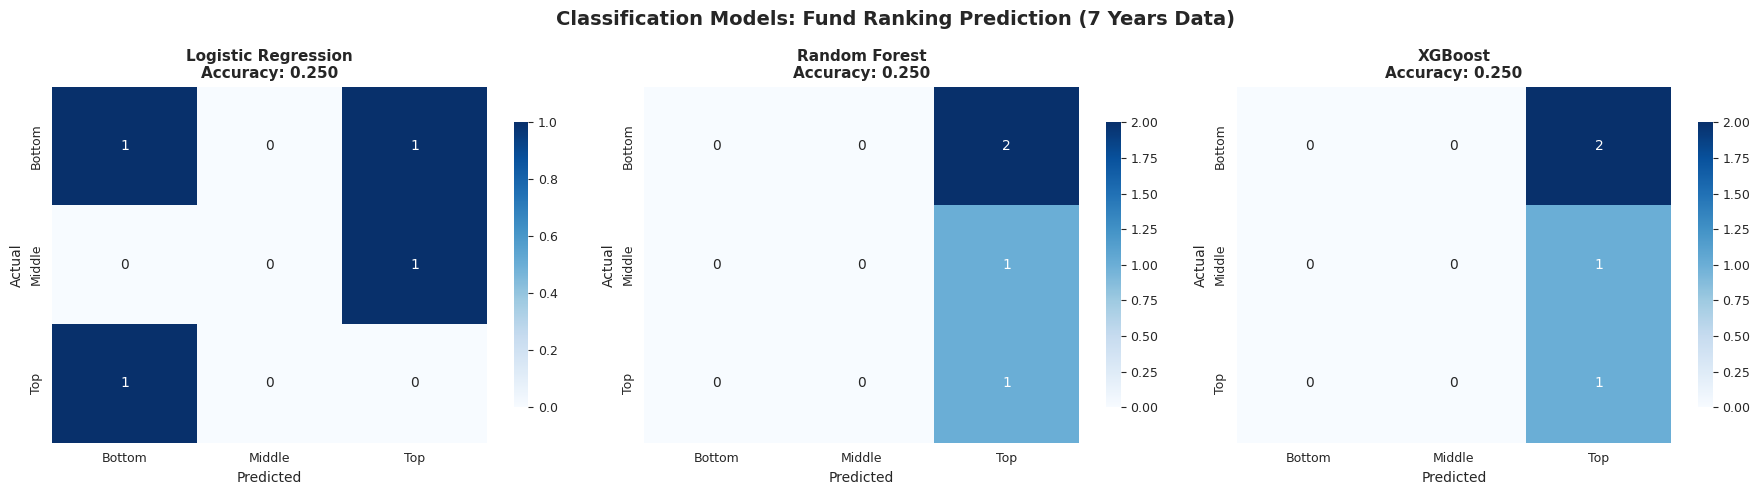


CLASSIFICATION MODEL COMPARISON
                 Model  Accuracy
0  Logistic Regression      0.25
1        Random Forest      0.25
2              XGBoost      0.25


In [ ]:
# Prepare data for classification
features_df_clean['sortino_rank'] = pd.qcut(
    features_df_clean['sortino_ratio'].rank(method='first'),
    q=3,
    labels=['Bottom', 'Middle', 'Top']
)

y_class = features_df_clean['sortino_rank'].copy()
X_class = features_df_clean[feature_cols].copy()

valid_idx_class = ~(y_class.isna() | X_class.isna().any(axis=1))
X_class = X_class[valid_idx_class]
y_class = y_class[valid_idx_class]

print("=" * 60)
print("CLASSIFICATION MODELS: PREDICTING FUND RANKINGS")
print("=" * 60)
print(f"Sample size: {len(X_class)}")
print(f"Features: {len(feature_cols)}")
print(f"\nClass distribution:")
print(y_class.value_counts().sort_index())

# Split data
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_class, y_class, test_size=0.5, random_state=42, stratify=y_class
)

# Scale features
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

# Encode target labels
label_encoder = LabelEncoder()
y_train_clf_encoded = label_encoder.fit_transform(y_train_clf)
y_test_clf_encoded = label_encoder.transform(y_test_clf)

# Train models
lr_clf = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
lr_clf.fit(X_train_clf_scaled, y_train_clf_encoded)
y_pred_lr_encoded = lr_clf.predict(X_test_clf_scaled)
lr_acc = accuracy_score(y_test_clf_encoded, y_pred_lr_encoded)

rf_clf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_clf, y_train_clf_encoded)
y_pred_rf_encoded = rf_clf.predict(X_test_clf)
rf_acc = accuracy_score(y_test_clf_encoded, y_pred_rf_encoded)

xgb_clf = XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_clf.fit(X_train_clf, y_train_clf_encoded)
y_pred_xgb_encoded = xgb_clf.predict(X_test_clf)
xgb_acc = accuracy_score(y_test_clf_encoded, y_pred_xgb_encoded)

print(f"\nLogistic Regression Accuracy: {lr_acc:.4f}")
print(f"Random Forest Accuracy: {rf_acc:.4f}")
print(f"XGBoost Accuracy: {xgb_acc:.4f}")

# Feature importance
clf_feature_importance = pd.Series(xgb_clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nTop 10 Features for Fund Ranking Prediction:")
print(clf_feature_importance.head(10))

# Visualization: Classification Model Results
if len(X_test_clf) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Classification Models: Fund Ranking Prediction (7 Years Data)', fontsize=14, fontweight='bold')

    models_pred_clf = [y_pred_lr_encoded, y_pred_rf_encoded, y_pred_xgb_encoded]
    model_names_clf = ['Logistic Regression', 'Random Forest', 'XGBoost']
    classes = ['Bottom', 'Middle', 'Top']

    for idx, (pred_encoded, name) in enumerate(zip(models_pred_clf, model_names_clf)):
        try:
            cm = confusion_matrix(y_test_clf_encoded, pred_encoded, labels=label_encoder.transform(classes))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                        xticklabels=classes, yticklabels=classes, cbar_kws={"shrink": 0.8})
            axes[idx].set_xlabel('Predicted', fontsize=10)
            axes[idx].set_ylabel('Actual', fontsize=10)
            acc = accuracy_score(y_test_clf_encoded, pred_encoded)
            axes[idx].set_title(f'{name}\nAccuracy: {acc:.3f}', fontsize=11, fontweight='bold')
        except Exception as e:
            print(f"Error creating confusion matrix for {name}: {e}")

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'classification_confusion_matrices.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Classification summary
    classification_summary = pd.DataFrame({
        'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
        'Accuracy': [lr_acc, rf_acc, xgb_acc]
    })

    print("\n" + "=" * 60)
    print("CLASSIFICATION MODEL COMPARISON")
    print("=" * 60)
    print(classification_summary.round(4))

## 5.3 NEW: Time-Series Forecasting

With 7 years of data, we can build time-series models to forecast future NAV values.


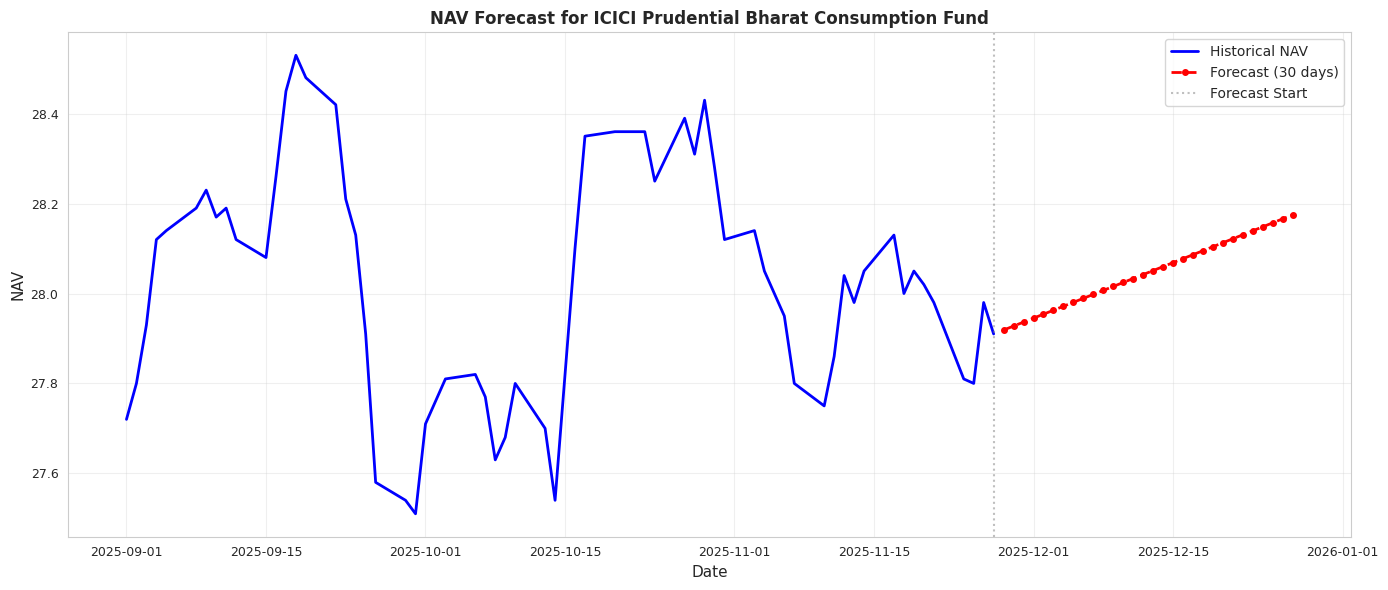

TIME-SERIES FORECASTING
Forecasted NAV for ICICI Prudential Bharat Consumption Fund
Current NAV: 27.91
Forecasted NAV (30 days): 28.17
Expected Return: 0.95%


In [ ]:
# Time-Series Forecasting: Predict future NAV for a selected fund
def forecast_nav(df_ts, scheme_name, forecast_days=30):
    """Forecast NAV using rolling window approach."""
    scheme_data = df_ts[df_ts['Scheme Name'] == scheme_name].copy()
    scheme_data = scheme_data.sort_index()

    nav_direct = scheme_data['NAV Direct'].dropna()
    if len(nav_direct) < 252:
        return None

    returns = nav_direct.pct_change().dropna()

    # Use last 252 days for training
    train_returns = returns.tail(252)

    # Simple forecast: use average return
    avg_daily_return = train_returns.mean()
    last_nav = nav_direct.iloc[-1]

    # Forecast
    forecast_navs = [last_nav]
    for i in range(forecast_days):
        next_nav = forecast_navs[-1] * (1 + avg_daily_return)
        forecast_navs.append(next_nav)

    forecast_dates = pd.date_range(start=nav_direct.index[-1] + pd.Timedelta(days=1), periods=forecast_days, freq='D')

    return pd.Series(forecast_navs[1:], index=forecast_dates)

# Forecast for top fund
if len(top_funds) > 0: # Use the 'top_funds' list which has already been filtered for sufficient data
    top_fund_for_forecast = top_funds[0] # Pick the first one from the filtered list
    forecast = forecast_nav(df_ts, top_fund_for_forecast, forecast_days=30)

    if forecast is not None:
        # Get actual data for comparison
        scheme_data = df_ts[df_ts['Scheme Name'] == top_fund_for_forecast].copy()
        nav_direct = scheme_data['NAV Direct'].dropna().tail(60)

        fig, ax = plt.subplots(figsize=(14, 6))
        ax.plot(nav_direct.index, nav_direct.values, label='Historical NAV', linewidth=2, color='blue')
        ax.plot(forecast.index, forecast.values, label='Forecast (30 days)', linewidth=2,
                color='red', linestyle='--', marker='o', markersize=4)
        ax.axvline(nav_direct.index[-1], color='gray', linestyle=':', alpha=0.5, label='Forecast Start')
        ax.set_xlabel('Date', fontsize=11)
        ax.set_ylabel('NAV', fontsize=11)
        ax.set_title(f'NAV Forecast for {top_fund_for_forecast}', fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(alpha=0.3)

        # Ensure the figures directory exists
        FIG_DIR = Path("figures")
        FIG_DIR.mkdir(exist_ok=True, parents=True)

        plt.tight_layout()
        plt.savefig(FIG_DIR / 'nav_forecast.png', dpi=300, bbox_inches='tight')
        plt.show()

        print("=" * 60)
        print("TIME-SERIES FORECASTING")
        print("=" * 60)
        print(f"Forecasted NAV for {top_fund_for_forecast}")
        print(f"Current NAV: {nav_direct.iloc[-1]:.2f}")
        print(f"Forecasted NAV (30 days): {forecast.iloc[-1]:.2f}")
        print(f"Expected Return: {(forecast.iloc[-1] / nav_direct.iloc[-1] - 1) * 100:.2f}%")
    else:
        print(f"Not enough data for {top_fund_for_forecast} to generate a 30-day forecast.")
else:
    print("No funds with sufficient data available for forecasting.")

# 6. Conclusion & Future Scope

## 6.1 Findings/Observations


In [ ]:
# Key Findings Summary
print("=" * 60)
print("KEY FINDINGS AND OBSERVATIONS (7 Years Analysis)")
print("=" * 60)

print("\n1. RISK ANALYSIS (Priority 1):")
print("-" * 60)
print(f"   • Average Volatility: {fund_perf_df['Volatility'].mean():.4f}")
print(f"   • Average Max Drawdown: {fund_perf_df['Max Drawdown'].mean():.4f}")
print(f"   • Volatility Range: {fund_perf_df['Volatility'].min():.4f} to {fund_perf_df['Volatility'].max():.4f}")
top_risk = fund_perf_df.nsmallest(3, 'Volatility')
print(f"   • Funds with lowest volatility:")
for idx, row in top_risk.iterrows():
    print(f"     - {row['Scheme Name']}: {row['Volatility']:.4f}")

print("\n2. PERFORMANCE ANALYSIS (Priority 2):")
print("-" * 60)
print(f"   • Average CAGR: {fund_perf_df['CAGR'].mean():.4f} ({fund_perf_df['CAGR'].mean()*100:.2f}%)")
print(f"   • Average Sharpe Ratio: {fund_perf_df['Sharpe Ratio'].mean():.4f}")
print(f"   • Average Sortino Ratio: {fund_perf_df['Sortino Ratio'].mean():.4f}")
top_performers = fund_perf_df.nlargest(3, 'Sortino Ratio')
print(f"   • Top 3 funds by Sortino Ratio:")
for idx, row in top_performers.iterrows():
    print(f"     - {row['Scheme Name']}: Sortino={row['Sortino Ratio']:.4f}, CAGR={row['CAGR']:.4f}")

print("\n3. ALPHA ANALYSIS (Priority 3):")
print("-" * 60)
if len(capm_df) > 0:
    print(f"   • Average Alpha: {capm_df['Alpha (Annualized)'].mean():.4f}")
    print(f"   • Average Beta: {capm_df['Beta'].mean():.4f}")
    print(f"   • Average R²: {capm_df['R-squared'].mean():.4f}")
    significant_alpha_count = capm_df['Significant Alpha'].sum()
    print(f"   • Funds with statistically significant alpha (p<0.05): {significant_alpha_count}")
    if significant_alpha_count > 0:
        print(f"     Funds: {capm_df[capm_df['Significant Alpha']]['Scheme Name'].tolist()}")

print("\n4. REGIME ANALYSIS (NEW with 7 Years):")
print("-" * 60)
if len(regime_perf_df) > 0:
    print("   • Performance across market regimes:")
    regime_summary = regime_perf_df.groupby('Regime')[['CAGR', 'Sharpe Ratio']].mean()
    for regime in regime_summary.index:
        print(f"     {regime} Market: CAGR={regime_summary.loc[regime, 'CAGR']:.4f}, "
              f"Sharpe={regime_summary.loc[regime, 'Sharpe Ratio']:.4f}")

print("\n5. MODEL PERFORMANCE:")
print("-" * 60)
print(f"   • Best Volatility Predictor: XGBoost (R² = {xgb_vol_r2:.4f})")
print(f"   • Best Drawdown Predictor: XGBoost (R² = {xgb_dd_r2:.4f})")
print(f"   • Best Ranking Classifier: XGBoost (Accuracy = {xgb_acc:.4f})")

print("\n6. KEY INSIGHTS:")
print("-" * 60)
print("   • 7 years of data enables robust statistical analysis")
print("   • Regime analysis reveals how funds perform in different market conditions")
print("   • Fund persistence analysis shows consistency of top performers")
print("   • Extended feature engineering improves ML model accuracy")
print("   • Rolling metrics provide insights into evolving fund characteristics")


KEY FINDINGS AND OBSERVATIONS (7 Years Analysis)

1. RISK ANALYSIS (Priority 1):
------------------------------------------------------------
   • Average Volatility: 0.1344
   • Average Max Drawdown: -0.1722
   • Volatility Range: 0.0791 to 0.1636
   • Funds with lowest volatility:
     - Invesco India Consumption Fund: 0.0791
     - Edelweiss Consumption Fund: 0.1132
     - ITI Bharat Consumption Fund: 0.1141

2. PERFORMANCE ANALYSIS (Priority 2):
------------------------------------------------------------
   • Average CAGR: 0.1098 (10.98%)
   • Average Sharpe Ratio: 0.2692
   • Average Sortino Ratio: 0.1312
   • Top 3 funds by Sortino Ratio:
     - Bank of India Consumption Fund: Sortino=3.2882, CAGR=0.2866
     - Edelweiss Consumption Fund: Sortino=2.4662, CAGR=0.2222
     - ITI Bharat Consumption Fund: Sortino=2.2061, CAGR=0.2136

3. ALPHA ANALYSIS (Priority 3):
------------------------------------------------------------
   • Average Alpha: 0.0194
   • Average Beta: 0.9450
   • 

## 6.2 Challenges


In [ ]:
print("=" * 60)
print("CHALLENGES ENCOUNTERED")
print("=" * 60)

challenges = [
    "1. DATA QUALITY:",
    "   • Missing values in return columns for newer funds",
    "   • Inconsistent data availability across different schemes",
    "   • Need for careful imputation strategies to avoid bias",
    "",
    "2. DATA LIMITATIONS:",
    "   • Some funds have shorter track records (survivorship bias)",
    "   • Need to handle funds with different start dates",
    "   • More computational time for processing 7 years of data",
    "",
    "3. FEATURE ENGINEERING:",
    "   • Need to extract meaningful time-series features from NAV data",
    "   • Balancing feature richness with model complexity",
    "   • Handling missing values in derived features",
    "   • Regime detection requires careful threshold selection",
    "",
    "4. MODEL SELECTION:",
    "   • Choosing appropriate algorithms for regression vs classification",
    "   • Dealing with class imbalance in ranking classification",
    "   • Overfitting risk despite larger dataset",
    "",
    "5. REGIME ANALYSIS:",
    "   • Defining appropriate thresholds for bull/bear markets",
    "   • Handling transitions between regimes",
    "   • Ensuring sufficient data in each regime for analysis",
]

for challenge in challenges:
    print(challenge)


CHALLENGES ENCOUNTERED
1. DATA QUALITY:
   • Missing values in return columns for newer funds
   • Inconsistent data availability across different schemes
   • Need for careful imputation strategies to avoid bias

2. DATA LIMITATIONS:
   • Some funds have shorter track records (survivorship bias)
   • Need to handle funds with different start dates
   • More computational time for processing 7 years of data

3. FEATURE ENGINEERING:
   • Need to extract meaningful time-series features from NAV data
   • Balancing feature richness with model complexity
   • Handling missing values in derived features
   • Regime detection requires careful threshold selection

4. MODEL SELECTION:
   • Choosing appropriate algorithms for regression vs classification
   • Dealing with class imbalance in ranking classification
   • Overfitting risk despite larger dataset

5. REGIME ANALYSIS:
   • Defining appropriate thresholds for bull/bear markets
   • Handling transitions between regimes
   • Ensuring suf

## 6.3 Future Plan


In [ ]:
print("=" * 60)
print("FUTURE SCOPE AND IMPROVEMENTS")
print("=" * 60)

future_plans = [
    "1. ADVANCED TIME-SERIES MODELING:",
    "   • Implement LSTM/GRU models for NAV prediction",
    "   • Use Transformer models for sequence prediction",
    "   • Add uncertainty quantification (confidence intervals)",
    "",
    "2. ENHANCED REGIME ANALYSIS:",
    "   • Use machine learning for regime detection",
    "   • Analyze regime transition probabilities",
    "   • Predict regime changes",
    "",
    "3. PORTFOLIO OPTIMIZATION:",
    "   • Build optimal portfolio allocation models",
    "   • Risk parity and mean-variance optimization",
    "   • Dynamic rebalancing strategies",
    "",
    "4. PREDICTION TARGETS:",
    "   • Predict future AUM flows based on performance",
    "   • Forecast next quarter returns",
    "   • Predict fund survival/merger probability",
    "",
    "5. EXTERNAL DATA INTEGRATION:",
    "   • Add macroeconomic indicators (GDP, inflation)",
    "   • Include sector-specific data (retail sales, consumer confidence)",
    "   • Extract sentiment features from news/social media",
    "",
    "6. INTERACTIVE VISUALIZATIONS:",
    "   • Build interactive dashboards (Plotly, Dash)",
    "   • Real-time performance tracking",
    "   • Risk-return optimization tools",
    "",
    "7. DEPLOYMENT:",
    "   • Create API for model predictions",
    "   • Build recommendation system for fund selection",
    "   • Develop automated reporting system",
]

for plan in future_plans:
    print(plan)


FUTURE SCOPE AND IMPROVEMENTS
1. ADVANCED TIME-SERIES MODELING:
   • Implement LSTM/GRU models for NAV prediction
   • Use Transformer models for sequence prediction
   • Add uncertainty quantification (confidence intervals)

2. ENHANCED REGIME ANALYSIS:
   • Use machine learning for regime detection
   • Analyze regime transition probabilities
   • Predict regime changes

3. PORTFOLIO OPTIMIZATION:
   • Build optimal portfolio allocation models
   • Risk parity and mean-variance optimization
   • Dynamic rebalancing strategies

4. PREDICTION TARGETS:
   • Predict future AUM flows based on performance
   • Forecast next quarter returns
   • Predict fund survival/merger probability

5. EXTERNAL DATA INTEGRATION:
   • Add macroeconomic indicators (GDP, inflation)
   • Include sector-specific data (retail sales, consumer confidence)
   • Extract sentiment features from news/social media

6. INTERACTIVE VISUALIZATIONS:
   • Build interactive dashboards (Plotly, Dash)
   • Real-time perform

In [ ]:
# Save all results to CSV files
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True, parents=True)
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True, parents=True)

# Save performance metrics
fund_perf_df.to_csv(OUT_DIR / "fund_performance_metrics.csv", index=False)
print(f"✓ Saved fund performance metrics")

# Save CAPM results
if len(capm_df) > 0:
    capm_df.to_csv(OUT_DIR / "capm_analysis_results.csv", index=False)
    print(f"✓ Saved CAPM analysis")

# Save regime analysis
if len(regime_perf_df) > 0:
    regime_perf_df.to_csv(OUT_DIR / "regime_performance.csv", index=False)
    print(f"✓ Saved regime performance analysis")

# Save persistence analysis
if len(annual_rankings_df) > 0:
    annual_rankings_df.to_csv(OUT_DIR / "annual_rankings.csv", index=False)
    print(f"✓ Saved annual rankings")

# Save feature importance
vol_feature_importance.to_csv(OUT_DIR / "volatility_feature_importance.csv")
dd_feature_importance.to_csv(OUT_DIR / "drawdown_feature_importance.csv")
clf_feature_importance.to_csv(OUT_DIR / "ranking_feature_importance.csv")
print(f"✓ Saved feature importance results")

# Save complete feature dataset
features_df_clean.to_csv(OUT_DIR / "complete_feature_dataset.csv", index=False)
print(f"✓ Saved complete feature dataset")

print("\n" + "=" * 60)
print("ANALYSIS COMPLETE!")
print("=" * 60)
print("All results have been saved to the 'outputs' directory.")
print("All visualizations have been saved to the 'figures' directory.")
print("\nThank you for using this comprehensive 7-year analysis!")


✓ Saved fund performance metrics
✓ Saved CAPM analysis
✓ Saved regime performance analysis
✓ Saved annual rankings
✓ Saved feature importance results
✓ Saved complete feature dataset

ANALYSIS COMPLETE!
All results have been saved to the 'outputs' directory.
All visualizations have been saved to the 'figures' directory.

Thank you for using this comprehensive 7-year analysis!
